# Explainable Short-Horizon Prediction of Pedestrian Crossing-Corridor Entry Using Trajectory and Interaction Features

## Purpose and Scope

This Appendix documents the empirical workflow for a thesis study of **short-horizon pedestrian crossing-corridor entry prediction** using naturalistic multi-actor trajectory data from the Slottskogsgatan roundabout-crossing site. It is written to serve directly as the empirical backbone of the thesis **Method**, **Implementation**, and **Results** chapters.

The central task is a short-horizon binary prediction problem:

- **Target:** `cross_soon`
- **Interpretation:** whether a pedestrian observation belongs to a state from which the pedestrian will enter the operational **crossing corridor** within a short future horizon
- **Main modelling focus:** how prediction changes across **pedestrian-only** and **interaction-aware** representations

The implementation compares three model families for complementary reasons:

1. **logistic regression** as the interpretable baseline and feature-analysis backbone;
2. **MLP** as the non-linear tabular comparison on the same locked feature tables;
3. **GRU** as a compact sequence-model comparison that tests whether direct temporal modelling adds value.

This framing is consistent with broader work that distinguishes latent intention from observable short-horizon behaviour and that motivates both interpretable baselines and more flexible temporal models (Vellenga et al., 2022; Delgado, 2025; Govindhan, 2025; Mirkovic, 2025).

## Roadmap

- **Phase 1** transforms raw trajectories into a defensible supervised learning table
- **Phase 2** evaluates the main **3-second** modelling pipeline and the later model-family comparisons
- a compact **horizon-sensitivity** section then compares the task across **2 s**, **3 s**, and **5 s** to show how horizon choice changes the results

### The implemented pipeline therefore follows the full scientific chain:

**raw trajectories → operational crossing label → interpretable feature engineering → leakage-safe modelling → model-family comparison → explainability → uncertainty checks → horizon sensitivity**


In [1]:
# imports
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

import copy
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance

from scipy.stats import binomtest
from itertools import combinations
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests


In [2]:
# reproducibility / shared configuration
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

type_labels = {
    0: "Pedestrian",
    1: "Bicycle",
    2: "Light Vehicle",
    3: "Heavy Vehicle",
}

colors = {
    0: "red",
    1: "green",
    2: "blue",
    3: "orange",
}

actor_legend_handles = [
    Line2D([0], [0], color=colors[k], lw=2, label=type_labels[k])
    for k in sorted(type_labels)
]


## Data source and provenance

The dataset used in this implementation was provided by **Viscando** under a **non-disclosure agreement (NDA)**. The analysis is therefore documented transparently, while unnecessary confidential details about the source material are omitted.

The main executed thesis pipeline starts from **one canonical merged raw trajectory file**. This is deliberate: the pedestrian crossing-related analysis is derived from a single primary raw source rather than from prefiltered intermediate artefacts.

Additional files were received as part of the broader data delivery, but they are **not used in the main thesis pipeline** presented here.

In [3]:
# Load raw file
DATA_PATH = Path("Slottskogsgatan_tracks_extramerged 3.csv")
if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH, sep=";")
else:
    candidates = sorted(Path(".").glob("Slottskogsgatan_tracks_extramerged*.csv"))
    if not candidates:
        raise FileNotFoundError(
            f"Could not find '{DATA_PATH}'. "
            f"CSV files in current folder: {[p.name for p in Path('.').glob('*.csv')]}"
        )
    DATA_PATH = candidates[0]
    print(f"Using found file instead: {DATA_PATH}")
    df = pd.read_csv(DATA_PATH, sep=";")
df["Time"] = pd.to_datetime(df["Time"], format="mixed")
df.head()

Using found file instead: Slottskogsgatan_tracks_extramerged.csv


,ID,Time,X,Y,Speed,Type,Estimated
0,290,2018-05-22 16:31:00.210000+02:00,20.921695,-13.883904,3.582600,0,1
1,290,2018-05-22 16:31:00.463000+02:00,20.803420,-13.833362,2.989288,0,0
2,290,2018-05-22 16:31:00.716000+02:00,20.478601,-13.849433,3.402922,0,0
3,290,2018-05-22 16:31:00.968000+02:00,20.125726,-13.376281,4.452878,0,0
4,290,2018-05-22 16:31:01.225000+02:00,20.031157,-13.032073,4.344997,0,0


In [4]:
# Shape and columns
print("Shape:", df.shape)
print("\nColumns:")
for col in df.columns:
    print("-", col)

# Missingness and duplicates
print(df.isna().sum())
print("\nExact duplicate rows:", df.duplicated().sum())
print("Duplicate (ID, Time) rows:", df.duplicated(subset=["ID", "Time"]).sum())

# Basic time range
print("Time range:")
print(df["Time"].min(), "to", df["Time"].max())

# Row counts and track counts by type
print("Row counts by Type:")
print(df["Type"].value_counts().sort_index())

print("\nUnique tracks by Type:")
print(df.groupby("Type")["ID"].nunique().sort_index())


Shape: (1978476, 7)

Columns:
- ID
- Time
- X
- Y
- Speed
- Type
- Estimated
ID           0
Time         0
X            0
Y            0
Speed        0
Type         0
Estimated    0
dtype: int64

Exact duplicate rows: 0
Duplicate (ID, Time) rows: 0
Time range:
2018-05-22 16:31:00.210000+02:00 to 2018-05-25 09:14:47.654000+02:00
Row counts by Type:
Type
0     113401
1     427979
2    1365905
3      71191
Name: count, dtype: int64

Unique tracks by Type:
Type
0     2097
1    12883
2    52791
3     3342
Name: ID, dtype: int64


In [5]:
# first track-level summary
track_df = df.groupby("ID").agg(
    Type=("Type", "first"),
    n_points=("ID", "size"),
    start=("Time", "min"),
    end=("Time", "max"),
    mean_speed=("Speed", "mean"),
    estimated_frac=("Estimated", "mean")
)

track_df["duration_sec"] = (track_df["end"] - track_df["start"]).dt.total_seconds()

track_df.groupby("Type")[["n_points", "duration_sec", "mean_speed", "estimated_frac"]].median()

,n_points,duration_sec,mean_speed,estimated_frac
Type,,,,
0,39.0,16.1650,5.616749,0.147368
1,29.0,12.7680,18.793804,0.166667
2,23.0,7.8340,26.632795,0.102564
3,15.0,4.5485,23.423136,0.111111


In [6]:
# Sampling interval audit
df_sorted = df.sort_values(["ID", "Time"]).copy()
df_sorted["dt_sec"] = df_sorted.groupby("ID")["Time"].diff().dt.total_seconds()

df_sorted["dt_sec"].dropna().describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    1.907363e+06
mean     3.952768e-01
std      1.094576e+00
min      1.000000e-03
1%       1.520000e-01
5%       2.500000e-01
25%      2.520000e-01
50%      2.530000e-01
75%      2.530000e-01
95%      3.520000e-01
99%      5.515690e+00
max      2.141770e+02
Name: dt_sec, dtype: float64

### Interpretation of the initial data audit and the `Estimated` flag

The raw trajectory file is structurally clean, with no missing values, no exact duplicate rows, and no duplicate `(ID, Time)` pairs. It contains nearly two million observations and more than seventy thousand unique tracked actors, making it a large-scale naturalistic traffic dataset.

The distribution of object types and their median speeds strongly suggests that the four `Type` categories correspond to pedestrians, bicycles, light vehicles, and heavy vehicles. This is consistent with the intended use of the data for multi-road-user interaction analysis. Pedestrian trajectories are present in sufficient quantity and with relatively long durations, which supports short-horizon pedestrian prediction.

The temporal audit shows that most within-track time gaps are close to **0.25 seconds** (about **4 Hz**). This provides enough temporal resolution for short-window motion features and short future horizons. At the same time, the long right tail in the gap distribution shows that sampling is not perfectly regular, so later time-based feature construction should not assume uniform spacing.

The dataset also contains an `Estimated` column (`0` or `1`), indicating whether a trajectory point was imputed by the upstream tracking pipeline rather than directly measured. This can happen, for example, during brief occlusions or missed detections. In this implentation, the flag is retained because it may contain predictive signal and because it provides a simple way to reflect local data quality through features such as `estimated_frac_past_2s`.

A practical limitation is that this flag reflects the internal state of the upstream tracker and may not be available in every deployment setting. This is therefore treated as a useful feature in the present dataset, but also as a validity consideration.

Overall, the audit supports the feasibility of an explainable pedestrian–vehicle interaction modelling project based on trajectory data. The next step is a spatial audit to identify the crossing region, visualize actor movement by type, and determine which pedestrian trajectories are relevant for crossing-related prediction.

## Phase 1B: Spatial audit of trajectories and candidate interaction geometry

This section visualises the trajectories by actor type in order to identify the main traffic flows and locate the spatial region in which pedestrians, cyclists, and vehicles interact. The purpose is not yet to define the final prediction dataset, but to identify a broad candidate interaction area for later extraction of crossing episodes.

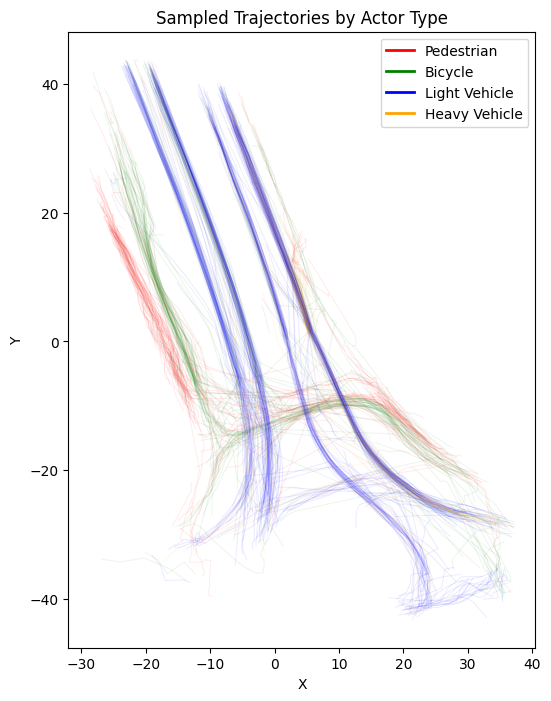

In [7]:
# Visualize a sample of trajectories by type
sample_ids = []
sample_sizes = {0: 150, 1: 150, 2: 300, 3: 80}

for t, n in sample_sizes.items():
    ids = df.loc[df["Type"] == t, "ID"].drop_duplicates().to_numpy()
    if len(ids) > n:
        ids = rng.choice(ids, size=n, replace=False)
    sample_ids.extend(ids.tolist())

sample_df = df[df["ID"].isin(sample_ids)].copy()

plt.figure(figsize=(8, 8))

for t, g in sample_df.groupby("Type"):
    for _, track in g.groupby("ID"):
        plt.plot(track["X"], track["Y"], color=colors[t], alpha=0.08, linewidth=0.7)

plt.gca().set_aspect("equal")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Sampled Trajectories by Actor Type")
plt.legend(handles=actor_legend_handles, loc="best", frameon=True)
plt.show()

In [8]:
# Define a broad region of interest (ROI) for interaction analysis
broad_roi = {
     "xmin": -15,
    "xmax": 17,
    "ymin": -22,
    "ymax": 0
}

broad_df = df[
    (df["X"] >= broad_roi["xmin"]) &
    (df["X"] <= broad_roi["xmax"]) &
    (df["Y"] >= broad_roi["ymin"]) &
    (df["Y"] <= broad_roi["ymax"])
].copy()

broad_track_counts = broad_df.groupby("Type")["ID"].nunique().rename(index=type_labels)
broad_row_counts = broad_df["Type"].value_counts().sort_index().rename(index=type_labels)

print("Unique tracks entering the broad interaction region:")
print(broad_track_counts)

print("\nRows inside the broad interaction region:")
print(broad_row_counts)

Unique tracks entering the broad interaction region:
Type
Pedestrian        1635
Bicycle          10863
Light Vehicle    37166
Heavy Vehicle     1539
Name: ID, dtype: int64

Rows inside the broad interaction region:
Type
Pedestrian        44210
Bicycle          160000
Light Vehicle    412131
Heavy Vehicle     18259
Name: count, dtype: int64


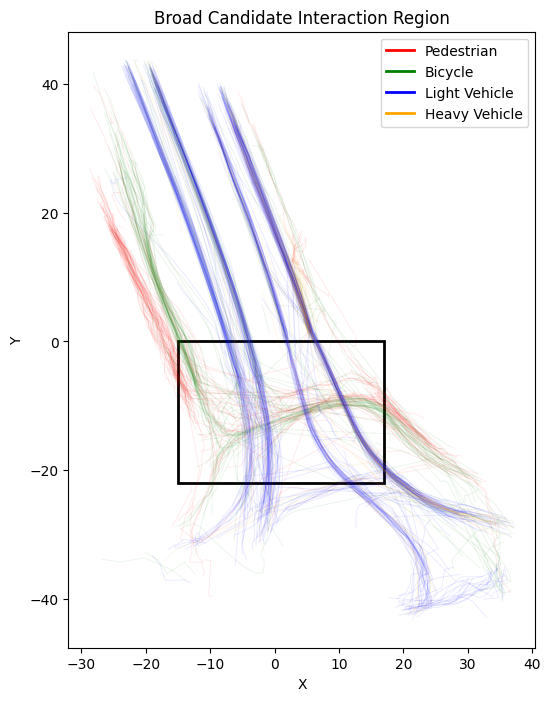

In [9]:
# Visualize trajectories in the broad interaction region
plt.figure(figsize=(8, 8))

for t, g in sample_df.groupby("Type"):
    for _, track in g.groupby("ID"):
        plt.plot(track["X"], track["Y"], color=colors[t], alpha=0.08, linewidth=0.7)

rect = Rectangle(
    (broad_roi["xmin"], broad_roi["ymin"]),
    broad_roi["xmax"] - broad_roi["xmin"],
    broad_roi["ymax"] - broad_roi["ymin"],
    fill=False,
    linewidth=2
)
plt.gca().add_patch(rect)

plt.gca().set_aspect("equal")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Broad Candidate Interaction Region")
plt.legend(handles=actor_legend_handles, loc="best", frameon=True)
plt.show()

### Interpretation of the spatial audit

The trajectory overlays reveal a clear multimodal interaction hub in which pedestrian, bicycle, and motor-vehicle flows overlap. Pedestrians and bicycles appear to traverse the scene laterally, while motor vehicles follow several more vertically oriented lane trajectories. A **broad candidate interaction region** can therefore be defined around the spatial area where these flows intersect.

The broad ROI was chosen **manually and conservatively** from the site-wide trajectory overlay. The aim at this stage was not to define the exact crossing corridor, but to create a first spatial screening region that was:

- **broad enough** to avoid prematurely excluding relevant crossing-approach trajectories;
- **narrow enough** to exclude clearly irrelevant parts of the scene;
- simple and reproducible in coordinates before the later corridor-based operationalization.

At this stage, the broad region is intended only for exploratory analysis and not yet as the final crossing polygon. Its purpose is to reduce the spatial scope of the later extraction pipeline, verify that a sufficient number of pedestrians and vehicles enter the same spatial area, and provide the parent frame for later refinement into a more operational corridor-and-approach geometry.

## Phase 1C: Refining the broad interaction region into an operational crossing corridor and candidate approach band

The broad interaction region identified in the spatial audit is now refined into a leaner geometry stack with distinct operational roles:

- a **crossing corridor**, representing the wider region in which pedestrian crossing is treated as having materially begun;
- and a **candidate approach band**, representing a wider pre-crossing neighborhood from which anticipation rows may later be sampled.


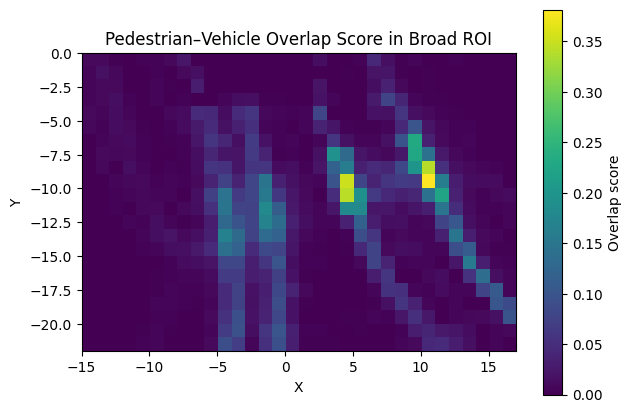

In [10]:
# Compute pedestrian–vehicle overlap score in the broad ROI
ped_df = broad_df[broad_df["Type"] == 0].copy()
veh_df = broad_df[broad_df["Type"].isin([2, 3])].copy()

xbins = np.arange(broad_roi["xmin"], broad_roi["xmax"] + 1, 1.0)
ybins = np.arange(broad_roi["ymin"], broad_roi["ymax"] + 1, 1.0)

H_ped, _, _ = np.histogram2d(ped_df["X"], ped_df["Y"], bins=[xbins, ybins])
H_veh, _, _ = np.histogram2d(veh_df["X"], veh_df["Y"], bins=[xbins, ybins])

H_ped_norm = H_ped / H_ped.max()
H_veh_norm = H_veh / H_veh.max()

overlap_score = np.sqrt(H_ped_norm * H_veh_norm)

plt.figure(figsize=(7, 5))
plt.imshow(
    overlap_score.T,
    origin="lower",
    extent=[xbins[0], xbins[-1], ybins[0], ybins[-1]],
    aspect="equal"
)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Pedestrian–Vehicle Overlap Score in Broad ROI")
plt.colorbar(label="Overlap score")
plt.show()

### Interpreting the pedestrian–vehicle overlap heatmap

The pedestrian–vehicle overlap heatmap should be read as a **concentration map of likely shared-use space**. High values indicate grid cells where **pedestrian presence** and **vehicle presence** are both relatively strong after separate normalization.

Importantly, the map shows **spatial co-presence**, not direct event-by-event interaction. It is therefore useful for informing where a corridor should be placed and how widely the surrounding approach neighborhood should extend, but it should **not** be treated as a direct label definition on its own.

The heatmap is used only as a supporting spatial diagnostic. The operational geometry carried forward into the modelling pipeline consists of a **crossing corridor** and a **candidate approach band**.

Unique tracks entering the crossing corridor:
Type
Pedestrian         919
Bicycle           8136
Light Vehicle    33834
Heavy Vehicle     1336
Name: ID, dtype: int64


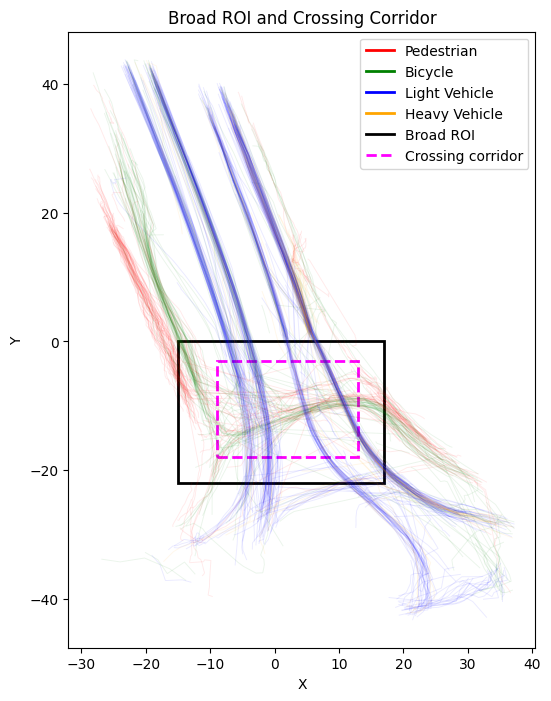

In [11]:
# Define the operational crossing corridor
crossing_corridor = {
    "xmin": -9,
    "xmax": 13,
    "ymin": -18,
    "ymax": -3
}

corridor_df = df[
    (df["X"] >= crossing_corridor["xmin"]) &
    (df["X"] <= crossing_corridor["xmax"]) &
    (df["Y"] >= crossing_corridor["ymin"]) &
    (df["Y"] <= crossing_corridor["ymax"])
].copy()

print("Unique tracks entering the crossing corridor:")
print(corridor_df.groupby("Type")["ID"].nunique().rename(index=type_labels))

# Visualize the broad ROI and crossing corridor with sampled tracks
plt.figure(figsize=(8, 8))

for t, g in sample_df.groupby("Type"):
    for _, track in g.groupby("ID"):
        plt.plot(track["X"], track["Y"], color=colors[t], alpha=0.08, linewidth=0.7)

ax = plt.gca()

broad_rect = Rectangle(
    (broad_roi["xmin"], broad_roi["ymin"]),
    broad_roi["xmax"] - broad_roi["xmin"],
    broad_roi["ymax"] - broad_roi["ymin"],
    fill=False,
    linewidth=2
)

corridor_rect = Rectangle(
    (crossing_corridor["xmin"], crossing_corridor["ymin"]),
    crossing_corridor["xmax"] - crossing_corridor["xmin"],
    crossing_corridor["ymax"] - crossing_corridor["ymin"],
    fill=False,
    linewidth=2,
    linestyle="--",
    edgecolor="magenta"
)

ax.add_patch(broad_rect)
ax.add_patch(corridor_rect)

geometry_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Broad ROI"),
    Line2D([0], [0], color="magenta", lw=2, linestyle="--", label="Crossing corridor"),
]

plt.gca().set_aspect("equal")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Broad ROI and Crossing Corridor")
plt.legend(handles=actor_legend_handles + geometry_handles, loc="best", frameon=True)
plt.show()

### Interpretation of the crossing corridor

The rectangle defined here should be interpreted as an **operational crossing corridor**, not as a perfect semantic ground truth of crossing intention. Its job is to capture the broader region in which crossing appears to have materially begun, even if some entering trajectories remain partial or ambiguous.

This is why the pedestrian traversal diagnostic is useful. A corridor intended to represent crossing onset should include many full traversals, but it may also contain hesitation, partial crossings, and other ambiguous movement. That ambiguity is more acceptable for a *corridor boundary* than it would be for a much narrower exploratory strip.

The revised corridor was kept somewhat wider on purpose. In a short-horizon anticipation task, it is preferable to begin with a corridor that is broad enough to include relevant crossing starts, and then examine the consequences of that operational choice explicitly in the later validity discussion.

### Methodological note: separating corridor and approach band

The pipeline now distinguishes between two operational geometric roles:

- the **crossing corridor**, which marks where crossing is treated as having materially begun;
- and the **candidate approach band**, which defines the wider pre-crossing neighborhood from which anticipation rows may later be sampled.

Unique tracks entering the candidate approach band:
Type
Pedestrian        1208
Bicycle           9652
Light Vehicle    34904
Heavy Vehicle     1448
Name: ID, dtype: int64


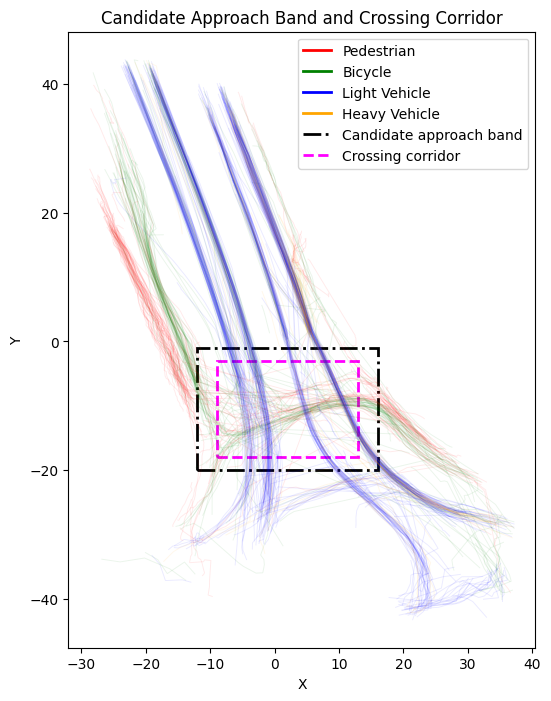

In [12]:
# Define and visualize a candidate approach band around the crossing corridor
approach_band_candidate = {
     "xmin": -12,
    "xmax": 16,
    "ymin": -20,
    "ymax": -1
}

approach_band_candidate_df = df[
    (df["X"] >= approach_band_candidate["xmin"]) &
    (df["X"] <= approach_band_candidate["xmax"]) &
    (df["Y"] >= approach_band_candidate["ymin"]) &
    (df["Y"] <= approach_band_candidate["ymax"])
].copy()

print("Unique tracks entering the candidate approach band:")
print(approach_band_candidate_df.groupby("Type")["ID"].nunique().rename(index=type_labels))

plt.figure(figsize=(8, 8))

for t, g in sample_df.groupby("Type"):
    for _, track in g.groupby("ID"):
        plt.plot(track["X"], track["Y"], color=colors[t], alpha=0.08, linewidth=0.7)

ax = plt.gca()

approach_rect = Rectangle(
    (approach_band_candidate["xmin"], approach_band_candidate["ymin"]),
    approach_band_candidate["xmax"] - approach_band_candidate["xmin"],
    approach_band_candidate["ymax"] - approach_band_candidate["ymin"],
    fill=False,
    linewidth=2,
    linestyle="-."
)

corridor_rect = Rectangle(
    (crossing_corridor["xmin"], crossing_corridor["ymin"]),
    crossing_corridor["xmax"] - crossing_corridor["xmin"],
    crossing_corridor["ymax"] - crossing_corridor["ymin"],
    fill=False,
    linewidth=2,
    linestyle="--",
    edgecolor="magenta"
)

ax.add_patch(approach_rect)
ax.add_patch(corridor_rect)

geometry_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle="-.", label="Candidate approach band"),
    Line2D([0], [0], color="magenta", lw=2, linestyle="--", label="Crossing corridor"),
]

plt.gca().set_aspect("equal")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Candidate Approach Band and Crossing Corridor")
plt.legend(handles=actor_legend_handles + geometry_handles, loc="best", frameon=True)
plt.show()

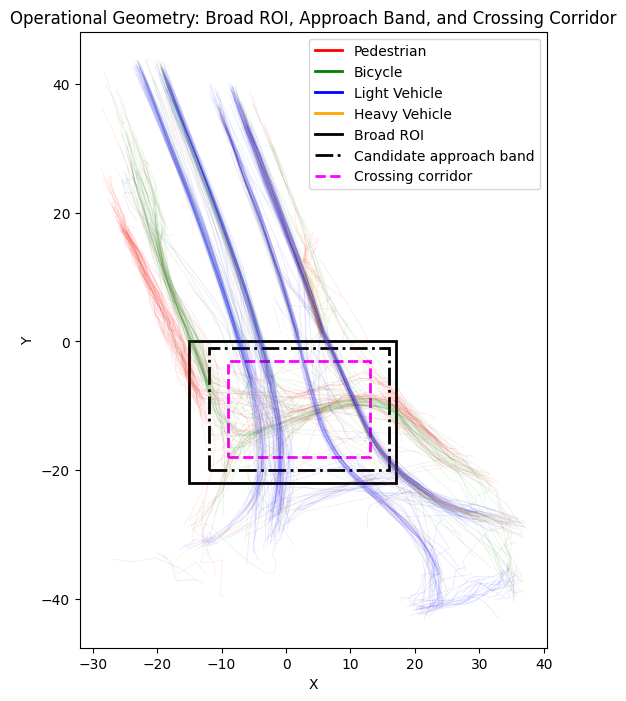

In [13]:
# Visualize the operational geometry together: broad ROI, approach band, and crossing corridor
plt.figure(figsize=(8, 8))

for t, g in sample_df.groupby("Type"):
    for _, track in g.groupby("ID"):
        plt.plot(track["X"], track["Y"], color=colors[t], alpha=0.08, linewidth=0.7)

ax = plt.gca()

broad_rect = Rectangle(
    (broad_roi["xmin"], broad_roi["ymin"]),
    broad_roi["xmax"] - broad_roi["xmin"],
    broad_roi["ymax"] - broad_roi["ymin"],
    fill=False,
    linewidth=2,
    linestyle="-"
)

approach_rect = Rectangle(
    (approach_band_candidate["xmin"], approach_band_candidate["ymin"]),
    approach_band_candidate["xmax"] - approach_band_candidate["xmin"],
    approach_band_candidate["ymax"] - approach_band_candidate["ymin"],
    fill=False,
    linewidth=2,
    linestyle="-."
)

corridor_rect = Rectangle(
    (crossing_corridor["xmin"], crossing_corridor["ymin"]),
    crossing_corridor["xmax"] - crossing_corridor["xmin"],
    crossing_corridor["ymax"] - crossing_corridor["ymin"],
    fill=False,
    linewidth=2,
    linestyle="--",
    edgecolor="magenta"
)

ax.add_patch(broad_rect)
ax.add_patch(approach_rect)
ax.add_patch(corridor_rect)

geometry_handles = [
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Broad ROI"),
    Line2D([0], [0], color="black", lw=2, linestyle="-.", label="Candidate approach band"),
    Line2D([0], [0], color="magenta", lw=2, linestyle="--", label="Crossing corridor"),
]

plt.gca().set_aspect("equal")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Operational Geometry: Broad ROI, Approach Band, and Crossing Corridor")
plt.legend(handles=actor_legend_handles + geometry_handles, loc="best", frameon=True)
plt.show()

## Phase 1D: Operational label construction and horizon choice

The target in this pipeline is an **operational short-horizon behavior proxy**, not direct psychological intention. A pedestrian row is labelled positive when the pedestrian enters the predefined **crossing corridor** within a future horizon.

This phase does two things in the correct methodological order:

1. it defines the label logic and checks a few example positives and negatives;
2. it compares **2 s**, **3 s**, and **5 s** before committing to the main executed horizon.

This ordering matters because the horizon is treated as a **design choice** that changes the target itself, not as a hidden background parameter.


In [14]:
# Analyze pedestrian tracks in the crossing corridor to estimate traversal directions
ped_tracks = df[df["Type"] == 0].sort_values(["ID", "Time"]).groupby("ID").agg(
    x_start=("X", "first"),
    x_end=("X", "last")
)

ped_corridor_ids = corridor_df.loc[corridor_df["Type"] == 0, "ID"].drop_duplicates()
ped_corridor_tracks = ped_tracks.loc[ped_corridor_ids]

left_to_right = (
    (ped_corridor_tracks["x_start"] < crossing_corridor["xmin"]) &
    (ped_corridor_tracks["x_end"] > crossing_corridor["xmax"])
).sum()

right_to_left = (
    (ped_corridor_tracks["x_start"] > crossing_corridor["xmax"]) &
    (ped_corridor_tracks["x_end"] < crossing_corridor["xmin"])
).sum()

other = len(ped_corridor_tracks) - left_to_right - right_to_left

print("Pedestrian tracks entering the crossing corridor:", len(ped_corridor_tracks))
print("Approximate left-to-right traversals:", left_to_right)
print("Approximate right-to-left traversals:", right_to_left)
print("Other / partial / ambiguous:", other)


Pedestrian tracks entering the crossing corridor: 919
Approximate left-to-right traversals: 179
Approximate right-to-left traversals: 115
Other / partial / ambiguous: 625


### Interpretation of the refined crossing geometry

The revised spatial audit now distinguishes between a **broader crossing corridor** and a **wider approach band**. The corridor is intended to represent the region in which crossing has materially begun, while the approach band is intended to retain enough pre-crossing context to support a short-horizon anticipation task.

The pedestrian traversal diagnostic is especially useful for the corridor. A corridor intended to represent crossing onset should include many full traversals, but it may also contain hesitation, partial crossings, starts/stops inside the corridor, and other ambiguous movement. That ambiguity is acceptable here because the corridor is an operational onset boundary rather than a claim about perfect semantic intention.

This means the corridor should not be interpreted as a perfect ground truth of intention. It is a reproducible geometric boundary for when crossing is treated as having begun in the present analysis.

### Methodological note: operational crossing geometry and label validity

The main working geometry used below is now the **crossing corridor**, together with the broader **candidate approach band**. Entering the corridor is treated as a reproducible proxy for when pedestrian crossing has materially begun, and the approach band defines where pre-crossing candidate rows are drawn from.

This design has three practical advantages for the analysis:

- it anchors the prediction target in clearly defined and reproducible regions;
- it allows timestamp-based short-horizon labelling without relying on subjective manual annotation of intention;
- it removes exploratory geometry that did not contribute operationally later in the pipeline.

At the same time, this operational choice still introduces limitations that must be acknowledged in the thesis report. Entering the corridor is treated as a proxy for crossing onset, but some pedestrians may hesitate, slow down, or move ambiguously near the crossing. For that reason, later labels such as `cross_soon` should **not** be interpreted as perfect ground-truth psychological intention labels. They are **operational, geometry-based labels** with some unavoidable ambiguity.

That ambiguity is not a weakness to hide; it is a core part of the thesis validity discussion.

## Phase 1D (continued): Horizon comparison before committing to the main executed setting

The next cell first constructs the label at the candidate main horizon and then summarizes the label behavior for **2 seconds**, **3 seconds**, and **5 seconds**.

These three horizons serve different purposes:

- **2 s** is the strictest and most immediate horizon.
- **3 s** is a middle ground between immediacy and learnability.
- **5 s** is broader and typically easier to predict, but less tightly tied to immediate behavior.

The comparison below is therefore part of the justification for selecting the main executed horizon.

In [15]:
# Pedestrian subset and corridor-based label logic
ped_df = df[df["Type"] == 0].sort_values(["ID", "Time"]).copy()

ped_df["in_crossing_corridor"] = (
    (ped_df["X"] >= crossing_corridor["xmin"]) &
    (ped_df["X"] <= crossing_corridor["xmax"]) &
    (ped_df["Y"] >= crossing_corridor["ymin"]) &
    (ped_df["Y"] <= crossing_corridor["ymax"])
)

ped_df["in_approach_candidate"] = (
    (ped_df["X"] >= approach_band_candidate["xmin"]) &
    (ped_df["X"] <= approach_band_candidate["xmax"]) &
    (ped_df["Y"] >= approach_band_candidate["ymin"]) &
    (ped_df["Y"] <= approach_band_candidate["ymax"])
)

# Eligible rows are near the crossing but still outside the crossing corridor
ped_df["eligible"] = (
    ped_df["in_approach_candidate"] &
    (~ped_df["in_crossing_corridor"])
)

# Function to compute future entry into the crossing corridor
def compute_cross_soon_label(track_df, horizon_sec):
    times = track_df["Time"].to_numpy(dtype="datetime64[ns]")
    in_corridor = track_df["in_crossing_corridor"].to_numpy()

    label = np.zeros(len(track_df), dtype=bool)

    corridor_times = times[in_corridor]
    if len(corridor_times) == 0:
        return pd.Series(label, index=track_df.index)

    pos = np.searchsorted(corridor_times, times, side="right")
    has_future_corridor = pos < len(corridor_times)

    next_corridor_times = np.full(len(track_df), np.datetime64("NaT"), dtype="datetime64[ns]")
    next_corridor_times[has_future_corridor] = corridor_times[pos[has_future_corridor]]

    label[has_future_corridor] = (
        (next_corridor_times[has_future_corridor] - times[has_future_corridor])
        <= np.timedelta64(horizon_sec, "s")
    )

    return pd.Series(label, index=track_df.index)

In [16]:
# Create the working label for H = 3 seconds and compare a disciplined short-horizon set
MAIN_HORIZON_SEC = 3
H = MAIN_HORIZON_SEC

# Compute the "cross_soon" label for each pedestrian track based on future entry into the crossing corridor
ped_df["cross_soon"] = False
for track_id, track in ped_df.groupby("ID"):
    ped_df.loc[track.index, "cross_soon"] = compute_cross_soon_label(track, horizon_sec=H)

ped_df["track_end_time"] = ped_df.groupby("ID")["Time"].transform("max")
ped_df["enough_future"] = (
    (ped_df["track_end_time"] - ped_df["Time"]) >= pd.Timedelta(seconds=H)
)

label_df = ped_df[ped_df["eligible"] & ped_df["enough_future"]].copy()

print(f"Eligible labelled observations for H = {H} seconds:", len(label_df))
print("\nClass balance:")
print(label_df["cross_soon"].value_counts())
print("\nClass proportions:")
print(label_df["cross_soon"].value_counts(normalize=True))

# Explore how the label distribution changes with different horizon values
horizon_results = []

for H_check in [2, 3, 5]:
    temp = ped_df.copy()

    temp["cross_soon"] = False
    for track_id, track in temp.groupby("ID"):
        temp.loc[track.index, "cross_soon"] = compute_cross_soon_label(track, horizon_sec=H_check)

    temp["track_end_time"] = temp.groupby("ID")["Time"].transform("max")
    temp["enough_future"] = (
        (temp["track_end_time"] - temp["Time"]) >= pd.Timedelta(seconds=H_check)
    )

    valid = temp[temp["eligible"] & temp["enough_future"]].copy()
    

    counts = valid["cross_soon"].value_counts()
    horizon_results.append({
        "horizon_sec": H_check,
        "n_valid": len(valid),
        "n_positive": int(counts.get(True, 0)),
        "n_negative": int(counts.get(False, 0)),
        "valid_tracks": valid["ID"].nunique(),
        "positive_rate": float(valid["cross_soon"].mean())
    })

horizon_summary = pd.DataFrame(horizon_results)
display(horizon_summary)

Eligible labelled observations for H = 3 seconds: 8537

Class balance:
cross_soon
False    5681
True     2856
Name: count, dtype: int64

Class proportions:
cross_soon
False    0.665456
True     0.334544
Name: proportion, dtype: float64


,horizon_sec,n_valid,n_positive,n_negative,valid_tracks,positive_rate
0,2,9044,2414,6630,861,0.266917
1,3,8537,2856,5681,809,0.334544
2,5,7760,2932,4828,714,0.377835


In [17]:
# Inspect a few positive and negative samples
print("Positive examples:")
display(label_df[label_df["cross_soon"]].head())

print("\nNegative examples:")
display(label_df[~label_df["cross_soon"]].head())

Positive examples:


,ID,Time,X,Y,Speed,Type,Estimated,in_crossing_corridor,in_approach_candidate,eligible,cross_soon,track_end_time,enough_future
48,294,2018-05-22 16:31:08.696000+02:00,13.612232,-7.482074,2.378536,0,1,False,True,True,True,2018-05-22 16:31:18.196000+02:00,True
75,296,2018-05-22 16:31:08.756000+02:00,13.450729,-7.139452,0.921683,0,1,False,True,True,True,2018-05-22 16:31:18.243000+02:00,True
14132,1252,2018-05-22 16:55:51.143000+02:00,-11.674256,-11.522255,5.944320,0,1,False,True,True,True,2018-05-22 16:55:59.076000+02:00,True
14133,1252,2018-05-22 16:55:51.396000+02:00,-11.078289,-11.474416,5.944320,0,1,False,True,True,True,2018-05-22 16:55:59.076000+02:00,True
14134,1252,2018-05-22 16:55:51.649000+02:00,-10.497115,-11.451919,5.944320,0,1,False,True,True,True,2018-05-22 16:55:59.076000+02:00,True



Negative examples:


,ID,Time,X,Y,Speed,Type,Estimated,in_crossing_corridor,in_approach_candidate,eligible,cross_soon,track_end_time,enough_future
42158,3070,2018-05-22 17:11:30.302000+02:00,-11.869552,-13.701772,5.750802,0,1,False,True,True,False,2018-05-22 17:11:52.037000+02:00,True
42159,3070,2018-05-22 17:11:30.555000+02:00,-11.738599,-13.607263,5.750802,0,1,False,True,True,False,2018-05-22 17:11:52.037000+02:00,True
42160,3070,2018-05-22 17:11:30.808000+02:00,-11.687413,-13.690998,5.750802,0,1,False,True,True,False,2018-05-22 17:11:52.037000+02:00,True
42161,3070,2018-05-22 17:11:31.061000+02:00,-11.652091,-13.521133,5.750802,0,1,False,True,True,False,2018-05-22 17:11:52.037000+02:00,True
42162,3070,2018-05-22 17:11:31.314000+02:00,-11.422717,-13.676620,5.750802,0,1,False,True,True,False,2018-05-22 17:11:52.037000+02:00,True


### Interpretation of the first event label

At this stage the pipeline has not yet claimed that **3 seconds** is universally optimal. It has only justified it as the main executed compromise. This distinction is important: later results are allowed to show that the empirical story changes when the horizon changes.

That is one of the report's main methodological arguments:
**design choices such as the future horizon materially affect the results.**

## Phase 1E: Building the first interpretable pedestrian feature table

This section converts each valid labelled pedestrian observation into a feature vector. The first feature set is deliberately simple and interpretable. It describes the pedestrian's current state, recent motion, and geometric relation to the **crossing corridor**. Only observations with sufficient past trajectory coverage are retained, so that the feature window is well-defined.

In [18]:
# Distance from a point to the crossing corridor
def point_to_box_distance(x, y, box):
    dx = np.maximum.reduce([box["xmin"] - x, np.zeros_like(x), x - box["xmax"]])
    dy = np.maximum.reduce([box["ymin"] - y, np.zeros_like(y), y - box["ymax"]])
    return np.sqrt(dx**2 + dy**2)

# Feature extraction from each pedestrian track
def extract_pedestrian_features(track_df):
    times = track_df["Time"].to_numpy(dtype="datetime64[ns]")
    x = track_df["X"].to_numpy()
    y = track_df["Y"].to_numpy()
    speed = track_df["Speed"].to_numpy()
    estimated = track_df["Estimated"].to_numpy()

    # Compute directly here instead of pre-storing in ped_df
    dist_to_corridor = point_to_box_distance(x, y, crossing_corridor)

    n = len(track_df)

    prev_1s_idx = np.searchsorted(times, times - np.timedelta64(1, "s"), side="right") - 1
    past_2s_start_idx = np.searchsorted(times, times - np.timedelta64(2, "s"), side="left")

    feat = pd.DataFrame(index=track_df.index)

    feat["speed_current"] = speed
    feat["dist_to_corridor"] = dist_to_corridor
    feat["estimated_current"] = estimated

    dx_1s = np.full(n, np.nan)
    dy_1s = np.full(n, np.nan)
    dt_1s = np.full(n, np.nan)
    speed_prev_1s = np.full(n, np.nan)

    valid_prev = prev_1s_idx >= 0
    valid_rows = np.where(valid_prev)[0]

    dx_1s[valid_rows] = x[valid_rows] - x[prev_1s_idx[valid_rows]]
    dy_1s[valid_rows] = y[valid_rows] - y[prev_1s_idx[valid_rows]]
    dt_1s[valid_rows] = (
        (times[valid_rows] - times[prev_1s_idx[valid_rows]]) / np.timedelta64(1, "s")
    )
    speed_prev_1s[valid_rows] = speed[prev_1s_idx[valid_rows]]

    feat["dx_past_1s"] = dx_1s
    feat["dy_past_1s"] = dy_1s
    feat["dt_past_1s"] = dt_1s
    feat["disp_past_1s"] = np.sqrt(dx_1s**2 + dy_1s**2)
    feat["heading_past_1s"] = np.arctan2(dy_1s, dx_1s)
    feat["speed_change_1s"] = speed - speed_prev_1s

    mean_speed_2s = np.empty(n)
    std_speed_2s = np.empty(n)
    estimated_frac_2s = np.empty(n)

    for i in range(n):
        start_i = past_2s_start_idx[i]
        window = slice(start_i, i + 1)

        mean_speed_2s[i] = np.mean(speed[window])
        std_speed_2s[i] = np.std(speed[window])
        estimated_frac_2s[i] = np.mean(estimated[window])

    feat["mean_speed_past_2s"] = mean_speed_2s
    feat["std_speed_past_2s"] = std_speed_2s
    feat["estimated_frac_past_2s"] = estimated_frac_2s

    return feat

# Build features for all pedestrian tracks
feature_parts = []
for ped_id, track in ped_df.groupby("ID"):
    feature_parts.append(extract_pedestrian_features(track))

feature_df = pd.concat(feature_parts).sort_index()

# Safe now: no duplicate engineered columns
ped_feature_df = pd.concat([ped_df, feature_df], axis=1)

# Require enough past history
ped_feature_df["track_start_time"] = ped_feature_df.groupby("ID")["Time"].transform("min")
ped_feature_df["enough_past_2s"] = (
    (ped_feature_df["Time"] - ped_feature_df["track_start_time"]) >= pd.Timedelta(seconds=2)
)

# Create the clean modelling table
model_df = ped_feature_df[
    ped_feature_df["eligible"] &
    ped_feature_df["enough_future"] &
    ped_feature_df["enough_past_2s"]
].copy()

feature_cols = [
    "speed_current",
    "dist_to_corridor",
    "estimated_current",
    "dx_past_1s",
    "dy_past_1s",
    "dt_past_1s",
    "disp_past_1s",
    "heading_past_1s",
    "speed_change_1s",
    "mean_speed_past_2s",
    "std_speed_past_2s",
    "estimated_frac_past_2s"
]

target_col = "cross_soon"

print("Final modelling table shape:", model_df.shape)
print("\nMissing values in feature columns:")
print(model_df[feature_cols].isna().sum())

print("\nTarget balance:")
print(model_df[target_col].value_counts())
print(model_df[target_col].value_counts(normalize=True))

# Inspect the modelling table
model_df[["ID", "Time"] + feature_cols + [target_col]].head(10)

Final modelling table shape: (7530, 27)

Missing values in feature columns:
speed_current             0
dist_to_corridor          0
estimated_current         0
dx_past_1s                0
dy_past_1s                0
dt_past_1s                0
disp_past_1s              0
heading_past_1s           0
speed_change_1s           0
mean_speed_past_2s        0
std_speed_past_2s         0
estimated_frac_past_2s    0
dtype: int64

Target balance:
cross_soon
False    5274
True     2256
Name: count, dtype: int64
cross_soon
False    0.700398
True     0.299602
Name: proportion, dtype: float64


,ID,Time,speed_current,dist_to_corridor,estimated_current,dx_past_1s,dy_past_1s,dt_past_1s,disp_past_1s,heading_past_1s,speed_change_1s,mean_speed_past_2s,std_speed_past_2s,estimated_frac_past_2s,cross_soon
14225,1321,2018-05-22 16:56:50.451000+02:00,4.623422,0.321979,1,0.780396,0.800178,1.012,1.117723,0.797913,0.0,4.623422,0.0,1.0,True
42166,3070,2018-05-22 17:11:32.326000+02:00,5.750802,1.609675,1,0.813042,-0.103193,1.012,0.819564,-0.126247,0.0,5.750802,0.0,1.0,False
42167,3070,2018-05-22 17:11:32.579000+02:00,5.750802,1.350694,1,0.856200,-0.320503,1.012,0.914221,-0.358185,0.0,5.750802,0.0,1.0,False
42168,3070,2018-05-22 17:11:32.832000+02:00,5.750802,1.438957,1,0.609577,-0.327954,1.012,0.692198,-0.493586,0.0,5.750802,0.0,1.0,False
42169,3070,2018-05-22 17:11:33.085000+02:00,5.750802,1.410095,1,0.406919,-0.380603,1.012,0.557173,-0.751993,0.0,5.750802,0.0,1.0,False
42170,3070,2018-05-22 17:11:33.338000+02:00,5.750802,1.199432,1,0.410243,-0.413513,1.012,0.582488,-0.789368,0.0,5.750802,0.0,1.0,False
42171,3070,2018-05-22 17:11:33.591000+02:00,5.750802,1.205000,1,0.145694,-0.137112,1.012,0.200066,-0.755059,0.0,5.750802,0.0,1.0,False
42172,3070,2018-05-22 17:11:33.844000+02:00,5.750802,0.975859,1,0.463098,-0.135400,1.012,0.482486,-0.284450,0.0,5.750802,0.0,1.0,False
42173,3070,2018-05-22 17:11:34.097000+02:00,5.750802,0.775346,1,0.634748,-0.181447,1.012,0.660173,-0.278431,0.0,5.750802,0.0,1.0,False
42174,3070,2018-05-22 17:11:34.350000+02:00,5.750802,0.701919,1,0.497513,-0.199537,1.012,0.536036,-0.381428,0.0,5.750802,0.0,1.0,False


### Interpretation of the first feature table

The first modelling table represents each valid pedestrian observation as an interpretable state description. The feature set is designed to capture four things:

1. **current motion state**, through variables such as `speed_current`;
2. **recent movement direction and displacement**, through `dx_past_1s`, `dy_past_1s`, `disp_past_1s`, `heading_past_1s`, and `speed_change_1s`;
3. **spatial relation to the target area**, through `dist_to_corridor`;
4. **tracking quality and short-history stability**, through `estimated_current`, `mean_speed_past_2s`, `std_speed_past_2s`, `estimated_frac_past_2s`, and `dt_past_1s`.

These choices are deliberate. If a pedestrian is likely to enter the corridor soon, that should be reflected not only in where the pedestrian is relative to the corridor, but also in how the pedestrian has been moving over the recent past. The table therefore provides a transparent pedestrian-only baseline before any vehicle context is added.

The use of a past observation window ensures that the predictors reflect recent motion rather than only the instantaneous state. Requiring both sufficient past coverage and sufficient future coverage also makes the dataset cleaner by reducing left-censoring and right-censoring.


## Phase 1F: Adding interpretable vehicle-interaction context

This section augments the pedestrian-only baseline with interaction-context features derived from nearby vehicles. Because object timestamps are not perfectly synchronized at the millisecond level, pedestrian observations and vehicle observations are matched using rounded scene-time bins. For each pedestrian observation, the nearest vehicle in the same local scene-time slice is identified, and interpretable interaction features are extracted.

The immediate goal is not to model every possible interaction mechanism, but to build a transparent first interaction-aware table using quantities such as nearest-vehicle distance, nearest-vehicle speed, relative position, and simple local vehicle density.

### Interaction matching via rounded scene time

Pedestrian and vehicle rows are not required to share exactly identical timestamps. To create a practical interaction table, the pipeline uses a rounded `scene_time` representation (**500 ms bins**) as an approximate synchronization strategy. Given a typical sampling interval of around **0.25 seconds**, this corresponds to roughly two usual sampling steps and therefore acts as a pragmatic compromise: wider than exact timestamp matching, but still local in time.

This should be understood as an engineering approximation rather than a perfect ground-truth pairing rule. The trade-off is clear:

- **smaller bins** would be more temporally precise, but would miss more plausible local pedestrian–vehicle co-occurrences;
- **larger bins** would recover more matches, but would blur together observations that are less clearly part of the same local scene moment.

The implemented pipeline therefore treats 500 ms as a practical first synchronization window, while acknowledging that it remains a revisitable design choice.

In [19]:
# Prepare the vehicle table and scene-time bins
# Reuse the revised broad ROI defined earlier in the pipeline.
veh_df = df[df["Type"].isin([2, 3])].sort_values(["ID", "Time"]).copy()

veh_df = veh_df[
    (veh_df["X"] >= broad_roi["xmin"]) &
    (veh_df["X"] <= broad_roi["xmax"]) &
    (veh_df["Y"] >= broad_roi["ymin"]) &
    (veh_df["Y"] <= broad_roi["ymax"])
].copy()

# Rounded scene-time matching
model_df["scene_time"] = model_df["Time"].dt.round("500ms")
veh_df["scene_time"] = veh_df["Time"].dt.round("500ms")

# Extract simple vehicle motion features
def extract_vehicle_features(track_df):
    times = track_df["Time"].to_numpy(dtype="datetime64[ns]")
    x = track_df["X"].to_numpy()
    y = track_df["Y"].to_numpy()
    speed = track_df["Speed"].to_numpy()

    n = len(track_df)
    prev_1s_idx = np.searchsorted(times, times - np.timedelta64(1, "s"), side="right") - 1

    feat = pd.DataFrame(index=track_df.index)

    dx_1s = np.full(n, np.nan)
    dy_1s = np.full(n, np.nan)

    valid_prev = prev_1s_idx >= 0
    valid_rows = np.where(valid_prev)[0]

    dx_1s[valid_rows] = x[valid_rows] - x[prev_1s_idx[valid_rows]]
    dy_1s[valid_rows] = y[valid_rows] - y[prev_1s_idx[valid_rows]]

    feat["vehicle_dx_past_1s"] = dx_1s
    feat["vehicle_dy_past_1s"] = dy_1s
    feat["vehicle_disp_past_1s"] = np.sqrt(dx_1s**2 + dy_1s**2)
    feat["vehicle_heading_past_1s"] = np.arctan2(dy_1s, dx_1s)
    feat["vehicle_speed_current"] = speed

    return feat

# Build vehicle motion table
veh_feature_parts = []
for veh_id, track in veh_df.groupby("ID"):
    veh_feature_parts.append(extract_vehicle_features(track))

veh_feature_df = pd.concat(veh_feature_parts).sort_index()
veh_df = pd.concat([veh_df, veh_feature_df], axis=1)

# Define the interaction matching function
def build_interaction_features_for_scene(ped_group, veh_group):
    out = pd.DataFrame(index=ped_group.index)

    if veh_group is None or len(veh_group) == 0:
        out["nearest_vehicle_distance"] = np.nan
        out["nearest_vehicle_speed"] = np.nan
        out["nearest_vehicle_type"] = np.nan
        out["rel_x_nearest_vehicle"] = np.nan
        out["rel_y_nearest_vehicle"] = np.nan
        out["nearest_vehicle_heading_past_1s"] = np.nan
        out["vehicles_within_5m"] = np.nan
        out["vehicles_within_10m"] = np.nan
        return out

    ped_xy = ped_group[["X", "Y"]].to_numpy()
    veh_xy = veh_group[["X", "Y"]].to_numpy()

    dx = veh_xy[:, 0][None, :] - ped_xy[:, 0][:, None]
    dy = veh_xy[:, 1][None, :] - ped_xy[:, 1][:, None]
    dist = np.sqrt(dx**2 + dy**2)

    nearest_idx = dist.argmin(axis=1)
    row_idx = np.arange(len(ped_group))

    veh_speed = veh_group["vehicle_speed_current"].to_numpy()
    veh_type = veh_group["Type"].to_numpy()
    veh_heading = veh_group["vehicle_heading_past_1s"].to_numpy()

    out["nearest_vehicle_distance"] = dist[row_idx, nearest_idx]
    out["nearest_vehicle_speed"] = veh_speed[nearest_idx]
    out["nearest_vehicle_type"] = veh_type[nearest_idx]
    out["rel_x_nearest_vehicle"] = dx[row_idx, nearest_idx]
    out["rel_y_nearest_vehicle"] = dy[row_idx, nearest_idx]
    out["nearest_vehicle_heading_past_1s"] = veh_heading[nearest_idx]
    out["vehicles_within_5m"] = (dist <= 5).sum(axis=1)
    out["vehicles_within_10m"] = (dist <= 10).sum(axis=1)

    return out

# Attach interaction features to the modelling table
veh_groups = {scene_time: group for scene_time, group in veh_df.groupby("scene_time")}

interaction_parts = []
for scene_time, ped_group in model_df.groupby("scene_time"):
    veh_group = veh_groups.get(scene_time)
    interaction_parts.append(build_interaction_features_for_scene(ped_group, veh_group))

interaction_df = pd.concat(interaction_parts).sort_index()
model_interaction_df = pd.concat([model_df, interaction_df], axis=1)

# Derive additional interpretable features
def wrap_to_pi(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

model_interaction_df["has_vehicle_context"] = (
    model_interaction_df["nearest_vehicle_distance"].notna().astype(int)
)

model_interaction_df["nearest_vehicle_is_heavy"] = np.where(
    model_interaction_df["nearest_vehicle_type"].isna(),
    np.nan,
    (model_interaction_df["nearest_vehicle_type"] == 3).astype(float)
)

# vehicle_ped_heading_diff: angular difference (wrapped to [-π, π]) between
# the nearest vehicle's recent heading and the pedestrian's recent heading.
# Computed here for completeness and exploratory inspection, but deliberately
# excluded from interaction_feature_cols_reduced and all_feature_cols_interaction
# used in the main models.  Reasons:
#   (1) vehicle_heading_past_1s is NaN for vehicles that lack ≥1 s of tracked
#       history (newly entering vehicles), yielding ~25–30 % missingness in
#       this derived field on the matched subset.
#   (2) Heading estimates are numerically unstable at very low vehicle speeds.
# The column is retained in model_interaction_df for inspection only.
model_interaction_df["vehicle_ped_heading_diff"] = wrap_to_pi(
    model_interaction_df["nearest_vehicle_heading_past_1s"] -
    model_interaction_df["heading_past_1s"]
)

# Diagnostic feature lists
interaction_feature_cols = [
    "nearest_vehicle_distance",
    "nearest_vehicle_speed",
    "nearest_vehicle_type",
    "rel_x_nearest_vehicle",
    "rel_y_nearest_vehicle",
    "nearest_vehicle_heading_past_1s",
    "vehicles_within_5m",
    "vehicles_within_10m",
    "nearest_vehicle_is_heavy",
    "vehicle_ped_heading_diff",
    "has_vehicle_context"
]

interaction_feature_cols_reduced = [
    "nearest_vehicle_distance",
    "nearest_vehicle_speed",
    "nearest_vehicle_type",
    "rel_x_nearest_vehicle",
    "rel_y_nearest_vehicle"
]

pedestrian_feature_cols = [
    "speed_current",
    "dist_to_corridor",
    "estimated_current",
    "dx_past_1s",
    "dy_past_1s",
    "dt_past_1s",
    "disp_past_1s",
    "heading_past_1s",
    "speed_change_1s",
    "mean_speed_past_2s",
    "std_speed_past_2s",
    "estimated_frac_past_2s"
]

all_feature_cols_interaction = pedestrian_feature_cols + interaction_feature_cols_reduced

# Define the interaction-focused subset
interaction_model_df = model_interaction_df[
    model_interaction_df["has_vehicle_context"] == 1
].copy()

# Inspect coverage and missingness
print("Vehicle-context coverage:")
print(model_interaction_df["has_vehicle_context"].value_counts())
print(model_interaction_df["has_vehicle_context"].value_counts(normalize=True))

print("\nMissing values in interaction features:")
print(model_interaction_df[interaction_feature_cols].isna().sum())

print("\nInteraction-focused subset shape:")
print(interaction_model_df.shape)

print("\nInteraction-focused target balance:")
print(interaction_model_df["cross_soon"].value_counts())
print(interaction_model_df["cross_soon"].value_counts(normalize=True))

print("\nMissing values in reduced interaction-model features:")
print(interaction_model_df[all_feature_cols_interaction].isna().sum())

# Inspect enriched rows
display_cols = [
    "ID",
    "Time",
    "cross_soon",
    "speed_current",
    "dist_to_corridor",
    "nearest_vehicle_distance",
    "nearest_vehicle_speed",
    "nearest_vehicle_type",
    "rel_x_nearest_vehicle",
    "rel_y_nearest_vehicle",
    "vehicles_within_5m",
    "vehicles_within_10m",
    "vehicle_ped_heading_diff",
    "has_vehicle_context"
]

model_interaction_df[display_cols].head(10)

Vehicle-context coverage:
has_vehicle_context
0    3902
1    3628
Name: count, dtype: int64
has_vehicle_context
0    0.518194
1    0.481806
Name: proportion, dtype: float64

Missing values in interaction features:
nearest_vehicle_distance           3902
nearest_vehicle_speed              3902
nearest_vehicle_type               3902
rel_x_nearest_vehicle              3902
rel_y_nearest_vehicle              3902
nearest_vehicle_heading_past_1s    5009
vehicles_within_5m                 3902
vehicles_within_10m                3902
nearest_vehicle_is_heavy           3902
vehicle_ped_heading_diff           5009
has_vehicle_context                   0
dtype: int64

Interaction-focused subset shape:
(3628, 39)

Interaction-focused target balance:
cross_soon
False    2559
True     1069
Name: count, dtype: int64
cross_soon
False    0.705347
True     0.294653
Name: proportion, dtype: float64

Missing values in reduced interaction-model features:
speed_current               0
dist_to_corridor    

,ID,Time,cross_soon,speed_current,dist_to_corridor,nearest_vehicle_distance,nearest_vehicle_speed,nearest_vehicle_type,rel_x_nearest_vehicle,rel_y_nearest_vehicle,vehicles_within_5m,vehicles_within_10m,vehicle_ped_heading_diff,has_vehicle_context
14225,1321,2018-05-22 16:56:50.451000+02:00,True,4.623422,0.321979,7.145867,4.924960,2.0,5.588214,-4.453682,0.0,1.0,1.001606,1
42166,3070,2018-05-22 17:11:32.326000+02:00,False,5.750802,1.609675,12.701360,17.093616,2.0,10.397408,-7.295099,0.0,0.0,NaN,1
42167,3070,2018-05-22 17:11:32.579000+02:00,False,5.750802,1.350694,12.390848,17.093616,2.0,10.138427,-7.123581,0.0,0.0,NaN,1
42168,3070,2018-05-22 17:11:32.832000+02:00,False,5.750802,1.438957,11.482671,15.224301,2.0,10.272048,-5.131936,0.0,0.0,NaN,1
42169,3070,2018-05-22 17:11:33.085000+02:00,False,5.750802,1.410095,11.440213,15.224301,2.0,10.243185,-5.094668,0.0,0.0,NaN,1
42170,3070,2018-05-22 17:11:33.338000+02:00,False,5.750802,1.199432,10.262590,15.562013,2.0,9.930945,-2.587873,0.0,0.0,2.373257,1
42171,3070,2018-05-22 17:11:33.591000+02:00,False,5.750802,1.205000,10.294912,15.562013,2.0,9.936513,-2.692756,0.0,0.0,2.338948,1
42172,3070,2018-05-22 17:11:33.844000+02:00,False,5.750802,0.975859,9.371659,15.868268,2.0,9.367688,-0.272816,0.0,2.0,1.948390,1
42173,3070,2018-05-22 17:11:34.097000+02:00,False,5.750802,0.775346,9.169133,15.868268,2.0,9.167175,-0.189500,0.0,2.0,1.942371,1
42174,3070,2018-05-22 17:11:34.350000+02:00,False,5.750802,0.701919,8.916139,16.217556,2.0,8.600534,2.351246,0.0,2.0,2.126180,1


In [20]:
# ── 500 ms scene-time binning diagnostic ─────────────────────────────────────
# Quantify consequences of the 500 ms synchronisation window.
# (a) What fraction of pedestrian rows receive a vehicle match?
# (b) Does the match rate differ between positive and negative rows?
# (c) How often is the scene genuinely multi-vehicle (≥2 vehicles nearby)?

match_diag = model_interaction_df[["has_vehicle_context", "cross_soon"]].copy()

total_rows    = len(match_diag)
matched_rows  = int(match_diag["has_vehicle_context"].sum())
unmatched_rows = total_rows - matched_rows

print("500 ms scene-time match rate")
print(f"Total eligible pedestrian rows : {total_rows:>8,}")
print(f"Rows WITH vehicle context      : {matched_rows:>8,}  "
      f"({matched_rows / total_rows * 100:.1f} %)")
print(f"Rows WITHOUT vehicle context   : {unmatched_rows:>8,}  "
      f"({unmatched_rows / total_rows * 100:.1f} %)")

print("\nMatch rate by class label")
for lbl, lbl_name in [(True, "cross_soon = 1  (positive)"),
                       (False, "cross_soon = 0  (negative)")]:
    sub  = match_diag[match_diag["cross_soon"] == lbl]
    rate = sub["has_vehicle_context"].mean()
    print(f"  {lbl_name:<28}  match rate = {rate:.3f}  (n = {len(sub):,})")

# Multi-vehicle density
density_df = model_interaction_df.loc[
    model_interaction_df["has_vehicle_context"] == 1,
    ["vehicles_within_5m", "vehicles_within_10m"]
].copy()

multi5m  = (density_df["vehicles_within_5m"]  >= 2).mean()
multi10m = (density_df["vehicles_within_10m"] >= 2).mean()

print("\n Multi-vehicle density in matched rows")
print("vehicles_within_5m  value counts:")
print(density_df["vehicles_within_5m"].value_counts().sort_index().head(8).to_string())
print("\nvehicles_within_10m value counts:")
print(density_df["vehicles_within_10m"].value_counts().sort_index().head(8).to_string())
print(f"\nRows with ≥2 vehicles within  5 m : {multi5m * 100:.1f} %")
print(f"Rows with ≥2 vehicles within 10 m : {multi10m * 100:.1f} %")
print(
    "\nMethodological note: nearest_vehicle_distance captures the single closest"
    " vehicle by construction.\n"
    "In genuinely multi-vehicle scenes the nearest vehicle may not be the most"
    " behaviourally\n"
    "relevant one.  The density features (vehicles_within_5m, vehicles_within_10m)"
    " partially\n"
    "compensate, but a full multi-agent representation would require a richer scene"
    " encoding."
)

500 ms scene-time match rate
Total eligible pedestrian rows :    7,530
Rows WITH vehicle context      :    3,628  (48.2 %)
Rows WITHOUT vehicle context   :    3,902  (51.8 %)

Match rate by class label
  cross_soon = 1  (positive)    match rate = 0.474  (n = 2,256)
  cross_soon = 0  (negative)    match rate = 0.485  (n = 5,274)

 Multi-vehicle density in matched rows
vehicles_within_5m  value counts:
vehicles_within_5m
0.0    3417
1.0      81
2.0     107
3.0       6
4.0      13
5.0       4

vehicles_within_10m value counts:
vehicles_within_10m
0.0    2284
1.0     287
2.0     934
3.0      53
4.0      58
5.0       5
6.0       4
7.0       3

Rows with ≥2 vehicles within  5 m : 3.6 %
Rows with ≥2 vehicles within 10 m : 29.1 %

Methodological note: nearest_vehicle_distance captures the single closest vehicle by construction.
In genuinely multi-vehicle scenes the nearest vehicle may not be the most behaviourally
relevant one.  The density features (vehicles_within_5m, vehicles_within_10m) pa

### Interpretation of the interaction-context features

The pedestrian-only baseline is extended with interpretable vehicle-context variables that describe the local interaction environment at the observation time. Matching is performed at a rounded scene-time level (**500 ms bins**), so these variables should be interpreted as an approximate local scene representation rather than exact ground-truth pairings.

The interaction features were chosen to capture five dimensions of local vehicle context:

1. **proximity** through `nearest_vehicle_distance`;
2. **vehicle motion** through `nearest_vehicle_speed`;
3. **relative geometry** through `rel_x_nearest_vehicle` and `rel_y_nearest_vehicle`;
4. **vehicle type** through `nearest_vehicle_type` / `nearest_vehicle_is_heavy`;
5. **local density** through `vehicles_within_5m` and `vehicles_within_10m`.

This follows the broader idea that short-horizon road-user behaviour can depend not only on the pedestrian’s own kinematics but also on nearby interaction context (Mohammadi et al., 2023). At the same time, these variables remain simplified summaries. They depend on the **500 ms** co-occurrence rule and do not provide a full multi-agent interaction representation.

Two practical findings matter:

- many eligible pedestrian rows do **not** have matched vehicle context at the chosen scene-time resolution — the exact proportion and any difference between positive and negative rows are shown in the diagnostic output;
- the simpler nearest-vehicle variables (distance, speed, type, relative position) are more robust than heading-based interaction variables, because the latter require sufficient tracked history to produce a stable estimate.

**On `vehicle_ped_heading_diff`:** this angular-difference feature is computed and retained in `model_interaction_df` for exploratory inspection, but is intentionally excluded from `interaction_feature_cols_reduced` and `all_feature_cols_interaction`. Two reasons apply: (1) `vehicle_heading_past_1s` is NaN for newly entering vehicles lacking ≥1 s of history, producing substantial missingness; (2) heading estimates are unreliable at low speeds. Including the feature would require imputation or missingness-aware modelling that would complicate the clean baseline-versus-interaction comparison.

**On multi-vehicle scenes:** the density diagnostic above shows how often ≥2 vehicles are simultaneously present within 5 m and 10 m of the pedestrian. When this fraction is non-trivial, the nearest-vehicle features provide only a partial picture of the interaction environment. This is acknowledged as a limitation of the current feature design and is noted later in the report discussion.


## Locked modelling boundary

From this point onward, the pipeline moves from data understanding and operationalization into model-ready tables. The test set is locked from this boundary and is not examined until final evaluation in Phase 2E.

The main executed modelling line now uses the **3-second horizon** chosen above. A later compact sensitivity section returns to **2 seconds** and **5 seconds** so that the horizon decision remains visible and discussable rather than hidden.

## Phase 2A: Leakage-safe and balance-aware train/validation/test split

The split is performed at the **pedestrian-track level** using trajectory ID. This avoids information leakage across train, validation, and test sets, since multiple rows from the same trajectory would otherwise be spread across different partitions.

The same ID split is then applied to both the **pedestrian-only** dataset and the **interaction-focused** dataset so that later model comparisons remain fair.

A simple track-level split is not always enough, because row-level balance can still drift after filtering. The final split is therefore selected using a more balance-aware track summary that takes into account whether a track ever contains a positive `cross_soon` label and whether it contributes interaction-context rows. This helps keep the partitions more stable for later threshold tuning and model comparison.

In [21]:
# Create a better-balanced ID-level split
target_col = "cross_soon" # where soon is defined as H = 3 seconds in the future, as per the main modelling table and = 1 indicates an imminent crossing event

# Track-level summary from the pedestrian modelling table
id_summary = (
    model_df.groupby("ID")
    .agg(
        n_rows=(target_col, "size"),
        n_positive=(target_col, "sum"),
        positive_rate=(target_col, "mean"),
        track_has_positive=(target_col, "max")
    )
    .reset_index()
)

# Add interaction-availability summary per track
int_id_summary = (
    interaction_model_df.groupby("ID")
    .agg(
        int_rows=(target_col, "size"),
        int_positive=(target_col, "sum"),
        int_positive_rate=(target_col, "mean")
    )
    .reset_index()
)

id_summary = id_summary.merge(int_id_summary, on="ID", how="left")

# Fill tracks with no interaction rows
id_summary["int_rows"] = id_summary["int_rows"].fillna(0).astype(int)
id_summary["int_positive"] = id_summary["int_positive"].fillna(0).astype(int)
id_summary["int_positive_rate"] = id_summary["int_positive_rate"].fillna(0.0)
id_summary["has_interaction"] = (id_summary["int_rows"] > 0).astype(int)

# Stratify on two important track-level properties:
# 1) whether the track ever has a positive row
# 2) whether the track contributes any interaction-context rows
id_summary["strat_key"] = (
    id_summary["track_has_positive"].astype(int).astype(str) + "_" +
    id_summary["has_interaction"].astype(int).astype(str)
)

overall_ped_rate = model_df[target_col].mean()
overall_int_rate = interaction_model_df[target_col].mean()
overall_int_coverage = len(interaction_model_df) / len(model_df)

def summarize_ids(ids):
    ped = model_df[model_df["ID"].isin(ids)]
    intr = interaction_model_df[interaction_model_df["ID"].isin(ids)]

    return {
        "ped_rows": len(ped),
        "ped_rate": ped[target_col].mean() if len(ped) else np.nan,
        "ped_positives": int(ped[target_col].sum()),
        "int_rows": len(intr),
        "int_rate": intr[target_col].mean() if len(intr) else np.nan,
        "int_positives": int(intr[target_col].sum()),
        "int_coverage": (len(intr) / len(ped)) if len(ped) else np.nan,
    }

def split_score(train_ids, val_ids, test_ids):
    score = 0.0
    for ids in [train_ids, val_ids, test_ids]:
        s = summarize_ids(ids)

        # Match row-level positive rates and interaction coverage
        score += abs(s["ped_rate"] - overall_ped_rate)
        score += abs(s["int_rate"] - overall_int_rate)
        score += 0.5 * abs(s["int_coverage"] - overall_int_coverage)

        # Penalize splits with very few positives
        if s["ped_positives"] < 50:
            score += 10
        if s["int_rows"] > 0 and s["int_positives"] < 20:
            score += 10

    return score

best = None
best_score = np.inf

# Search over seeds and keep the best-balanced split
for seed in range(300):
    try:
        train_ids, temp_ids = train_test_split(
            id_summary["ID"],
            test_size=0.30,
            random_state=seed,
            stratify=id_summary["strat_key"]
        )

        temp_summary = id_summary[id_summary["ID"].isin(temp_ids)].copy()

        val_ids, test_ids = train_test_split(
            temp_summary["ID"],
            test_size=0.50,
            random_state=seed,
            stratify=temp_summary["strat_key"]
        )

        train_ids = set(train_ids)
        val_ids = set(val_ids)
        test_ids = set(test_ids)

        score = split_score(train_ids, val_ids, test_ids)

        if score < best_score:
            best_score = score
            best = (train_ids, val_ids, test_ids, seed)

    except ValueError:
        # In case a seed creates an impossible stratified split
        continue

train_ids, val_ids, test_ids, best_seed = best

print("Best seed:", best_seed)
print("Best split score:", round(best_score, 6))
print("Unique track counts:")
print("Train:", len(train_ids))
print("Validation:", len(val_ids))
print("Test:", len(test_ids))

# Apply the same split to both datasets
ped_train_df = model_df[model_df["ID"].isin(train_ids)].copy()
ped_val_df   = model_df[model_df["ID"].isin(val_ids)].copy()
ped_test_df  = model_df[model_df["ID"].isin(test_ids)].copy()

int_train_df = interaction_model_df[interaction_model_df["ID"].isin(train_ids)].copy()
int_val_df   = interaction_model_df[interaction_model_df["ID"].isin(val_ids)].copy()
int_test_df  = interaction_model_df[interaction_model_df["ID"].isin(test_ids)].copy()

def summarize_split(df, name, target_col="cross_soon"):
    return pd.Series({
        "rows": len(df),
        "unique_IDs": df["ID"].nunique(),
        "positives": int(df[target_col].sum()),
        "negatives": int((~df[target_col]).sum()),
        "positive_rate": float(df[target_col].mean())
    }, name=name)

split_summary = pd.DataFrame([
    summarize_split(ped_train_df, "ped_train"),
    summarize_split(ped_val_df,   "ped_val"),
    summarize_split(ped_test_df,  "ped_test"),
    summarize_split(int_train_df, "int_train"),
    summarize_split(int_val_df,   "int_val"),
    summarize_split(int_test_df,  "int_test"),
])

print("\nOverall row-level positive rates:")
print(f"Pedestrian-only overall:   {overall_ped_rate:.4f}")
print(f"Interaction-only overall:  {overall_int_rate:.4f}")
print(f"Interaction coverage overall: {overall_int_coverage:.4f}")

print("\nSplit summary:")
display(split_summary)

Best seed: 3
Best split score: 0.182814
Unique track counts:
Train: 440
Validation: 94
Test: 95

Overall row-level positive rates:
Pedestrian-only overall:   0.2996
Interaction-only overall:  0.2947
Interaction coverage overall: 0.4818

Split summary:


,rows,unique_IDs,positives,negatives,positive_rate
ped_train,5134.0,440.0,1582.0,3552.0,0.308142
ped_val,887.0,94.0,294.0,593.0,0.331454
ped_test,1509.0,95.0,380.0,1129.0,0.251822
int_train,2471.0,298.0,770.0,1701.0,0.311615
int_val,441.0,63.0,132.0,309.0,0.299320
int_test,716.0,65.0,167.0,549.0,0.233240


## Phase 2B: Locked logistic-regression baselines at the main 3-second horizon

Two logistic-regression models are trained first.

The first model uses only **pedestrian-state features** and serves as the main interpretable baseline.  
The second model uses pedestrian-state features together with stable **vehicle-interaction features** on the interaction-focused subset.

Logistic regression remains important because it offers three advantages:

1. it provides a transparent and reproducible baseline;
2. it supports direct coefficient-level interpretation after standardization;
3. it makes it possible to study interaction additions without simultaneously changing the model family.

Later sections then ask three broader questions:

- how do richer interaction groups behave through ablation?
- does a modest **MLP** extract additional non-linear signal?
- do sequence models justify their extra complexity?

In [22]:
# Prepare train/validation/test matrices for the two main logistic views.
X_ped_train = ped_train_df[pedestrian_feature_cols]
X_ped_val   = ped_val_df[pedestrian_feature_cols]
X_ped_test  = ped_test_df[pedestrian_feature_cols]

y_ped_train = ped_train_df[target_col].astype(int)
y_ped_val   = ped_val_df[target_col].astype(int)
y_ped_test  = ped_test_df[target_col].astype(int)

X_int_train = int_train_df[all_feature_cols_interaction]
X_int_val   = int_val_df[all_feature_cols_interaction]
X_int_test  = int_test_df[all_feature_cols_interaction]

y_int_train = int_train_df[target_col].astype(int)
y_int_val   = int_val_df[target_col].astype(int)
y_int_test  = int_test_df[target_col].astype(int)

# Build one logistic pipeline for the pedestrian-only baseline and one for the
# interaction-aware baseline. The model family stays fixed so the feature views
# can be compared cleanly.
ped_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

int_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

# Fit both logistic models on their locked training data.
ped_model.fit(X_ped_train, y_ped_train)
int_model.fit(X_int_train, y_int_train)

# Helper used throughout the pipeline to evaluate a probabilistic binary classifier
# at a chosen threshold.
def evaluate_binary_classifier(model, X, y, threshold=0.5, name="model"):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    return pd.Series({
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y, y_prob),
        "pr_auc": average_precision_score(y, y_prob),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }, name=name)

# First validation comparison at the default threshold of 0.5.
val_results = pd.DataFrame([
    evaluate_binary_classifier(ped_model, X_ped_val, y_ped_val, name="pedestrian_only_val"),
    evaluate_binary_classifier(int_model, X_int_val, y_int_val, name="interaction_aware_val"),
])

val_results


,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
pedestrian_only_val,0.717024,0.555270,0.734694,0.632504,0.760064,0.509029,420.0,173.0,78.0,216.0
interaction_aware_val,0.748299,0.559322,0.750000,0.640777,0.768756,0.504711,231.0,78.0,33.0,99.0


## Phase 2C: First model diagnostics and explainability

The first locked modelling stage is inspected in two complementary ways:

1. **confusion matrices**, which show the thresholded validation-time error profile of the first trained models;
2. **standardized coefficients**, which provide the first direct explainability readout.

Because logistic regression is trained on **standardized features**, fitted coefficients are comparable in magnitude. Larger absolute coefficients indicate stronger contribution to the log-odds of predicting `cross_soon`, while the sign indicates direction of association.

These first diagnostics are not treated as the final interpretation on their own. They provide the first explanation layer, later strengthened through the fair interaction-only comparison, threshold-tuned locked evaluation, and the staged feature-group ablation.

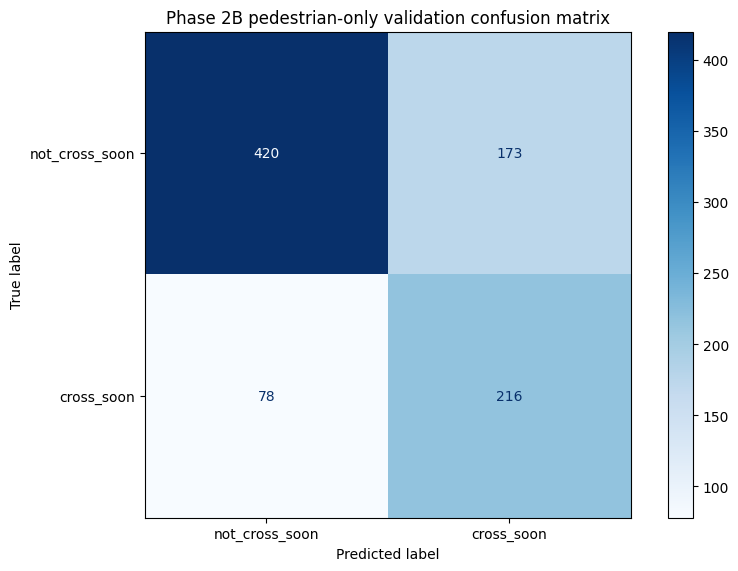

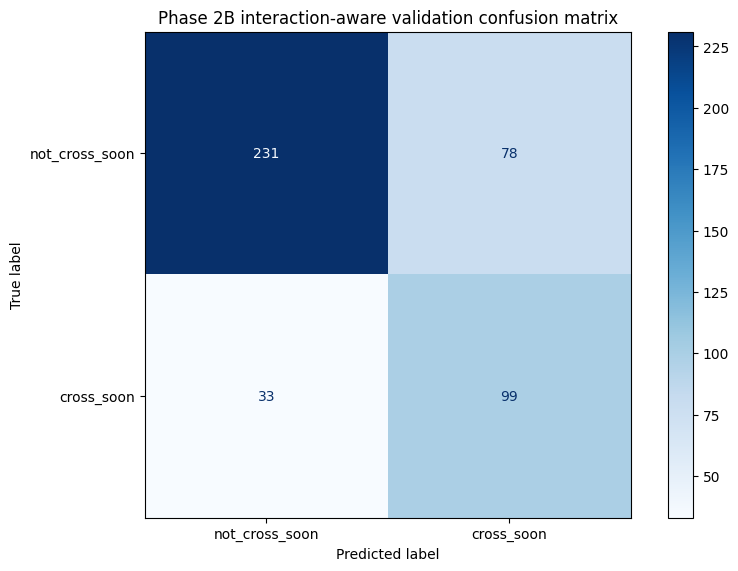

,feature,coefficient,abs_coefficient
3,dx_past_1s,-1.021035,1.021035
9,mean_speed_past_2s,0.757672,0.757672
7,heading_past_1s,0.511202,0.511202
11,estimated_frac_past_2s,0.397170,0.397170
5,dt_past_1s,-0.385644,0.385644
4,dy_past_1s,-0.366758,0.366758
0,speed_current,0.349684,0.349684
1,dist_to_corridor,-0.295231,0.295231
6,disp_past_1s,-0.248765,0.248765
10,std_speed_past_2s,0.205132,0.205132


In [23]:
# Confusion matrix function used throughout the pipeline
def plot_confusion_matrix_from_model(model, X, y, title, threshold=0.5):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    fig, ax = plt.subplots(figsize=(8.6, 5.6), constrained_layout=True)
    ConfusionMatrixDisplay.from_predictions(
        y,
        y_pred,
        display_labels=["not_cross_soon", "cross_soon"],
        cmap="Blues",
        ax=ax,
        colorbar=True,
        values_format="d"
    )
    ax.set_title(title)
    plt.show()

# First-model validation confusion matrices
plot_confusion_matrix_from_model(
    ped_model, X_ped_val, y_ped_val,
    title="Phase 2B pedestrian-only validation confusion matrix"
)

plot_confusion_matrix_from_model(
    int_model, X_int_val, y_int_val,
    title="Phase 2B interaction-aware validation confusion matrix"
)

# Coefficient table function for logistic regression models
def logistic_coefficient_table(fitted_pipeline, feature_names):
    coefs = fitted_pipeline.named_steps["clf"].coef_[0]
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs)
    }).sort_values("abs_coefficient", ascending=False)
    return coef_df

# Inspect pedestrian-only model coefficients
ped_coef_df = logistic_coefficient_table(ped_model, pedestrian_feature_cols)
ped_coef_df.head(15)

In [24]:
# Inspect interaction-aware model coefficients
int_coef_df = logistic_coefficient_table(int_model, all_feature_cols_interaction)
int_coef_df.head(15)

,feature,coefficient,abs_coefficient
9,mean_speed_past_2s,1.586124,1.586124
3,dx_past_1s,-0.925262,0.925262
7,heading_past_1s,0.610788,0.610788
11,estimated_frac_past_2s,0.508124,0.508124
5,dt_past_1s,-0.494788,0.494788
0,speed_current,-0.428726,0.428726
6,disp_past_1s,-0.394711,0.394711
13,nearest_vehicle_speed,0.366456,0.366456
1,dist_to_corridor,-0.325439,0.325439
4,dy_past_1s,-0.254182,0.254182


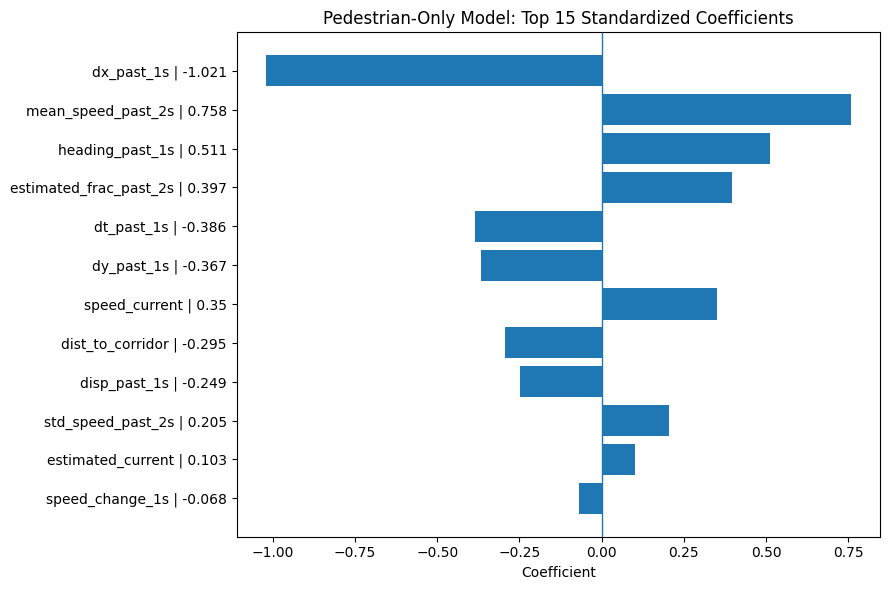

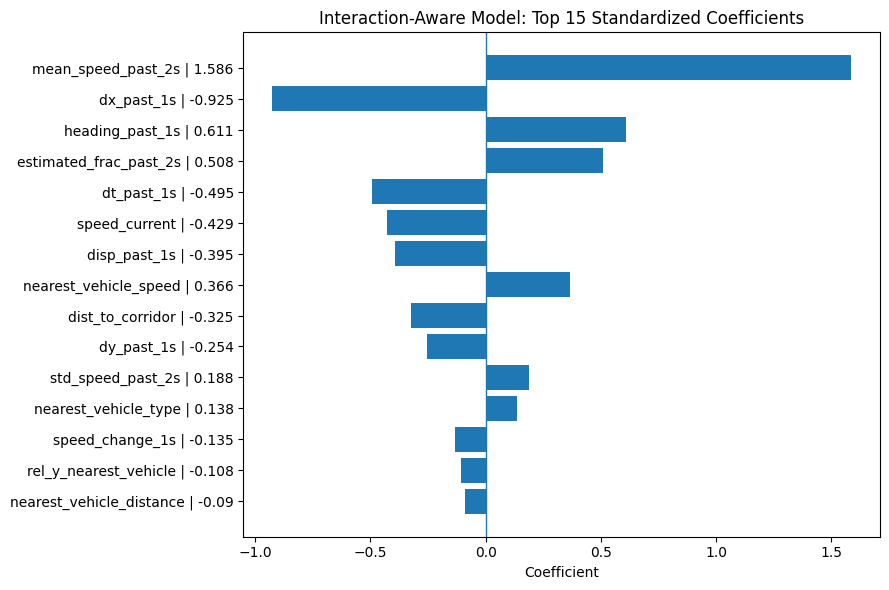

In [25]:
# Coefficient plots
def plot_logistic_coefficients_ranked(coef_df, title, top_n=15):
    plot_df = coef_df.head(top_n).copy()
    plot_df["label"] = (
        plot_df["feature"]
        + " | "
        + plot_df["coefficient"].round(3).astype(str)
    )
    plot_df = plot_df.iloc[::-1]

    plt.figure(figsize=(9, 6))
    plt.barh(plot_df["label"], plot_df["coefficient"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("Coefficient")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_logistic_coefficients_ranked(
    ped_coef_df,
    title="Pedestrian-Only Model: Top 15 Standardized Coefficients"
)

plot_logistic_coefficients_ranked(
    int_coef_df,
    title="Interaction-Aware Model: Top 15 Standardized Coefficients"
)

## Phase 2D: Fair comparison on the interaction subset

To isolate the added value of vehicle-context features, a pedestrian-only logistic-regression baseline is trained and evaluated on the **same interaction-focused subset**. This makes the comparison fair; otherwise, differences in performance could partly reflect differences in which rows were included rather than differences in the feature information available to the model.

This baseline therefore asks the clean scientific question: **when matched vehicle context is available, does adding interpretable vehicle context help?**

The confusion matrices below are restricted to this fair interaction-focused subset and should therefore be interpreted separately from the broader Phase 2B validation diagnostics above.

In [26]:
# Pedestrian-only baseline on the interaction subset
X_intped_train = int_train_df[pedestrian_feature_cols]
X_intped_val   = int_val_df[pedestrian_feature_cols]
X_intped_test  = int_test_df[pedestrian_feature_cols]

int_ped_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42
    ))
])

int_ped_model.fit(X_intped_train, y_int_train)

# Fair validation comparison
fair_val_results = pd.DataFrame([
    evaluate_binary_classifier(int_ped_model, X_intped_val, y_int_val, name="pedestrian_only_on_interaction_val"),
    evaluate_binary_classifier(int_model, X_int_val, y_int_val, name="interaction_aware_val"),
])

fair_val_results


,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
pedestrian_only_on_interaction_val,0.736961,0.547619,0.69697,0.613333,0.750000,0.479709,233.0,76.0,40.0,92.0
interaction_aware_val,0.748299,0.559322,0.75000,0.640777,0.768756,0.504711,231.0,78.0,33.0,99.0


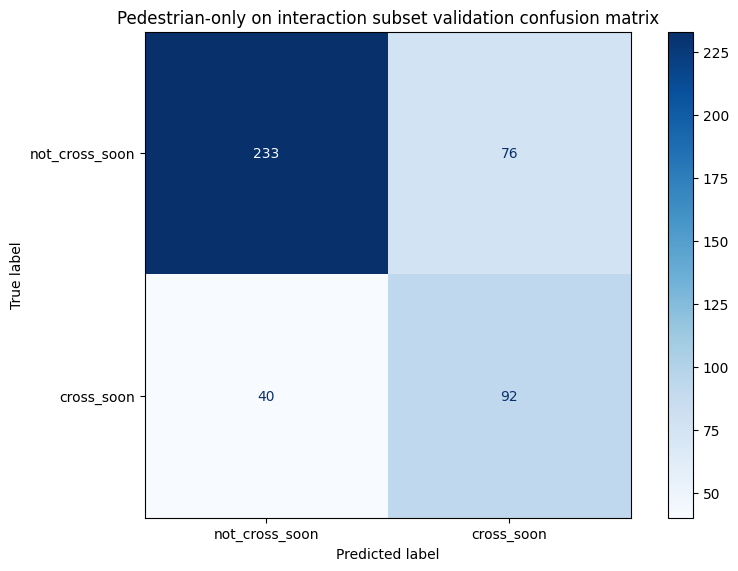

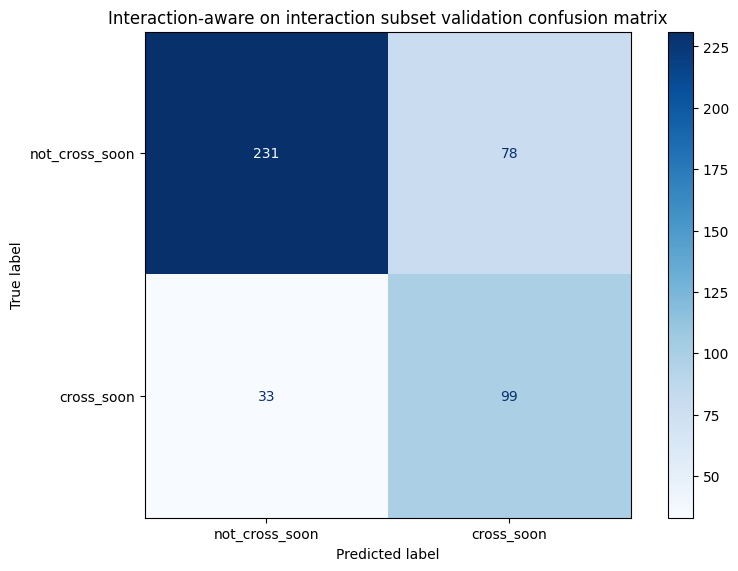

In [27]:
# Fair-subset validation confusion matrices
plot_confusion_matrix_from_model(
    int_ped_model, X_intped_val, y_int_val,
    title="Pedestrian-only on interaction subset validation confusion matrix"
)

plot_confusion_matrix_from_model(
    int_model, X_int_val, y_int_val,
    title="Interaction-aware on interaction subset validation confusion matrix"
)

## Phase 2E: Threshold tuning and locked test evaluation

The default classification threshold of **0.5** is not assumed to be optimal for an imbalanced safety-relevant prediction task. Thresholds are therefore tuned on the **validation set only**, first by inspecting a recall-oriented criterion based on **F2**, and then through a constrained analysis that enforces a minimum recall target.

This is important because logistic regression outputs probabilities, not inherently privileged yes/no decisions. Different thresholds produce different trade-offs between recall, precision, and false alarms, and those trade-offs matter in short-horizon traffic prediction.

Once a threshold is selected on the validation data, it is **locked** and applied once to the untouched test set. This separation between validation-time threshold selection and one-shot test evaluation keeps the final reported results methodologically clean.

Best pedestrian-only threshold on interaction validation subset:


,threshold,precision,recall,f1,f2,accuracy,tn,fp,fn,tp
22,0.27,0.41958,0.909091,0.574163,0.737101,0.596372,143.0,166.0,12.0,120.0


Best interaction-aware threshold on interaction validation subset:


,threshold,precision,recall,f1,f2,accuracy,tn,fp,fn,tp
21,0.26,0.428058,0.901515,0.580488,0.738213,0.609977,150.0,159.0,13.0,119.0


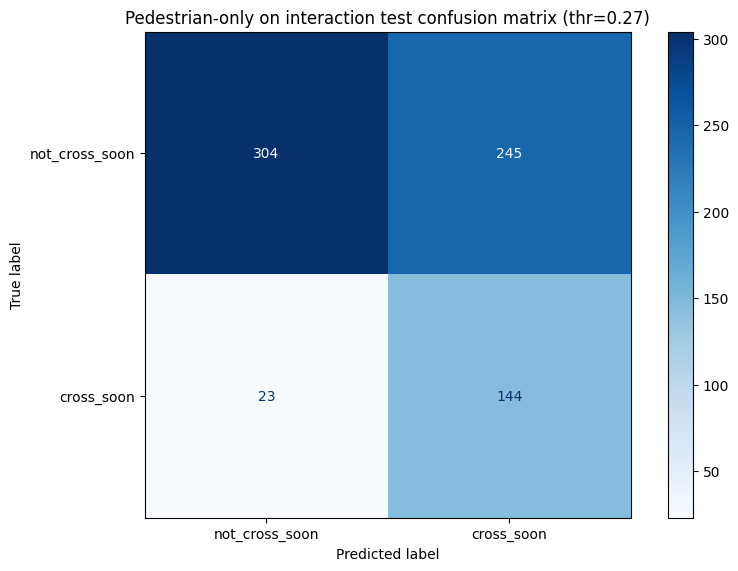

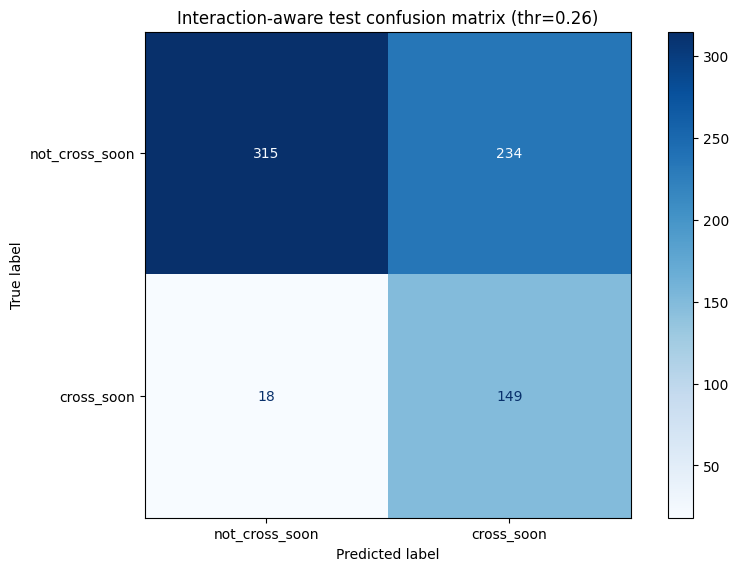

In [28]:
# Helper: sweep a probability threshold and return thresholded metrics for each
# operating point. This is used to choose recall-oriented thresholds on validation.
def threshold_sweep(model, X, y, beta=2.0, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.01)

    y_prob = model.predict_proba(X)[:, 1]
    rows = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

        rows.append({
            "threshold": t,
            "precision": precision_score(y, y_pred, zero_division=0),
            "recall": recall_score(y, y_pred, zero_division=0),
            "f1": f1_score(y, y_pred, zero_division=0),
            "f2": fbeta_score(y, y_pred, beta=beta, zero_division=0),
            "accuracy": accuracy_score(y, y_pred),
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp
        })

    return pd.DataFrame(rows)

# Sweep thresholds for both fair-subset logistic models.
int_ped_val_thresholds = threshold_sweep(int_ped_model, X_intped_val, y_int_val, beta=2.0)
int_val_thresholds = threshold_sweep(int_model, X_int_val, y_int_val, beta=2.0)

# Keep the threshold that is strongest on F2, then recall, then precision.
best_int_ped_row = int_ped_val_thresholds.sort_values(
    ["f2", "recall", "precision"],
    ascending=False
).iloc[0]

best_int_row = int_val_thresholds.sort_values(
    ["f2", "recall", "precision"],
    ascending=False
).iloc[0]

print("Best pedestrian-only threshold on interaction validation subset:")
display(best_int_ped_row.to_frame().T)

print("Best interaction-aware threshold on interaction validation subset:")
display(best_int_row.to_frame().T)

# Apply those validation-selected thresholds once to the locked test set.
best_thr_int_ped = float(best_int_ped_row["threshold"])
best_thr_int = float(best_int_row["threshold"])

locked_test_results = pd.DataFrame([
    evaluate_binary_classifier(
        int_ped_model,
        X_intped_test,
        y_int_test,
        threshold=best_thr_int_ped,
        name="pedestrian_only_on_interaction_test"
    ),
    evaluate_binary_classifier(
        int_model,
        X_int_test,
        y_int_test,
        threshold=best_thr_int,
        name="interaction_aware_test"
    ),
])

locked_test_results

# Test confusion matrices with locked thresholds.
plot_confusion_matrix_from_model(
    int_ped_model,
    X_intped_test,
    y_int_test,
    title=f"Pedestrian-only on interaction test confusion matrix (thr={best_thr_int_ped:.2f})",
    threshold=best_thr_int_ped
)

plot_confusion_matrix_from_model(
    int_model,
    X_int_test,
    y_int_test,
    title=f"Interaction-aware test confusion matrix (thr={best_thr_int:.2f})",
    threshold=best_thr_int
)


In [29]:
# among thresholds meeting a minimum recall, keep the one with the
# strongest precision, then F2, then threshold.
def choose_threshold_with_min_recall(threshold_df, min_recall=0.85):
    candidates = threshold_df[threshold_df["recall"] >= min_recall].copy()
    candidates = candidates.sort_values(
        ["precision", "f2", "threshold"],
        ascending=[False, False, False]
    )
    return candidates.iloc[0]

target_recall = 0.85

best_int_ped_recall_row = choose_threshold_with_min_recall(
    int_ped_val_thresholds,
    min_recall=target_recall
)

best_int_recall_row = choose_threshold_with_min_recall(
    int_val_thresholds,
    min_recall=target_recall
)

print("Pedestrian-only threshold under recall constraint:")
display(best_int_ped_recall_row.to_frame().T)

print("Interaction-aware threshold under recall constraint:")
display(best_int_recall_row.to_frame().T)

# Store the recall-constrained operating point for later cross-model synthesis.
thr_int_ped_recall = float(best_int_ped_recall_row["threshold"])
thr_int_recall = float(best_int_recall_row["threshold"])

recall_locked_test_results = pd.DataFrame([
    evaluate_binary_classifier(
        int_ped_model,
        X_intped_test,
        y_int_test,
        threshold=thr_int_ped_recall,
        name=f"pedestrian_only_test_recall_target_{target_recall:.2f}"
    ),
    evaluate_binary_classifier(
        int_model,
        X_int_test,
        y_int_test,
        threshold=thr_int_recall,
        name=f"interaction_aware_test_recall_target_{target_recall:.2f}"
    ),
])

recall_locked_test_results


Pedestrian-only threshold under recall constraint:


,threshold,precision,recall,f1,f2,accuracy,tn,fp,fn,tp
28,0.33,0.439689,0.856061,0.580977,0.719745,0.630385,165.0,144.0,19.0,113.0


Interaction-aware threshold under recall constraint:


,threshold,precision,recall,f1,f2,accuracy,tn,fp,fn,tp
26,0.31,0.452381,0.863636,0.59375,0.730769,0.646259,171.0,138.0,18.0,114.0


,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
pedestrian_only_test_recall_target_0.85,0.719274,0.442568,0.784431,0.565875,0.839763,0.632017,384.0,165.0,36.0,131.0
interaction_aware_test_recall_target_0.85,0.727654,0.455696,0.862275,0.596273,0.859745,0.668481,377.0,172.0,23.0,144.0


In [30]:
# Rebuild the canonical interaction splits from the locked ID split so that all
# later interaction-aware analyses reuse the same train/validation/test boundary.
interaction_df = interaction_model_df.copy()

int_train = interaction_df[interaction_df["ID"].isin(train_ids)].copy()
int_val   = interaction_df[interaction_df["ID"].isin(val_ids)].copy()
int_test  = interaction_df[interaction_df["ID"].isin(test_ids)].copy()

# Add a binary heavy-vehicle indicator once here so later ablation/model cells can
# reuse it without repeating the same transformation.
for part in [int_train, int_val, int_test]:
    if "nearest_vehicle_is_heavy" not in part.columns:
        part["nearest_vehicle_is_heavy"] = (part["nearest_vehicle_type"] == 3).astype(int)

print("Canonical interaction splits reconstructed from locked pipeline objects:")
print("int_train:", int_train.shape, "| unique IDs:", int_train["ID"].nunique())
print("int_val:  ", int_val.shape,   "| unique IDs:", int_val["ID"].nunique())
print("int_test: ", int_test.shape,  "| unique IDs:", int_test["ID"].nunique())

display(
    pd.DataFrame({
        "split": ["train", "validation", "test"],
        "rows": [len(int_train), len(int_val), len(int_test)],
        "unique_IDs": [int_train["ID"].nunique(), int_val["ID"].nunique(), int_test["ID"].nunique()],
        "positive_rate": [
            float(int_train[target_col].mean()),
            float(int_val[target_col].mean()),
            float(int_test[target_col].mean())
        ]
    })
)


Canonical interaction splits reconstructed from locked pipeline objects:
int_train: (2471, 39) | unique IDs: 298
int_val:   (441, 39) | unique IDs: 63
int_test:  (716, 39) | unique IDs: 65


,split,rows,unique_IDs,positive_rate
0,train,2471,298,0.311615
1,validation,441,63,0.299320
2,test,716,65,0.233240


## Phase 2F: Feature-group ablation for explainability

To make the interaction contribution easier to interpret, a **nested ablation ladder** is run on the locked interaction subset at the main **3-second** horizon. Starting from the pedestrian-only baseline, vehicle-context groups are added one at a time:

- **A:** pedestrian-only baseline  
- **B:** + nearest-vehicle proximity  
- **C:** + nearest-vehicle speed  
- **D:** + relative nearest-vehicle geometry  
- **E:** + vehicle type  
- **F:** + local density

Because the same model family and the same train/validation split are used throughout, any change in performance can be attributed more directly to the newly added group.

This ablation is used in two ways:

1. as a **main-horizon explainability tool** for understanding how interaction information behaves;
2. as a reference point for the later **2 s / 3 s / 5 s** sensitivity comparison.

The goal is not to force one universal interaction winner. The goal is to see whether the apparent usefulness of interaction context changes across horizons and model families.

,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,n_features
D_plus_relative_geometry,0.736961,0.544444,0.742424,0.628205,0.767064,0.506862,227.0,82.0,34.0,98.0,16.0
F_plus_local_density_full,0.736961,0.544944,0.734848,0.625806,0.767186,0.506018,228.0,81.0,35.0,97.0,19.0
E_plus_vehicle_type,0.748299,0.559322,0.750000,0.640777,0.768756,0.504711,231.0,78.0,33.0,99.0,17.0
C_plus_vehicle_motion,0.732426,0.538043,0.750000,0.626582,0.760444,0.498018,224.0,85.0,33.0,99.0,14.0
B_plus_proximity,0.732426,0.541176,0.696970,0.609272,0.750147,0.480790,231.0,78.0,40.0,92.0,13.0
A_pedestrian_only,0.736961,0.547619,0.696970,0.613333,0.750000,0.479709,233.0,76.0,40.0,92.0,12.0


,accuracy,precision,recall,f1,roc_auc,pr_auc,n_features,delta_accuracy,delta_precision,delta_recall,delta_f1,delta_roc_auc,delta_pr_auc
A_pedestrian_only,0.736961,0.547619,0.696970,0.613333,0.750000,0.479709,12.0,NaN,NaN,NaN,NaN,NaN,NaN
B_plus_proximity,0.732426,0.541176,0.696970,0.609272,0.750147,0.480790,13.0,-0.004535,-0.006443,0.000000,-0.004062,0.000147,0.001081
C_plus_vehicle_motion,0.732426,0.538043,0.750000,0.626582,0.760444,0.498018,14.0,0.000000,-0.003133,0.053030,0.017311,0.010297,0.017228
D_plus_relative_geometry,0.736961,0.544444,0.742424,0.628205,0.767064,0.506862,16.0,0.004535,0.006401,-0.007576,0.001623,0.006620,0.008844
E_plus_vehicle_type,0.748299,0.559322,0.750000,0.640777,0.768756,0.504711,17.0,0.011338,0.014878,0.007576,0.012572,0.001692,-0.002151
F_plus_local_density_full,0.736961,0.544944,0.734848,0.625806,0.767186,0.506018,19.0,-0.011338,-0.014378,-0.015152,-0.014970,-0.001569,0.001307


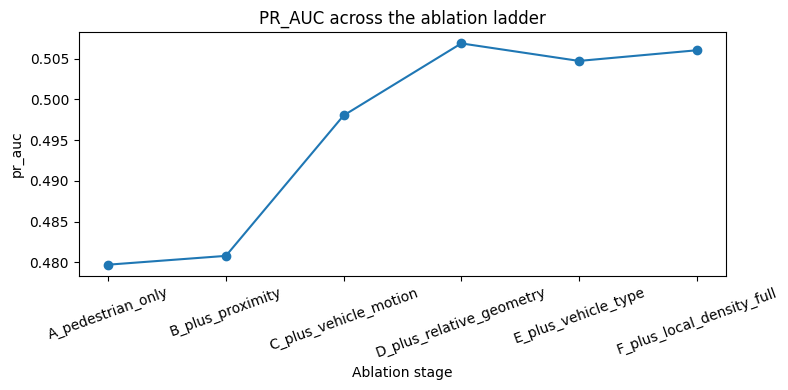

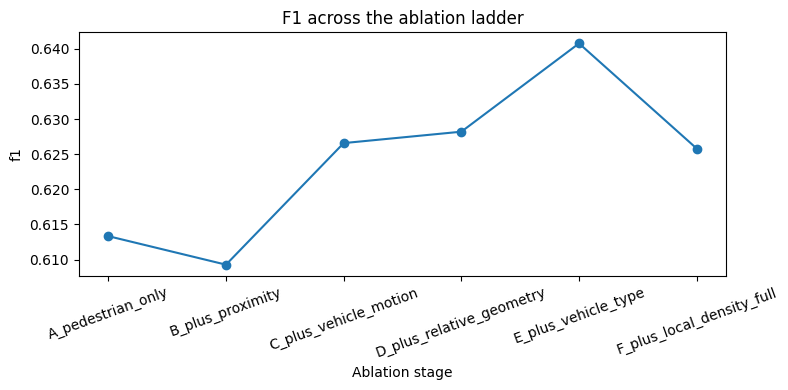

In [31]:
# Reuse the same interaction subset and define interpretable feature groups for
# the nested logistic ablation ladder.
target_col = "cross_soon"
pedestrian_feature_cols = list(dict.fromkeys(pedestrian_feature_cols))

for part in [int_train, int_val, int_test]:
    if "nearest_vehicle_is_heavy" not in part.columns:
        part["nearest_vehicle_is_heavy"] = (part["nearest_vehicle_type"] == 3).astype(int)

# Interaction groups are added one block at a time so the later gains can be read
# as changes associated with a new type of context.
vehicle_proximity_cols = [
    "nearest_vehicle_distance"
]

vehicle_motion_cols = [
    "nearest_vehicle_speed"
]

vehicle_geometry_cols = [
    "rel_x_nearest_vehicle",
    "rel_y_nearest_vehicle"
]

vehicle_type_cols = [
    "nearest_vehicle_is_heavy"
]

vehicle_density_cols = [
    "vehicles_within_5m",
    "vehicles_within_10m"
]

ablation_feature_sets = {
    "A_pedestrian_only": pedestrian_feature_cols,
    "B_plus_proximity": pedestrian_feature_cols + vehicle_proximity_cols,
    "C_plus_vehicle_motion": pedestrian_feature_cols + vehicle_proximity_cols + vehicle_motion_cols,
    "D_plus_relative_geometry": pedestrian_feature_cols + vehicle_proximity_cols + vehicle_motion_cols + vehicle_geometry_cols,
    "E_plus_vehicle_type": pedestrian_feature_cols + vehicle_proximity_cols + vehicle_motion_cols + vehicle_geometry_cols + vehicle_type_cols,
    "F_plus_local_density_full": pedestrian_feature_cols + vehicle_proximity_cols + vehicle_motion_cols + vehicle_geometry_cols + vehicle_type_cols + vehicle_density_cols,
}

ablation_feature_sets = {
    name: list(dict.fromkeys(cols))
    for name, cols in ablation_feature_sets.items()
}

ablation_models = {}
ablation_val_rows = []

for name, cols in ablation_feature_sets.items():
    X_train_ab = int_train[cols].copy()
    y_train_ab = int_train[target_col].astype(int)

    X_val_ab = int_val[cols].copy()
    y_val_ab = int_val[target_col].astype(int)

    model_ab = clone(int_model)
    model_ab.fit(X_train_ab, y_train_ab)

    ablation_models[name] = model_ab

    row = evaluate_binary_classifier(
        model_ab,
        X_val_ab,
        y_val_ab,
        threshold=0.5,
        name=name
    )
    row["n_features"] = len(cols)
    ablation_val_rows.append(row)

ablation_val_results = (
    pd.DataFrame(ablation_val_rows)
    .sort_values(["pr_auc", "f1", "roc_auc"], ascending=False)
)

ablation_val_results[
    ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "tn", "fp", "fn", "tp", "n_features"]
]

# Incremental gain table in the logical ablation order.
ablation_order = [
    "A_pedestrian_only",
    "B_plus_proximity",
    "C_plus_vehicle_motion",
    "D_plus_relative_geometry",
    "E_plus_vehicle_type",
    "F_plus_local_density_full",
]

ablation_gain_df = (
    ablation_val_results
    .loc[ablation_order, ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "n_features"]]
    .copy()
)

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]:
    ablation_gain_df[f"delta_{metric}"] = ablation_gain_df[metric].diff()

display(
    ablation_val_results[
        ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc", "tn", "fp", "fn", "tp", "n_features"]
    ]
)

display(ablation_gain_df)

# Compact plots for the two main metrics used later in the discussion.
plot_ablation_df = ablation_gain_df.reset_index().rename(columns={"index": "ablation_stage"})

for metric in ["pr_auc", "f1"]:
    plt.figure(figsize=(8, 4))
    plt.plot(plot_ablation_df["ablation_stage"], plot_ablation_df[metric], marker="o")
    plt.title(f"{metric.upper()} across the ablation ladder")
    plt.xlabel("Ablation stage")
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


## Interpretation of the ablation study

The ablation study is the main logistic interaction-analysis layer at the **3-second** horizon.

At this horizon, the key pattern is that interaction does **not** help in one simple monotonic way. **B_plus_proximity** adds very little beyond the pedestrian-only baseline, while the stronger gains appear in the richer middle stages. In the current output, **D_plus_relative_geometry** is the strongest stage on **PR-AUC**, and **E_plus_vehicle_type** is the strongest on the main thresholded validation metrics. This means that the main logistic interaction story is not “nearest-vehicle distance alone helps,” but rather that richer interaction structure can be more informative than proximity alone.

This section therefore serves three purposes:

1. to show that interaction gains are selective rather than automatic;
2. to identify which interaction groups are competitive at the main horizon;
3. to provide a structured reference for the later horizon-sensitivity comparison.


## Phase 2G: MLP and GRU at the main 3-second horizon

The main **3-second** modelling comparison now treats two richer model families as core parts of the project:

- **MLP** as the non-linear tabular comparison,
- **GRU** as the compact sequence-model comparison.

Both are evaluated in **pedestrian-only** and **interaction-aware** views on the same locked interaction subset where that comparison is meaningful.


### MLP at the main 3-second horizon

The MLP section tests whether a modest **non-linear tabular model** can extract additional signal from the same locked feature tables used in the logistic branch.

Two MLPs are compared on the locked interaction subset:

- **pedestrian-only**
- **interaction-aware** (full interaction feature table)

This makes the MLP a proper model-family comparison rather than a small add-on to the logistic baseline.


MLP validation comparison at threshold = 0.50:


,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
mlp_pedestrian_only_val,0.811791,0.652174,0.795455,0.716724,0.887639,0.794491,253.0,56.0,27.0,105.0
mlp_interaction_aware_val,0.832200,0.681250,0.825758,0.746575,0.904163,0.769603,258.0,51.0,23.0,109.0



MLP pedestrian-only threshold under recall constraint:


,threshold,precision,recall,f1,f2,accuracy,tn,fp,fn,tp
31,0.36,0.579487,0.856061,0.691131,0.781466,0.770975,227.0,82.0,19.0,113.0


MLP interaction-aware threshold under recall constraint:


,threshold,precision,recall,f1,f2,accuracy,tn,fp,fn,tp
27,0.32,0.666667,0.863636,0.752475,0.815451,0.829932,252.0,57.0,18.0,114.0



Locked MLP test comparison:


,accuracy,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
mlp_pedestrian_only_test_recall_target_0.85,0.860335,0.660287,0.826347,0.734043,0.931459,0.805570,478.0,71.0,29.0,138.0
mlp_interaction_aware_test_recall_target_0.85,0.875698,0.695000,0.832335,0.757493,0.949205,0.880693,488.0,61.0,28.0,139.0


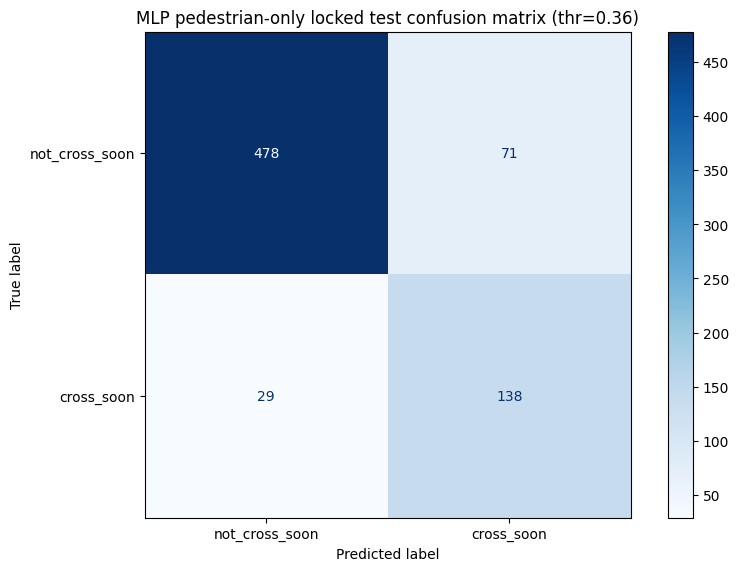

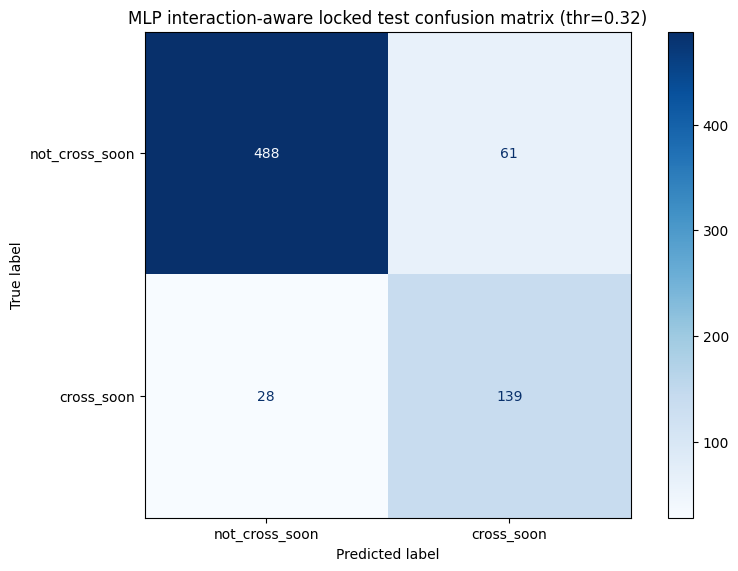


Compact MLP result table:


,setting,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,validation,mlp_pedestrian_only,0.50,0.811791,0.652174,0.795455,0.716724,0.887639,0.794491
1,validation,mlp_interaction_aware,0.50,0.832200,0.681250,0.825758,0.746575,0.904163,0.769603
2,test_locked_recall_target,mlp_pedestrian_only,0.36,0.860335,0.660287,0.826347,0.734043,0.931459,0.805570
3,test_locked_recall_target,mlp_interaction_aware,0.32,0.875698,0.695000,0.832335,0.757493,0.949205,0.880693


In [32]:
# Compare pedestrian-only and interaction-aware MLPs on the locked 3-second
# interaction subset so the feature views are evaluated on the same examples.
mlp_baseline_cols = list(dict.fromkeys(pedestrian_feature_cols))
mlp_interaction_cols = list(dict.fromkeys(all_feature_cols_interaction))

X_mlp_train_base = int_train[mlp_baseline_cols].copy()
X_mlp_val_base   = int_val[mlp_baseline_cols].copy()
X_mlp_test_base  = int_test[mlp_baseline_cols].copy()

X_mlp_train_int = int_train[mlp_interaction_cols].copy()
X_mlp_val_int   = int_val[mlp_interaction_cols].copy()
X_mlp_test_int  = int_test[mlp_interaction_cols].copy()

y_mlp_train = int_train[target_col].astype(int)
y_mlp_val   = int_val[target_col].astype(int)
y_mlp_test  = int_test[target_col].astype(int)

mlp_sample_weight = compute_sample_weight(class_weight="balanced", y=y_mlp_train)

# Small MLP with fixed hyperparameters so the comparison stays focused on feature
# view and model family rather than on a hyperparameter search.
def make_small_mlp(random_state=42):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            alpha=1e-4,
            learning_rate_init=1e-3,
            batch_size=128,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            random_state=random_state,
        ))
    ])

mlp_ped_model = make_small_mlp(random_state=RANDOM_STATE)
mlp_int_model = make_small_mlp(random_state=RANDOM_STATE)

mlp_ped_model.fit(X_mlp_train_base, y_mlp_train, clf__sample_weight=mlp_sample_weight)
mlp_int_model.fit(X_mlp_train_int, y_mlp_train, clf__sample_weight=mlp_sample_weight)

mlp_val_results = pd.DataFrame([
    evaluate_binary_classifier(mlp_ped_model, X_mlp_val_base, y_mlp_val, threshold=0.5, name="mlp_pedestrian_only_val"),
    evaluate_binary_classifier(mlp_int_model, X_mlp_val_int, y_mlp_val, threshold=0.5, name="mlp_interaction_aware_val"),
])

print("MLP validation comparison at threshold = 0.50:")
display(mlp_val_results)

# Reuse the earlier recall-constrained threshold rule for the two MLP views.
mlp_ped_thresholds = threshold_sweep(mlp_ped_model, X_mlp_val_base, y_mlp_val, beta=2.0)
mlp_int_thresholds = threshold_sweep(mlp_int_model, X_mlp_val_int, y_mlp_val, beta=2.0)

mlp_best_ped_row = choose_threshold_with_min_recall(mlp_ped_thresholds, min_recall=target_recall)
mlp_best_int_row = choose_threshold_with_min_recall(mlp_int_thresholds, min_recall=target_recall)

print("\nMLP pedestrian-only threshold under recall constraint:")
display(mlp_best_ped_row.to_frame().T)

print("MLP interaction-aware threshold under recall constraint:")
display(mlp_best_int_row.to_frame().T)

mlp_best_ped_thr = float(mlp_best_ped_row["threshold"])
mlp_best_int_thr = float(mlp_best_int_row["threshold"])

mlp_test_results = pd.DataFrame([
    evaluate_binary_classifier(
        mlp_ped_model, X_mlp_test_base, y_mlp_test,
        threshold=mlp_best_ped_thr,
        name=f"mlp_pedestrian_only_test_recall_target_{target_recall:.2f}"
    ),
    evaluate_binary_classifier(
        mlp_int_model, X_mlp_test_int, y_mlp_test,
        threshold=mlp_best_int_thr,
        name=f"mlp_interaction_aware_test_recall_target_{target_recall:.2f}"
    ),
])

print("\nLocked MLP test comparison:")
display(mlp_test_results)

plot_confusion_matrix_from_model(
    mlp_ped_model,
    X_mlp_test_base,
    y_mlp_test,
    title=f"MLP pedestrian-only locked test confusion matrix (thr={mlp_best_ped_thr:.2f})",
    threshold=mlp_best_ped_thr
)

plot_confusion_matrix_from_model(
    mlp_int_model,
    X_mlp_test_int,
    y_mlp_test,
    title=f"MLP interaction-aware locked test confusion matrix (thr={mlp_best_int_thr:.2f})",
    threshold=mlp_best_int_thr
)

mlp_summary = pd.DataFrame([
    {
        "setting": "validation",
        "model": "mlp_pedestrian_only",
        "threshold": 0.50,
        **mlp_val_results.loc["mlp_pedestrian_only_val", ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].to_dict()
    },
    {
        "setting": "validation",
        "model": "mlp_interaction_aware",
        "threshold": 0.50,
        **mlp_val_results.loc["mlp_interaction_aware_val", ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].to_dict()
    },
    {
        "setting": "test_locked_recall_target",
        "model": "mlp_pedestrian_only",
        "threshold": mlp_best_ped_thr,
        **mlp_test_results.loc[
            f"mlp_pedestrian_only_test_recall_target_{target_recall:.2f}",
            ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
        ].to_dict()
    },
    {
        "setting": "test_locked_recall_target",
        "model": "mlp_interaction_aware",
        "threshold": mlp_best_int_thr,
        **mlp_test_results.loc[
            f"mlp_interaction_aware_test_recall_target_{target_recall:.2f}",
            ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
        ].to_dict()
    },
])

print("\nCompact MLP result table:")
display(mlp_summary)


### Interpreting the MLP output

Read the validation and locked-test tables together. In the current outputs, the **interaction-aware MLP** is stronger than the pedestrian-only MLP on both validation and locked test, with higher **F1**, **ROC-AUC**, and especially **PR-AUC**. The locked-test difference is not marginal: the interaction-aware branch reaches about **0.757 F1** and **0.881 PR-AUC**, compared with about **0.734 F1** and **0.806 PR-AUC** for the pedestrian-only branch.

So at the main **3-second** horizon, the MLP result suggests two things:

1. non-linearity clearly improves on the logistic branch;
2. Within the MLP family, the interaction-aware representation produces stronger point estimates, though the McNemar test in Phase 2J shows this within-family difference does not reach statistical significance.


### Explainability for the strongest MLP branch

Logistic regression is already interpreted through standardized coefficients and the staged ablation. The MLP is different: it is one of the strongest non-linear results in the pipeline, but it is not intrinsically transparent.

To keep explainability focused, the next cell explains **one MLP only**: the stronger **main-horizon 3-second MLP branch**, chosen after locked evaluation for interpretation only. The explanation method is **permutation importance** using **average precision** as the scoring metric.


MLP branch selected for interpretation: mlp_interaction_aware


,accuracy,precision,recall,f1,roc_auc,pr_auc
mlp_interaction_aware_test_recall_target_0.85,0.875698,0.695,0.832335,0.757493,0.949205,0.880693



Permutation importance for the selected MLP branch (scoring = average precision):


,feature,importance_mean,importance_std
15,rel_x_nearest_vehicle,0.187494,0.021372
3,dx_past_1s,0.154471,0.022871
0,speed_current,0.132907,0.030600
1,dist_to_corridor,0.074441,0.007593
7,heading_past_1s,0.068188,0.012096
10,std_speed_past_2s,0.048998,0.019238
4,dy_past_1s,0.047753,0.006353
11,estimated_frac_past_2s,0.033628,0.008042
8,speed_change_1s,0.032926,0.010595
13,nearest_vehicle_speed,0.024928,0.006082


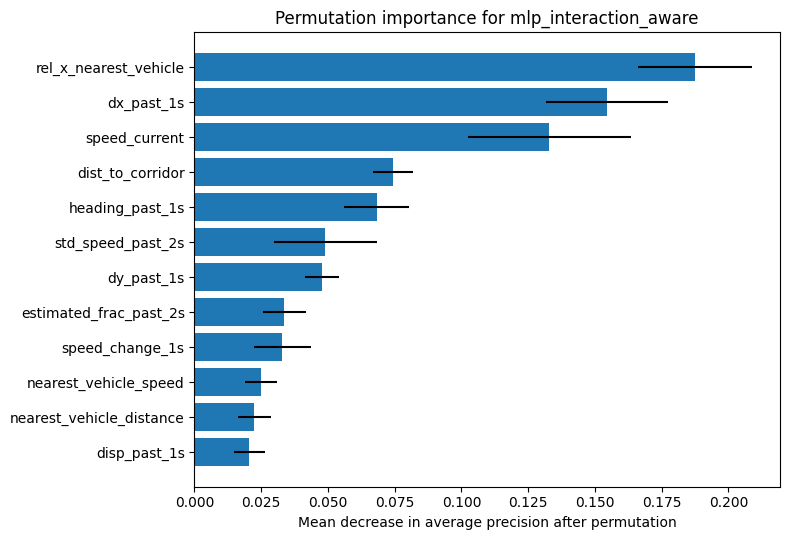

In [33]:
# Explain only the stronger MLP branch so the non-linear interpretation stays
# focused on the most relevant 3-second result.
mlp_explainability_candidates = {
    "mlp_pedestrian_only": {
        "model": mlp_ped_model,
        "X_test": X_mlp_test_base,
        "y_test": y_mlp_test,
        "feature_cols": mlp_baseline_cols,
        "summary_row": mlp_test_results.loc[
            f"mlp_pedestrian_only_test_recall_target_{target_recall:.2f}",
            ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
        ]
    },
    "mlp_interaction_aware": {
        "model": mlp_int_model,
        "X_test": X_mlp_test_int,
        "y_test": y_mlp_test,
        "feature_cols": mlp_interaction_cols,
        "summary_row": mlp_test_results.loc[
            f"mlp_interaction_aware_test_recall_target_{target_recall:.2f}",
            ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
        ]
    }
}

mlp_branch_name = max(
    mlp_explainability_candidates,
    key=lambda k: (
        mlp_explainability_candidates[k]["summary_row"]["pr_auc"],
        mlp_explainability_candidates[k]["summary_row"]["f1"],
        mlp_explainability_candidates[k]["summary_row"]["roc_auc"]
    )
)

mlp_explain = mlp_explainability_candidates[mlp_branch_name]

print(f"MLP branch selected for interpretation: {mlp_branch_name}")
display(mlp_explain["summary_row"].to_frame().T)

perm_result = permutation_importance(
    mlp_explain["model"],
    mlp_explain["X_test"],
    mlp_explain["y_test"],
    scoring="average_precision",
    n_repeats=20,
    random_state=RANDOM_STATE,
)

mlp_perm_df = pd.DataFrame({
    "feature": mlp_explain["feature_cols"],
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)

print("\nPermutation importance for the selected MLP branch (scoring = average precision):")
display(mlp_perm_df)

top_k = min(12, len(mlp_perm_df))
plot_perm_df = mlp_perm_df.head(top_k).sort_values("importance_mean")

plt.figure(figsize=(8, 5.5))
plt.barh(plot_perm_df["feature"], plot_perm_df["importance_mean"], xerr=plot_perm_df["importance_std"])
plt.xlabel("Mean decrease in average precision after permutation")
plt.title(f"Permutation importance for {mlp_branch_name}")
plt.tight_layout()
plt.show()


### Interpreting the MLP explainability output

The selected branch is the **interaction-aware MLP**, which is also the strongest locked-test model family result at the main horizon. Its permutation-importance ranking shows that the model depends most strongly on **relative nearest-vehicle geometry** (`rel_x_nearest_vehicle`), **recent pedestrian displacement** (`dx_past_1s`), **current speed**, **distance to the corridor**, and **recent heading**.

This matters because it shows that the stronger non-linear result is not driven by arbitrary complexity alone. It still relies on interpretable traffic-relevant structure: where the pedestrian is relative to the corridor, how the pedestrian has been moving, and where the nearest vehicle sits relative to the pedestrian.


### GRU model at the main 3-second horizon

The sequence branch is represented by a **GRU** only. The goal is to test whether direct sequence modelling adds value beyond the tabular branches without keeping several near-duplicate recurrent architectures in the pipeline. GRU is a reasonable compact sequence comparison family in this traffic setting because recurrent models are already well established in related trajectory-prediction work (Delgado, 2025; Govindhan, 2025; Mirkovic, 2025;  Cho et al., 2014).

As in the MLP section, two GRU views are compared on the same locked interaction subset:

- **pedestrian-only**
- **interaction-aware** (full interaction feature table)


GRU device: cpu
Sequence length: 8
GRU sequence-dataset summary:


,sequence_view,n_features_per_timestep,sequence_length,train_sequences,val_sequences,test_sequences,train_positive_rate,val_positive_rate,test_positive_rate
0,pedestrian_only,12,8,1083,157,457,0.11542,0.197452,0.098468
1,interaction_aware,17,8,1083,157,457,0.11542,0.197452,0.098468


Validation results for the GRU branch:


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
gru_pedestrian_only_val,0.5,0.687898,0.375000,0.870968,0.524272,0.870712,0.610981
gru_interaction_aware_val,0.5,0.732484,0.415385,0.870968,0.562500,0.874808,0.683386


Locked test results for the GRU branch:


,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
gru_pedestrian_only_test,0.52,0.879650,0.435897,0.755556,0.552846,0.922600,0.604940
gru_interaction_aware_test,0.63,0.864333,0.386667,0.644444,0.483333,0.895254,0.564854



GRU pedestrian_only locked test confusion matrix:


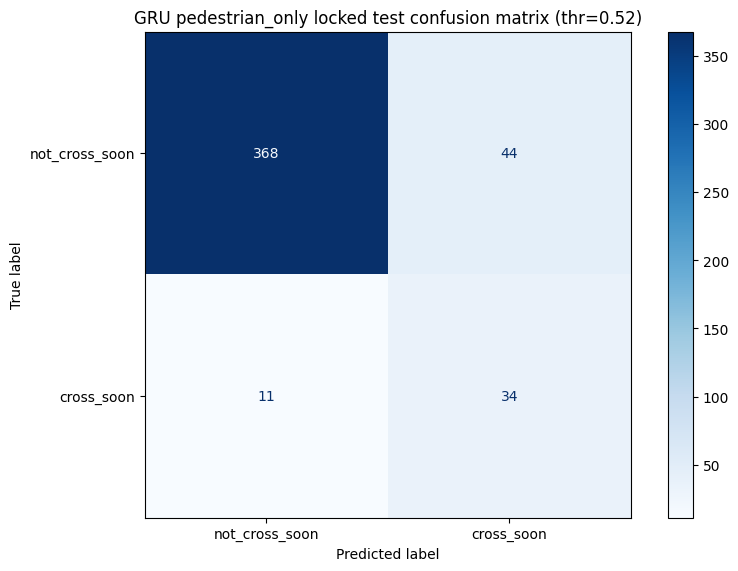


GRU interaction_aware locked test confusion matrix:


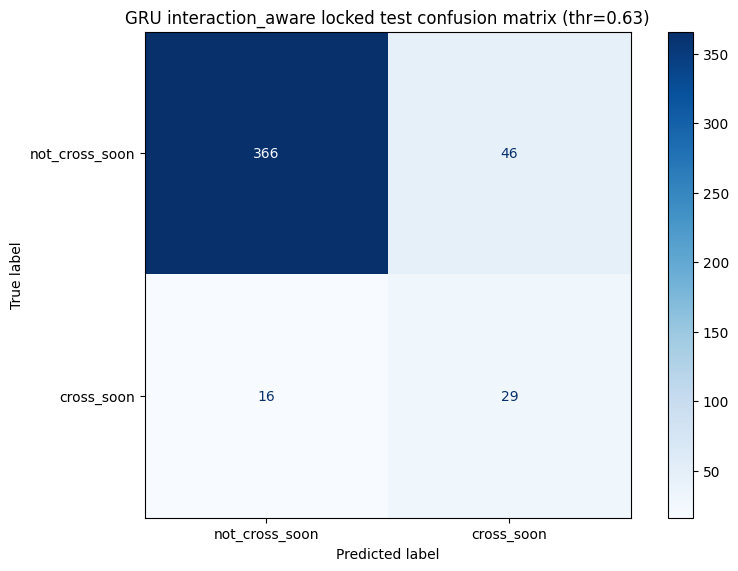

In [34]:
# Compare pedestrian-only and interaction-aware GRUs on the same locked
# interaction subset to test whether direct sequence modelling adds value.
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

SEQ_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 8
SEQ_BATCH_SIZE = 256
SEQ_MAX_EPOCHS = 25
SEQ_PATIENCE = 5
SEQ_HIDDEN_SIZE = 32
SEQ_LEARNING_RATE = 1e-3
SEQ_WEIGHT_DECAY = 1e-4

sequence_feature_sets = {
    "pedestrian_only": list(dict.fromkeys(pedestrian_feature_cols)),
    "interaction_aware": list(dict.fromkeys(all_feature_cols_interaction)),
}

print(f"GRU device: {SEQ_DEVICE}")
print(f"Sequence length: {SEQ_LEN}")

# Build fixed-length sequence examples for one feature view at a time.
def build_sequence_examples(df_part, feature_cols, seq_len=8, target_col="cross_soon"):
    ordered = df_part.sort_values(["ID", "Time"]).copy()

    sequences = []
    targets = []
    meta_rows = []

    for ped_id, track in ordered.groupby("ID"):
        X_track = track[feature_cols].to_numpy(dtype=np.float32)
        y_track = track[target_col].astype(int).to_numpy()
        times = track["Time"].to_numpy()

        if len(track) < seq_len:
            continue

        for end_idx in range(seq_len - 1, len(track)):
            sequences.append(X_track[end_idx - seq_len + 1:end_idx + 1])
            targets.append(y_track[end_idx])
            meta_rows.append({
                "ID": ped_id,
                "Time": times[end_idx],
                "y_true": int(y_track[end_idx])
            })

    X_seq = np.asarray(sequences, dtype=np.float32)
    y_seq = np.asarray(targets, dtype=np.int64)
    meta_df = pd.DataFrame(meta_rows)

    return X_seq, y_seq, meta_df

# Standardize each timestep channel using statistics from the training sequences only.
def standardize_sequence_sets(X_train, X_val, X_test):
    mean = X_train.mean(axis=(0, 1), keepdims=True)
    std = X_train.std(axis=(0, 1), keepdims=True)
    std = np.where(std == 0, 1.0, std)

    return (
        (X_train - mean) / std,
        (X_val - mean) / std,
        (X_test - mean) / std,
    )

# Small GRU classifier used for both sequence views.
class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=32):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        last_hidden = out[:, -1, :]
        logits = self.fc(last_hidden).squeeze(-1)
        return logits

# Train one GRU with early stopping on validation PR-AUC.
def fit_single_gru(X_train, y_train, X_val, y_val, input_size):
    model = GRUClassifier(input_size=input_size, hidden_size=SEQ_HIDDEN_SIZE).to(SEQ_DEVICE)

    pos_weight_value = (len(y_train) - y_train.sum()) / max(y_train.sum(), 1)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=SEQ_DEVICE))
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=SEQ_LEARNING_RATE,
        weight_decay=SEQ_WEIGHT_DECAY
    )

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train), torch.tensor(y_train.astype(np.float32))),
        batch_size=SEQ_BATCH_SIZE,
        shuffle=True,
    )

    best_state = None
    best_val_pr_auc = -np.inf
    patience_left = SEQ_PATIENCE

    for _ in range(SEQ_MAX_EPOCHS):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(SEQ_DEVICE)
            y_batch = y_batch.to(SEQ_DEVICE)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(torch.tensor(X_val, device=SEQ_DEVICE))
            val_probs = torch.sigmoid(val_logits).cpu().numpy()

        val_pr_auc = average_precision_score(y_val, val_probs)

        if val_pr_auc > best_val_pr_auc:
            best_val_pr_auc = val_pr_auc
            best_state = copy.deepcopy(model.state_dict())
            patience_left = SEQ_PATIENCE
        else:
            patience_left -= 1
            if patience_left == 0:
                break

    model.load_state_dict(best_state)
    return model

# Evaluate one fitted GRU view on validation and test.
def evaluate_gru_branch(name, feature_cols):
    X_train_seq, y_train_seq, meta_train_seq = build_sequence_examples(int_train, feature_cols, seq_len=SEQ_LEN, target_col=target_col)
    X_val_seq, y_val_seq, meta_val_seq = build_sequence_examples(int_val, feature_cols, seq_len=SEQ_LEN, target_col=target_col)
    X_test_seq, y_test_seq, meta_test_seq = build_sequence_examples(int_test, feature_cols, seq_len=SEQ_LEN, target_col=target_col)

    X_train_seq, X_val_seq, X_test_seq = standardize_sequence_sets(X_train_seq, X_val_seq, X_test_seq)

    model = fit_single_gru(
        X_train_seq, y_train_seq,
        X_val_seq, y_val_seq,
        input_size=X_train_seq.shape[-1]
    )

    with torch.no_grad():
        val_probs = torch.sigmoid(model(torch.tensor(X_val_seq, device=SEQ_DEVICE))).cpu().numpy()
        test_probs = torch.sigmoid(model(torch.tensor(X_test_seq, device=SEQ_DEVICE))).cpu().numpy()

    val_threshold_df = pd.DataFrame({
        "threshold": np.round(np.arange(0.05, 0.96, 0.01), 2)
    })
    val_threshold_df["precision"] = val_threshold_df["threshold"].apply(
        lambda thr: precision_score(y_val_seq, (val_probs >= thr).astype(int), zero_division=0)
    )
    val_threshold_df["recall"] = val_threshold_df["threshold"].apply(
        lambda thr: recall_score(y_val_seq, (val_probs >= thr).astype(int), zero_division=0)
    )
    val_threshold_df["f1"] = val_threshold_df["threshold"].apply(
        lambda thr: f1_score(y_val_seq, (val_probs >= thr).astype(int), zero_division=0)
    )
    val_threshold_df["f2"] = val_threshold_df.apply(
        lambda row: 0.0 if (row["precision"] == 0 and row["recall"] == 0) else (1 + 2**2) * (row["precision"] * row["recall"]) / ((2**2 * row["precision"]) + row["recall"]),
        axis=1
    )
    val_threshold_df["accuracy"] = val_threshold_df["threshold"].apply(
        lambda thr: accuracy_score(y_val_seq, (val_probs >= thr).astype(int))
    )

    best_row = choose_threshold_with_min_recall(val_threshold_df, min_recall=target_recall)
    best_thr = float(best_row["threshold"])

    val_pred = (val_probs >= 0.50).astype(int)
    test_pred = (test_probs >= best_thr).astype(int)

    val_series = pd.Series({
        "threshold": 0.50,
        "accuracy": accuracy_score(y_val_seq, val_pred),
        "precision": precision_score(y_val_seq, val_pred, zero_division=0),
        "recall": recall_score(y_val_seq, val_pred, zero_division=0),
        "f1": f1_score(y_val_seq, val_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val_seq, val_probs),
        "pr_auc": average_precision_score(y_val_seq, val_probs),
    }, name=f"gru_{name}_val")

    test_series = pd.Series({
        "threshold": best_thr,
        "accuracy": accuracy_score(y_test_seq, test_pred),
        "precision": precision_score(y_test_seq, test_pred, zero_division=0),
        "recall": recall_score(y_test_seq, test_pred, zero_division=0),
        "f1": f1_score(y_test_seq, test_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test_seq, test_probs),
        "pr_auc": average_precision_score(y_test_seq, test_probs),
    }, name=f"gru_{name}_test")

    return {
        "model": model,
        "feature_cols": feature_cols,
        "val_summary": val_series,
        "test_summary": test_series,
        "best_threshold": best_thr,
        "X_test_seq": X_test_seq,
        "y_test_seq": y_test_seq,
        "test_probs": test_probs,
        "test_pred": test_pred,
        "meta_test_seq": meta_test_seq,
        "sequence_counts": {
            "train_sequences": len(y_train_seq),
            "val_sequences": len(y_val_seq),
            "test_sequences": len(y_test_seq),
            "train_positive_rate": float(y_train_seq.mean()) if len(y_train_seq) else np.nan,
            "val_positive_rate": float(y_val_seq.mean()) if len(y_val_seq) else np.nan,
            "test_positive_rate": float(y_test_seq.mean()) if len(y_test_seq) else np.nan,
        }
    }

gru_results = {
    name: evaluate_gru_branch(name, feature_cols)
    for name, feature_cols in sequence_feature_sets.items()
}

print("GRU sequence-dataset summary:")
display(pd.DataFrame([
    {
        "sequence_view": name,
        "n_features_per_timestep": len(result["feature_cols"]),
        "sequence_length": SEQ_LEN,
        **result["sequence_counts"]
    }
    for name, result in gru_results.items()
]))

gru_val_summary = pd.DataFrame([
    gru_results["pedestrian_only"]["val_summary"],
    gru_results["interaction_aware"]["val_summary"],
])

gru_test_summary = pd.DataFrame([
    gru_results["pedestrian_only"]["test_summary"],
    gru_results["interaction_aware"]["test_summary"],
])

print("Validation results for the GRU branch:")
display(gru_val_summary)

print("Locked test results for the GRU branch:")
display(gru_test_summary)

for seq_name in ["pedestrian_only", "interaction_aware"]:
    res = gru_results[seq_name]
    print(f"\nGRU {seq_name} locked test confusion matrix:")
    fig, ax = plt.subplots(figsize=(8.6, 5.6), constrained_layout=True)
    ConfusionMatrixDisplay.from_predictions(
        res["y_test_seq"],
        res["test_pred"],
        display_labels=["not_cross_soon", "cross_soon"],
        cmap="Blues",
        colorbar=True,
        values_format="d",
        ax=ax
    )
    ax.set_title(f"GRU {seq_name} locked test confusion matrix (thr={res['best_threshold']:.2f})")
    plt.show()


### Interpreting the GRU results

The GRU branch is informative, but its results are less stable than those of the tabular models. On validation data at the default threshold of **0.50**, the interaction-aware GRU outperforms the pedestrian-only GRU, especially in **F1** and **PR-AUC**. This suggests that sequence modelling can extract useful signal from both recent pedestrian history and local interaction context.

However, this advantage does not carry over cleanly to the locked test set after recall-aware threshold selection. For the **pedestrian-only GRU**, threshold selection trades some recall for higher precision and a slightly improved **F1**. For the **interaction-aware GRU**, by contrast, the selected threshold transfers less well: recall drops substantially, while precision does not improve enough to compensate, resulting in a lower **F1** on test than on validation.

This pattern suggests that the GRU branch retains useful ranking ability, but that its operating point is less stable than in the tabular branches. That interpretation is consistent with the smaller and more imbalanced sequence dataset. The GRU therefore remains a meaningful sequence-model comparison, but it does not outperform the strongest **MLP** branch and should be interpreted more cautiously under locked threshold evaluation.

## Phase 2H: Cross-model synthesis at the main 3-second horizon

The next comparison places the strongest **locked-test** summaries from the three model families side by side:

- **logistic regression**
- **MLP**
- **GRU**

This makes the overall project picture easier to read at the main **3-second** horizon.


Locked-test cross-model summary at the main 3-second horizon:


,family,view,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
3,mlp,interaction_aware,0.32,0.875698,0.695000,0.832335,0.757493,0.949205,0.880693
2,mlp,pedestrian_only,0.36,0.860335,0.660287,0.826347,0.734043,0.931459,0.805570
1,logistic,interaction_aware,0.31,0.727654,0.455696,0.862275,0.596273,0.859745,0.668481
0,logistic,pedestrian_only,0.33,0.719274,0.442568,0.784431,0.565875,0.839763,0.632017
4,gru,pedestrian_only,0.52,0.879650,0.435897,0.755556,0.552846,0.922600,0.604940
5,gru,interaction_aware,0.63,0.864333,0.386667,0.644444,0.483333,0.895254,0.564854


['gru', 'gru', 'logistic', 'logistic', 'mlp', 'mlp']

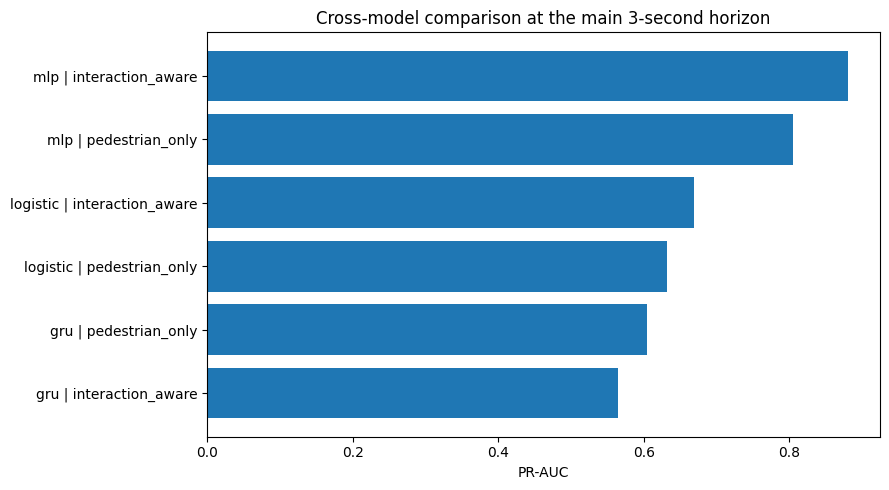

In [35]:
# Summarize the main locked-test results for the three model families so the
# strongest overall pattern at the 3-second horizon can be read in one place.
logistic_locked_summary = pd.DataFrame([
    {
        "family": "logistic",
        "view": "pedestrian_only",
        "threshold": thr_int_ped_recall,
        **recall_locked_test_results.loc[
            f"pedestrian_only_test_recall_target_{target_recall:.2f}",
            ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
        ].to_dict()
    },
    {
        "family": "logistic",
        "view": "interaction_aware",
        "threshold": thr_int_recall,
        **recall_locked_test_results.loc[
            f"interaction_aware_test_recall_target_{target_recall:.2f}",
            ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
        ].to_dict()
    },
])

mlp_locked_summary = pd.DataFrame([
    {
        "family": "mlp",
        "view": "pedestrian_only",
        "threshold": mlp_best_ped_thr,
        **mlp_test_results.loc[
            f"mlp_pedestrian_only_test_recall_target_{target_recall:.2f}",
            ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
        ].to_dict()
    },
    {
        "family": "mlp",
        "view": "interaction_aware",
        "threshold": mlp_best_int_thr,
        **mlp_test_results.loc[
            f"mlp_interaction_aware_test_recall_target_{target_recall:.2f}",
            ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
        ].to_dict()
    },
])

gru_locked_summary = pd.DataFrame([
    {
        "family": "gru",
        "view": "pedestrian_only",
        "threshold": gru_results["pedestrian_only"]["best_threshold"],
        **gru_results["pedestrian_only"]["test_summary"][["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].to_dict()
    },
    {
        "family": "gru",
        "view": "interaction_aware",
        "threshold": gru_results["interaction_aware"]["best_threshold"],
        **gru_results["interaction_aware"]["test_summary"][["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].to_dict()
    },
])

cross_model_summary = pd.concat(
    [logistic_locked_summary, mlp_locked_summary, gru_locked_summary],
    ignore_index=True
).sort_values(["pr_auc", "f1", "roc_auc"], ascending=False)

print("Locked-test cross-model summary at the main 3-second horizon:")
display(cross_model_summary, sorted(cross_model_summary["family"]))

plt.figure(figsize=(9, 5))
plot_df = cross_model_summary.copy()
plot_df["label"] = plot_df["family"] + " | " + plot_df["view"]
plt.barh(plot_df["label"], plot_df["pr_auc"])
plt.xlabel("PR-AUC")
plt.title("Cross-model comparison at the main 3-second horizon")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Interpreting the cross-model synthesis

This comparison is the main **model-family summary** at the 3-second horizon.

In the current outputs, the **interaction-aware MLP** is the strongest overall locked-test result, followed by the **pedestrian-only MLP**. The logistic interaction-aware model improves on the pedestrian-only logistic baseline, but both logistic views remain clearly below the MLPs. The GRU views are competitive on some ranking metrics, especially **ROC-AUC**, but they do not match the MLPs on **F1** or **PR-AUC**.

The strongest point-estimate result at the main horizon comes from the interaction-aware MLP. However, as the McNemar analysis in Phase 2J shows, the MLP-versus-logistic advantage is statistically confirmed, while the within-family pedestrian-only versus interaction-aware MLP difference is not.


## Phase 2I: Horizon sensitivity comparison (2 s, 3 s, and 5 s)

The pipeline keeps **2 s**, **3 s**, and **5 s** visible in a compact sensitivity section. This is not a full duplication of the entire pipeline. Instead, it compares a small set of quantities that matter most:

1. label balance and interaction coverage;
2. the locked **logistic** pedestrian-only versus interaction-aware comparison;
3. the **best** validation ablation stage at each horizon;
4. the locked **MLP** pedestrian-only versus interaction-aware comparison.

The purpose is methodological: to show explicitly that changing the future horizon changes the learning problem itself.


In [36]:
# Horizon-sensitivity functions for 2 s, 3 s, and 5 s
HORIZON_SENSITIVITY_SECS = [2, 3, 5]

# Small MLP factory reused both in the main 3-second branch and in the
# horizon-sensitivity comparison so the model specification stays identical.
def make_small_mlp(random_state=42):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(32, 16),
            activation="relu",
            alpha=1e-4,
            learning_rate_init=1e-3,
            batch_size=128,
            max_iter=300,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            random_state=random_state,
        ))
    ])

# Function to build horizon-specific tables and interaction features so the same data can be used for both the horizon-sensitivity comparison and the main 3-second modelling branch.
def build_horizon_specific_tables(horizon_sec):
    temp_ped = ped_feature_df.copy()

    temp_ped["cross_soon"] = False
    for track_id, track in temp_ped.groupby("ID"):
        temp_ped.loc[track.index, "cross_soon"] = compute_cross_soon_label(track, horizon_sec=horizon_sec)

    temp_ped["track_end_time"] = temp_ped.groupby("ID")["Time"].transform("max")
    temp_ped["enough_future"] = (
        (temp_ped["track_end_time"] - temp_ped["Time"]) >= pd.Timedelta(seconds=horizon_sec)
    )

    temp_model_df = temp_ped[
        temp_ped["eligible"] &
        temp_ped["enough_future"] &
        temp_ped["enough_past_2s"]
    ].copy()

    temp_model_df["scene_time"] = temp_model_df["Time"].dt.round("500ms")

    interaction_parts = []
    for scene_time, ped_group in temp_model_df.groupby("scene_time"):
        veh_group = veh_groups.get(scene_time)
        interaction_parts.append(build_interaction_features_for_scene(ped_group, veh_group))

    temp_interaction_df = pd.concat(interaction_parts).sort_index() if interaction_parts else pd.DataFrame(index=temp_model_df.index)
    temp_model_interaction_df = pd.concat([temp_model_df, temp_interaction_df], axis=1)

    temp_model_interaction_df["has_vehicle_context"] = (
        temp_model_interaction_df["nearest_vehicle_distance"].notna().astype(int)
    )
    temp_model_interaction_df["nearest_vehicle_is_heavy"] = np.where(
        temp_model_interaction_df["nearest_vehicle_type"].isna(),
        np.nan,
        (temp_model_interaction_df["nearest_vehicle_type"] == 3).astype(float)
    )
    temp_model_interaction_df["vehicle_ped_heading_diff"] = wrap_to_pi(
        temp_model_interaction_df["nearest_vehicle_heading_past_1s"] -
        temp_model_interaction_df["heading_past_1s"]
    )

    temp_interaction_model_df = temp_model_interaction_df[
        temp_model_interaction_df["has_vehicle_context"] == 1
    ].copy()

    return temp_model_df, temp_interaction_model_df

# Function to apply the same locked ID split to horizon-specific tables.
def split_horizon_tables_with_locked_ids(model_df_h, interaction_model_df_h):
    ped_train_h = model_df_h[model_df_h["ID"].isin(train_ids)].copy()
    ped_val_h   = model_df_h[model_df_h["ID"].isin(val_ids)].copy()
    ped_test_h  = model_df_h[model_df_h["ID"].isin(test_ids)].copy()

    int_train_h = interaction_model_df_h[interaction_model_df_h["ID"].isin(train_ids)].copy()
    int_val_h   = interaction_model_df_h[interaction_model_df_h["ID"].isin(val_ids)].copy()
    int_test_h  = interaction_model_df_h[interaction_model_df_h["ID"].isin(test_ids)].copy()

    return ped_train_h, ped_val_h, ped_test_h, int_train_h, int_val_h, int_test_h

# Function to summarize the horizon-specific tables so the later modelling results can be contextualized.
def summarize_horizon_data(horizon_sec, model_df_h, interaction_model_df_h):
    return {
        "horizon_sec": horizon_sec,
        "ped_rows": len(model_df_h),
        "ped_positive_rate": float(model_df_h[target_col].mean()) if len(model_df_h) else np.nan,
        "int_rows": len(interaction_model_df_h),
        "int_positive_rate": float(interaction_model_df_h[target_col].mean()) if len(interaction_model_df_h) else np.nan,
        "interaction_coverage": (len(interaction_model_df_h) / len(model_df_h)) if len(model_df_h) else np.nan,
    }

# Function to fit logistic models on the horizon-specific splits and return validation/test metrics at both the default threshold and a recall-constrained threshold.
def fit_logistic_pair_for_horizon(int_train_h, int_val_h, int_test_h, target_recall=0.85):
    X_train_base_h = int_train_h[pedestrian_feature_cols].copy()
    X_val_base_h   = int_val_h[pedestrian_feature_cols].copy()
    X_test_base_h  = int_test_h[pedestrian_feature_cols].copy()

    X_train_int_h = int_train_h[all_feature_cols_interaction].copy()
    X_val_int_h   = int_val_h[all_feature_cols_interaction].copy()
    X_test_int_h  = int_test_h[all_feature_cols_interaction].copy()

    y_train_h = int_train_h[target_col].astype(int)
    y_val_h   = int_val_h[target_col].astype(int)
    y_test_h  = int_test_h[target_col].astype(int)

    base_model_h = clone(int_model)
    int_model_h = clone(int_model)

    base_model_h.fit(X_train_base_h, y_train_h)
    int_model_h.fit(X_train_int_h, y_train_h)

    val_base = evaluate_binary_classifier(base_model_h, X_val_base_h, y_val_h, threshold=0.5, name="ped_val")
    val_int  = evaluate_binary_classifier(int_model_h, X_val_int_h, y_val_h, threshold=0.5, name="int_val")

    base_sweep = threshold_sweep(base_model_h, X_val_base_h, y_val_h, beta=2.0)
    int_sweep  = threshold_sweep(int_model_h, X_val_int_h, y_val_h, beta=2.0)

    base_row = choose_threshold_with_min_recall(base_sweep, min_recall=target_recall)
    int_row  = choose_threshold_with_min_recall(int_sweep, min_recall=target_recall)

    thr_base = float(base_row["threshold"])
    thr_int  = float(int_row["threshold"])

    test_base = evaluate_binary_classifier(base_model_h, X_test_base_h, y_test_h, threshold=thr_base, name="ped_test")
    test_int  = evaluate_binary_classifier(int_model_h, X_test_int_h, y_test_h, threshold=thr_int, name="int_test")

    return {"val_base": val_base, "val_int": val_int, "test_base": test_base, "test_int": test_int, "thr_base": thr_base, "thr_int": thr_int}

# Function to run a logistic ablation ladder for a given horizon-specific split and return a summary table and the name of the best-performing feature set.
def run_ablation_for_horizon(int_train_h, int_val_h):
    y_train_h = int_train_h[target_col].astype(int)
    y_val_h = int_val_h[target_col].astype(int)

    rows = []
    for name, cols in ablation_feature_sets.items():
        model_h = clone(int_model)
        model_h.fit(int_train_h[cols].copy(), y_train_h)
        val_row = evaluate_binary_classifier(model_h, int_val_h[cols].copy(), y_val_h, threshold=0.5, name=name)
        val_row["n_features"] = len(cols)
        rows.append(val_row)

    ab_df = pd.DataFrame(rows)
    ab_df["model_name"] = list(ablation_feature_sets.keys())
    ab_df = ab_df.set_index("model_name")
    best_name = ab_df.sort_values(["pr_auc", "f1", "roc_auc"], ascending=False).index[0]
    return ab_df, best_name

# Function to fit small MLP models on the horizon-specific splits and return validation/test metrics at both the default threshold and a recall-constrained threshold.
def fit_mlp_pair_for_horizon(int_train_h, int_val_h, int_test_h, target_recall=0.85):
    X_train_base_h = int_train_h[pedestrian_feature_cols].copy()
    X_val_base_h   = int_val_h[pedestrian_feature_cols].copy()
    X_test_base_h  = int_test_h[pedestrian_feature_cols].copy()

    X_train_int_h = int_train_h[all_feature_cols_interaction].copy()
    X_val_int_h   = int_val_h[all_feature_cols_interaction].copy()
    X_test_int_h  = int_test_h[all_feature_cols_interaction].copy()

    y_train_h = int_train_h[target_col].astype(int)
    y_val_h   = int_val_h[target_col].astype(int)
    y_test_h  = int_test_h[target_col].astype(int)

    sample_weight_h = compute_sample_weight(class_weight="balanced", y=y_train_h)

    mlp_base_h = make_small_mlp(random_state=RANDOM_STATE)
    mlp_int_h  = make_small_mlp(random_state=RANDOM_STATE)

    mlp_base_h.fit(X_train_base_h, y_train_h, clf__sample_weight=sample_weight_h)
    mlp_int_h.fit(X_train_int_h, y_train_h, clf__sample_weight=sample_weight_h)

    val_base = evaluate_binary_classifier(mlp_base_h, X_val_base_h, y_val_h, threshold=0.5, name="mlp_ped_val")
    val_int  = evaluate_binary_classifier(mlp_int_h, X_val_int_h, y_val_h, threshold=0.5, name="mlp_int_val")

    base_sweep = threshold_sweep(mlp_base_h, X_val_base_h, y_val_h, beta=2.0)
    int_sweep  = threshold_sweep(mlp_int_h, X_val_int_h, y_val_h, beta=2.0)

    base_row = choose_threshold_with_min_recall(base_sweep, min_recall=target_recall)
    int_row  = choose_threshold_with_min_recall(int_sweep, min_recall=target_recall)

    thr_base = float(base_row["threshold"])
    thr_int  = float(int_row["threshold"])

    test_base = evaluate_binary_classifier(mlp_base_h, X_test_base_h, y_test_h, threshold=thr_base, name="mlp_ped_test")
    test_int  = evaluate_binary_classifier(mlp_int_h, X_test_int_h, y_test_h, threshold=thr_int, name="mlp_int_test")

    return {"val_base": val_base, "val_int": val_int, "test_base": test_base, "test_int": test_int, "thr_base": thr_base, "thr_int": thr_int}


In [37]:
# Horizon sensitivity: compact summaries for 2 s, 3 s, and 5 s
horizon_data_rows = []
horizon_logistic_rows = []
horizon_ablation_rows = []
horizon_mlp_rows = []

for H_check in HORIZON_SENSITIVITY_SECS:
    model_df_h, interaction_model_df_h = build_horizon_specific_tables(H_check)
    ped_train_h, ped_val_h, ped_test_h, int_train_h, int_val_h, int_test_h = split_horizon_tables_with_locked_ids(
        model_df_h, interaction_model_df_h
    )

    horizon_data_rows.append(
        summarize_horizon_data(H_check, model_df_h, interaction_model_df_h)
    )

    log_res = fit_logistic_pair_for_horizon(int_train_h, int_val_h, int_test_h, target_recall=target_recall)
    horizon_logistic_rows.extend([
        {
            "horizon_sec": H_check,
            "stage": "validation",
            "model": "pedestrian_only",
            "threshold": 0.50,
            **log_res["val_base"][["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].to_dict()
        },
        {
            "horizon_sec": H_check,
            "stage": "validation",
            "model": "interaction_aware",
            "threshold": 0.50,
            **log_res["val_int"][["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].to_dict()
        },
        {
            "horizon_sec": H_check,
            "stage": "test_locked_recall_target",
            "model": "pedestrian_only",
            "threshold": log_res["thr_base"],
            **log_res["test_base"][["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].to_dict()
        },
        {
            "horizon_sec": H_check,
            "stage": "test_locked_recall_target",
            "model": "interaction_aware",
            "threshold": log_res["thr_int"],
            **log_res["test_int"][["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].to_dict()
        },
    ])

    ab_df_h, best_stage_h = run_ablation_for_horizon(int_train_h, int_val_h)
    top3 = ab_df_h.sort_values(["pr_auc", "f1", "roc_auc"], ascending=False).head(3)
    horizon_ablation_rows.append({
        "horizon_sec": H_check,
        "best_validation_stage": best_stage_h,
        "best_f1": float(top3.iloc[0]["f1"]),
        "best_pr_auc": float(top3.iloc[0]["pr_auc"]),
        "top3_validation_stages": ", ".join(top3.index.tolist())
    })

    mlp_res = fit_mlp_pair_for_horizon(int_train_h, int_val_h, int_test_h, target_recall=target_recall)
    horizon_mlp_rows.extend([
        {
            "horizon_sec": H_check,
            "stage": "validation",
            "model": "MLP_pedestrian_only",
            "threshold": 0.50,
            **mlp_res["val_base"][["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].to_dict()
        },
        {
            "horizon_sec": H_check,
            "stage": "validation",
            "model": "MLP_interaction_aware",
            "threshold": 0.50,
            **mlp_res["val_int"][["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].to_dict()
        },
        {
            "horizon_sec": H_check,
            "stage": "test_locked_recall_target",
            "model": "MLP_pedestrian_only",
            "threshold": mlp_res["thr_base"],
            **mlp_res["test_base"][["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].to_dict()
        },
        {
            "horizon_sec": H_check,
            "stage": "test_locked_recall_target",
            "model": "MLP_interaction_aware",
            "threshold": mlp_res["thr_int"],
            **mlp_res["test_int"][["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]].to_dict()
        },
    ])

horizon_data_df = pd.DataFrame(horizon_data_rows)
horizon_logistic_df = pd.DataFrame(horizon_logistic_rows)
horizon_ablation_df = pd.DataFrame(horizon_ablation_rows)
horizon_mlp_df = pd.DataFrame(horizon_mlp_rows)

print("Label balance and interaction coverage by horizon:")
display(horizon_data_df)

print("\nLocked logistic pedestrian-only versus interaction-aware comparison across horizons:")
display(horizon_logistic_df)

print("\nBest validation ablation stage by horizon:")
display(horizon_ablation_df)

print("\nLocked MLP pedestrian-only versus interaction-aware comparison across horizons:")
display(horizon_mlp_df)


Label balance and interaction coverage by horizon:


,horizon_sec,ped_rows,ped_positive_rate,int_rows,int_positive_rate,interaction_coverage
0,2,7979,0.234992,3869,0.224089,0.484898
1,3,7530,0.299602,3628,0.294653,0.481806
2,5,6852,0.339317,3226,0.340670,0.470811



Locked logistic pedestrian-only versus interaction-aware comparison across horizons:


,horizon_sec,stage,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,2,validation,pedestrian_only,0.50,0.641667,0.339623,0.692308,0.455696,0.727726,0.350555
1,2,validation,interaction_aware,0.50,0.662500,0.359223,0.711538,0.477419,0.738339,0.359733
2,2,test_locked_recall_target,pedestrian_only,0.33,0.771930,0.424812,0.875969,0.572152,0.867647,0.564104
3,2,test_locked_recall_target,interaction_aware,0.32,0.758435,0.409420,0.875969,0.558025,0.870814,0.591794
4,3,validation,pedestrian_only,0.50,0.736961,0.547619,0.696970,0.613333,0.750000,0.479709
5,3,validation,interaction_aware,0.50,0.748299,0.559322,0.750000,0.640777,0.768756,0.504711
6,3,test_locked_recall_target,pedestrian_only,0.33,0.719274,0.442568,0.784431,0.565875,0.839763,0.632017
7,3,test_locked_recall_target,interaction_aware,0.31,0.727654,0.455696,0.862275,0.596273,0.859745,0.668481
8,5,validation,pedestrian_only,0.50,0.746479,0.661765,0.671642,0.666667,0.763693,0.604417
9,5,validation,interaction_aware,0.50,0.738028,0.635762,0.716418,0.673684,0.774026,0.613995



Best validation ablation stage by horizon:


,horizon_sec,best_validation_stage,best_f1,best_pr_auc,top3_validation_stages
0,2,C_plus_vehicle_motion,0.472843,0.363425,"C_plus_vehicle_motion, D_plus_relative_geometr..."
1,3,D_plus_relative_geometry,0.628205,0.506862,"D_plus_relative_geometry, F_plus_local_density..."
2,5,F_plus_local_density_full,0.659649,0.615028,"F_plus_local_density_full, E_plus_vehicle_type..."



Locked MLP pedestrian-only versus interaction-aware comparison across horizons:


,horizon_sec,stage,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
0,2,validation,MLP_pedestrian_only,0.50,0.789583,0.508772,0.836538,0.632727,0.847842,0.649590
1,2,validation,MLP_interaction_aware,0.50,0.833333,0.580000,0.836538,0.685039,0.902286,0.728291
2,2,test_locked_recall_target,MLP_pedestrian_only,0.44,0.855601,0.557895,0.821705,0.664577,0.932766,0.745226
3,2,test_locked_recall_target,MLP_interaction_aware,0.46,0.906883,0.682927,0.868217,0.764505,0.959138,0.852300
4,3,validation,MLP_pedestrian_only,0.50,0.811791,0.652174,0.795455,0.716724,0.887639,0.794491
5,3,validation,MLP_interaction_aware,0.50,0.832200,0.681250,0.825758,0.746575,0.904163,0.769603
6,3,test_locked_recall_target,MLP_pedestrian_only,0.36,0.860335,0.660287,0.826347,0.734043,0.931459,0.805570
7,3,test_locked_recall_target,MLP_interaction_aware,0.32,0.875698,0.695000,0.832335,0.757493,0.949205,0.880693
8,5,validation,MLP_pedestrian_only,0.50,0.850704,0.775510,0.850746,0.811388,0.902512,0.856609
9,5,validation,MLP_interaction_aware,0.50,0.867606,0.804196,0.858209,0.830325,0.921152,0.841278


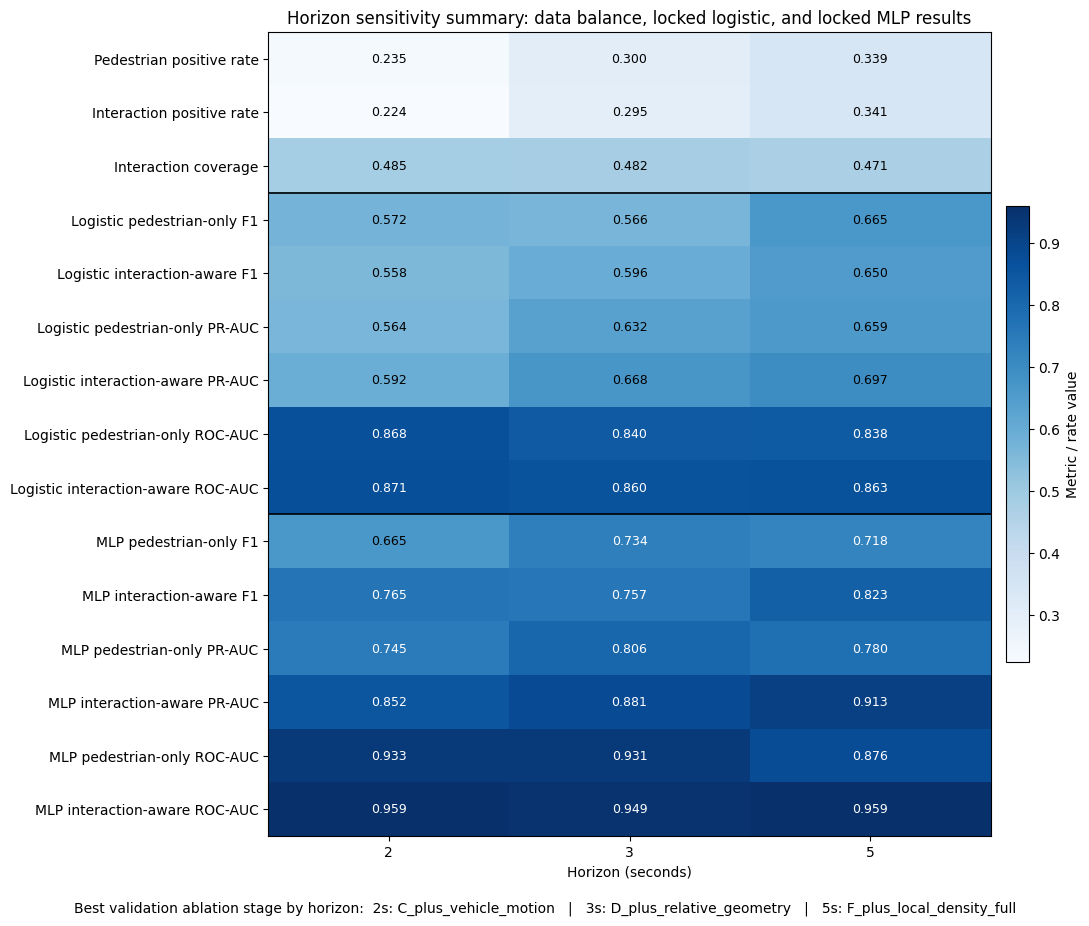

In [38]:
# One-figure summary of the full horizon sensitivity section
# This creates a single annotated heatmap that combines:
# 1) data balance / interaction coverage,
# 2) locked logistic results,
# 3) locked MLP results,
# 4) best ablation stage at each horizon.

# Helper to recover one value from the horizon-specific tables for the summary figure.
def get_metric_value(df, horizon_sec, stage, model, metric):
    row = df[
        (df["horizon_sec"] == horizon_sec) &
        (df["stage"] == stage) &
        (df["model"] == model)
    ]
    if len(row) != 1:
        raise ValueError(
            f"Expected exactly one row for horizon={horizon_sec}, stage={stage}, "
            f"model={model}, metric={metric}, but found {len(row)}."
        )
    return float(row.iloc[0][metric])

# Horizons in the final sensitivity comparison
horizons = sorted(horizon_data_df["horizon_sec"].unique())

# Build the combined summary table
summary_rows = []

# Data properties
for metric_name, label in [
    ("ped_positive_rate", "Pedestrian positive rate"),
    ("int_positive_rate", "Interaction positive rate"),
    ("interaction_coverage", "Interaction coverage")
]:
    row_vals = []
    for h in horizons:
        val = float(horizon_data_df.loc[horizon_data_df["horizon_sec"] == h, metric_name].iloc[0])
        row_vals.append(val)
    summary_rows.append([label] + row_vals)

# Locked logistic metrics
for metric, metric_label in [
    ("f1", "F1"),
    ("pr_auc", "PR-AUC"),
    ("roc_auc", "ROC-AUC")
]:
    summary_rows.append(
        [f"Logistic pedestrian-only {metric_label}"] +
        [get_metric_value(horizon_logistic_df, h, "test_locked_recall_target", "pedestrian_only", metric) for h in horizons]
    )
    summary_rows.append(
        [f"Logistic interaction-aware {metric_label}"] +
        [get_metric_value(horizon_logistic_df, h, "test_locked_recall_target", "interaction_aware", metric) for h in horizons]
    )

# Locked MLP metrics
for metric, metric_label in [
    ("f1", "F1"),
    ("pr_auc", "PR-AUC"),
    ("roc_auc", "ROC-AUC")
]:
    summary_rows.append(
        [f"MLP pedestrian-only {metric_label}"] +
        [get_metric_value(horizon_mlp_df, h, "test_locked_recall_target", "MLP_pedestrian_only", metric) for h in horizons]
    )
    summary_rows.append(
        [f"MLP interaction-aware {metric_label}"] +
        [get_metric_value(horizon_mlp_df, h, "test_locked_recall_target", "MLP_interaction_aware", metric) for h in horizons]
    )

summary_df = pd.DataFrame(summary_rows, columns=["row_label"] + horizons).set_index("row_label")

# Plot the single summary heatmap with annotations and separators between sections.
fig, ax = plt.subplots(figsize=(11, 9))

values = summary_df.to_numpy(dtype=float)
im = ax.imshow(values, aspect="auto", cmap="Blues")

# Axes labels
ax.set_xticks(np.arange(len(horizons)))
ax.set_xticklabels(horizons)
ax.set_xlabel("Horizon (seconds)")

ax.set_yticks(np.arange(len(summary_df.index)))
ax.set_yticklabels(summary_df.index)

ax.set_title("Horizon sensitivity summary: data balance, locked logistic, and locked MLP results")

# Annotate each cell with the actual value
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        val = values[i, j]
        text_color = "white" if val > 0.70 else "black"
        ax.text(j, i, f"{val:.3f}", ha="center", va="center", color=text_color, fontsize=9)

# Horizontal separators between blocks
# after data rows (3), after logistic rows (3 + 6 = 9)
for y in [2.5, 8.5]:
    ax.axhline(y, color="black", linewidth=1.2)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Metric / rate value")

# Add best ablation-stage notes under the x-axis
ablation_text_lines = []
for h in horizons:
    row = horizon_ablation_df[horizon_ablation_df["horizon_sec"] == h].iloc[0]
    ablation_text_lines.append(
        f"{h}s: {row['best_validation_stage']}"
    )

ablation_note = "Best validation ablation stage by horizon:  " + "   |   ".join(ablation_text_lines)

plt.figtext(
    0.5, -0.02,
    ablation_note,
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

### Interpretation of the horizon sensitivity comparison

This section is included because the horizon is treated as a **design choice with analytic consequences** rather than a fixed background setting.

In the current outputs, three patterns stand out:

1. the positive rate rises as the horizon increases from **2 s** to **5 s**, while interaction coverage falls only slightly;
2. the strongest logistic interaction story is not the same at every horizon — the best ablation stage shifts from **vehicle motion** at **2 s**, to **relative geometry** at **3 s**, to **local density** at **5 s**;
3. the interaction-aware MLP is stronger than the pedestrian-only MLP at **all three horizons**, and the gap is especially large at **5 s**.

Together, these results show that horizon choice changes not only class balance and difficulty, but also which interaction signals appear most useful.


## Phase 2J: Uncertainty and paired comparison checks

Point estimates are useful, but the main 3-second comparison is clearer when uncertainty is also shown. The next cell therefore adds:

- **bootstrap confidence intervals** for the main held-out test metrics;
- **paired McNemar tests** for within-family thresholded comparisons on the same examples.

Cross-family paired significance is only used when the models are evaluated on the same examples.


In [39]:
# Uncertainty intervals and paired diagnostic tests for locked-test models

# To better match the track-level train/validation/test split, the bootstrap below
# resamples pedestrian trajectory IDs with replacement. For each sampled ID, all
# held-out rows belonging to that trajectory are included in the bootstrap sample.

# McNemar tests are retained as paired row-level diagnostics for thresholded
# predictions on the same examples, but their p-values should be interpreted
# cautiously because they do not fully model within-track dependence.



# Metric helper
def metric_from_probs(y_true, y_prob, threshold, metric_name):
    """
    Compute one of the main thesis metrics from true labels, predicted
    probabilities, and a fixed decision threshold.

    F1 uses the locked threshold selected on the validation set.
    ROC-AUC and PR-AUC use the predicted probabilities directly.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)

    if metric_name == "f1":
        y_pred = (y_prob >= threshold).astype(int)
        return f1_score(y_true, y_pred, zero_division=0)

    elif metric_name == "roc_auc":
        # ROC-AUC is undefined if a bootstrap sample contains only one class.
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_prob)

    elif metric_name == "pr_auc":
        # PR-AUC is also undefined/uninformative if only one class is present.
        if len(np.unique(y_true)) < 2:
            return np.nan
        return average_precision_score(y_true, y_prob)

    else:
        raise ValueError(
            f"Unknown metric: {metric_name}. "
            "Supported metrics are: 'f1', 'roc_auc', and 'pr_auc'."
        )

# Track-cluster bootstrap
def cluster_bootstrap_metric_ci(
    y_true,
    y_prob,
    threshold,
    cluster_ids,
    metric_name,
    n_boot=1000,
    alpha=0.05,
    random_state=42,
):
    """
    Estimate a confidence interval using a trajectory-level cluster bootstrap.

    The resampling unit is the pedestrian trajectory ID, not the individual row.

    Parameters
    ----------
    y_true : array-like
        True binary labels for the locked test set.
    y_prob : array-like
        Predicted probabilities for the positive class.
    threshold : float
        Locked decision threshold selected on the validation set.
    cluster_ids : array-like
        Pedestrian trajectory IDs. These define the bootstrap clusters.
    metric_name : str
        Metric to compute. Supported: "f1", "roc_auc", "pr_auc".
    n_boot : int
        Number of bootstrap repetitions.
    alpha : float
        Significance level. alpha=0.05 gives a 95% confidence interval.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    dict
        Point estimate, bootstrap mean, confidence interval, and sample metadata.
    """
    rng_local = np.random.default_rng(random_state)

    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)
    cluster_ids = np.asarray(cluster_ids)

    if not (len(y_true) == len(y_prob) == len(cluster_ids)):
        raise ValueError(
            "y_true, y_prob, and cluster_ids must have the same length. "
            f"Got lengths: y_true={len(y_true)}, y_prob={len(y_prob)}, "
            f"cluster_ids={len(cluster_ids)}."
        )

    # Point estimate on the original locked test set.
    observed = metric_from_probs(
        y_true=y_true,
        y_prob=y_prob,
        threshold=threshold,
        metric_name=metric_name,
    )

    unique_clusters = np.unique(cluster_ids)

    # Map each trajectory ID to the row indices belonging to that trajectory.
    cluster_to_idx = {
        cluster: np.where(cluster_ids == cluster)[0]
        for cluster in unique_clusters
    }

    scores = []

    for _ in range(n_boot):
        # Resample trajectories, not individual rows.
        sampled_clusters = rng_local.choice(
            unique_clusters,
            size=len(unique_clusters),
            replace=True,
        )

        # Include all rows belonging to each sampled trajectory.
        sampled_idx = np.concatenate([
            cluster_to_idx[cluster]
            for cluster in sampled_clusters
        ])

        score = metric_from_probs(
            y_true=y_true[sampled_idx],
            y_prob=y_prob[sampled_idx],
            threshold=threshold,
            metric_name=metric_name,
        )

        # Skip bootstrap samples where ROC-AUC/PR-AUC is undefined.
        if not np.isnan(score):
            scores.append(score)

    scores = np.asarray(scores, dtype=float)

    if len(scores) == 0:
        boot_mean = np.nan
        ci_lower = np.nan
        ci_upper = np.nan
    else:
        boot_mean = float(scores.mean())
        ci_lower = float(np.quantile(scores, alpha / 2))
        ci_upper = float(np.quantile(scores, 1 - alpha / 2))

    return {
        "metric": metric_name,
        "estimate": float(observed),
        "boot_mean": boot_mean,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "n_boot_used": int(len(scores)),
        "n_clusters": int(len(unique_clusters)),
        "n_rows": int(len(y_true)),
    }


# Exact McNemar helper
# This helper is retained for later paired row-level diagnostics.
# It is not used for the bootstrap CI table below.
def exact_mcnemar_pvalue(y_true, pred_a, pred_b):
    """
    Exact McNemar test for paired thresholded predictions.

    Interpretation note:
    This is a row-level paired diagnostic. Because several rows may come from
    the same pedestrian trajectory, the p-values should be interpreted cautiously
    and not as fully cluster-independent significance tests.
    """
    y_true = np.asarray(y_true).astype(int)
    pred_a = np.asarray(pred_a).astype(int)
    pred_b = np.asarray(pred_b).astype(int)

    a_correct = pred_a == y_true
    b_correct = pred_b == y_true

    # b: model A correct, model B wrong
    # c: model A wrong, model B correct
    b = int(np.sum(a_correct & (~b_correct)))
    c = int(np.sum((~a_correct) & b_correct))

    n_discordant = b + c

    if n_discordant == 0:
        return {
            "b_only_correct": b,
            "c_only_correct": c,
            "p_value": 1.0,
            "n_discordant": n_discordant,
        }

    p_value = binomtest(
        min(b, c),
        n=n_discordant,
        p=0.5,
        alternative="two-sided",
    ).pvalue

    return {
        "b_only_correct": b,
        "c_only_correct": c,
        "p_value": float(p_value),
        "n_discordant": int(n_discordant),
    }


# Helper for extracting GRU test trajectory IDs
def extract_gru_test_cluster_ids(gru_branch_result, branch_name):
    """
    Extract trajectory IDs for GRU test sequences.

    This function expects the GRU result dictionary to contain test-sequence
    metadata with an ID column. If the metadata key differs in the notebook,
    add that key to candidate_meta_keys below.
    """
    candidate_meta_keys = [
        "meta_test_seq",
        "test_meta_seq",
        "meta_test",
        "test_meta",
        "seq_test_meta",
    ]

    for key in candidate_meta_keys:
        if key not in gru_branch_result:
            continue

        meta = gru_branch_result[key]

        if isinstance(meta, pd.DataFrame):
            if "ID" in meta.columns:
                return meta["ID"].to_numpy()

        if isinstance(meta, dict):
            if "ID" in meta:
                return np.asarray(meta["ID"])

    raise KeyError(
        f"Could not find GRU test trajectory IDs for branch '{branch_name}'. "
        "The GRU sequence-construction step should save test-sequence metadata "
        "with an 'ID' column, for example as gru_results[branch]['meta_test_seq']."
    )


# Cluster IDs for tabular test-set models
# These IDs must align row-for-row with the locked tabular test labels and
# feature matrices used below.
tabular_test_cluster_ids = int_test["ID"].to_numpy()

assert len(tabular_test_cluster_ids) == len(y_int_test), (
    "tabular_test_cluster_ids and y_int_test are not aligned."
)

assert len(tabular_test_cluster_ids) == len(y_mlp_test), (
    "tabular_test_cluster_ids and y_mlp_test are not aligned. "
    "If the MLP test set was built from a different dataframe, use that "
    "dataframe's ID column for the MLP cluster_ids."
)

assert np.array_equal(
    np.asarray(y_int_test).astype(int),
    np.asarray(y_mlp_test).astype(int),
), (
    "y_int_test and y_mlp_test are not identical. "
    "The tabular model comparisons assume the same held-out rows in the same order."
)

# Collect locked-test probabilities, thresholds, predictions, and clusters
logistic_ped_prob = int_ped_model.predict_proba(X_intped_test)[:, 1]
logistic_int_prob = int_model.predict_proba(X_int_test)[:, 1]

mlp_ped_prob = mlp_ped_model.predict_proba(X_mlp_test_base)[:, 1]
mlp_int_prob = mlp_int_model.predict_proba(X_mlp_test_int)[:, 1]

uncertainty_payload = {
    "logistic_pedestrian_only": {
        "y_true": y_int_test.to_numpy(),
        "y_prob": logistic_ped_prob,
        "threshold": thr_int_ped_recall,
        "y_pred": (logistic_ped_prob >= thr_int_ped_recall).astype(int),
        "cluster_ids": tabular_test_cluster_ids,
    },

    "logistic_interaction_aware": {
        "y_true": y_int_test.to_numpy(),
        "y_prob": logistic_int_prob,
        "threshold": thr_int_recall,
        "y_pred": (logistic_int_prob >= thr_int_recall).astype(int),
        "cluster_ids": tabular_test_cluster_ids,
    },

    "mlp_pedestrian_only": {
        "y_true": y_mlp_test.to_numpy(),
        "y_prob": mlp_ped_prob,
        "threshold": mlp_best_ped_thr,
        "y_pred": (mlp_ped_prob >= mlp_best_ped_thr).astype(int),
        "cluster_ids": tabular_test_cluster_ids,
    },

    "mlp_interaction_aware": {
        "y_true": y_mlp_test.to_numpy(),
        "y_prob": mlp_int_prob,
        "threshold": mlp_best_int_thr,
        "y_pred": (mlp_int_prob >= mlp_best_int_thr).astype(int),
        "cluster_ids": tabular_test_cluster_ids,
    },

    "gru_pedestrian_only": {
        "y_true": gru_results["pedestrian_only"]["y_test_seq"],
        "y_prob": gru_results["pedestrian_only"]["test_probs"],
        "threshold": gru_results["pedestrian_only"]["best_threshold"],
        "y_pred": gru_results["pedestrian_only"]["test_pred"],
        "cluster_ids": extract_gru_test_cluster_ids(
            gru_results["pedestrian_only"],
            branch_name="pedestrian_only",
        ),
    },

    "gru_interaction_aware": {
        "y_true": gru_results["interaction_aware"]["y_test_seq"],
        "y_prob": gru_results["interaction_aware"]["test_probs"],
        "threshold": gru_results["interaction_aware"]["best_threshold"],
        "y_pred": gru_results["interaction_aware"]["test_pred"],
        "cluster_ids": extract_gru_test_cluster_ids(
            gru_results["interaction_aware"],
            branch_name="interaction_aware",
        ),
    },
}

# Compute track-cluster bootstrap confidence intervals
ci_rows = []

metrics_for_ci = [
    "f1",
    "roc_auc",
    "pr_auc",
]

for model_name, payload in uncertainty_payload.items():
    for metric_name in metrics_for_ci:
        row = cluster_bootstrap_metric_ci(
            y_true=payload["y_true"],
            y_prob=payload["y_prob"],
            threshold=payload["threshold"],
            cluster_ids=payload["cluster_ids"],
            metric_name=metric_name,
            n_boot=1000,
            alpha=0.05,
            random_state=RANDOM_STATE,
        )

        row["model"] = model_name
        ci_rows.append(row)

uncertainty_ci_df = pd.DataFrame(ci_rows)[
    [
        "model",
        "metric",
        "estimate",
        "boot_mean",
        "ci_lower",
        "ci_upper",
        "n_boot_used",
        "n_clusters",
        "n_rows",
    ]
]

print("Track-cluster bootstrap confidence intervals on the locked test sets:")
print("Metrics included: F1, ROC-AUC, and PR-AUC.")
display(uncertainty_ci_df)

Track-cluster bootstrap confidence intervals on the locked test sets:
Metrics included: F1, ROC-AUC, and PR-AUC.


,model,metric,estimate,boot_mean,ci_lower,ci_upper,n_boot_used,n_clusters,n_rows
0,logistic_pedestrian_only,f1,0.565875,0.576638,0.406385,0.744816,1000,65,716
1,logistic_pedestrian_only,roc_auc,0.839763,0.813419,0.674287,0.903908,1000,65,716
2,logistic_pedestrian_only,pr_auc,0.632017,0.644360,0.456280,0.806357,1000,65,716
3,logistic_interaction_aware,f1,0.596273,0.607416,0.454618,0.761674,1000,65,716
4,logistic_interaction_aware,roc_auc,0.859745,0.834320,0.698111,0.920920,1000,65,716
5,logistic_interaction_aware,pr_auc,0.668481,0.676642,0.489699,0.827276,1000,65,716
6,mlp_pedestrian_only,f1,0.734043,0.734741,0.614072,0.845530,1000,65,716
7,mlp_pedestrian_only,roc_auc,0.931459,0.915262,0.825519,0.961334,1000,65,716
8,mlp_pedestrian_only,pr_auc,0.805570,0.808469,0.665558,0.922972,1000,65,716
9,mlp_interaction_aware,f1,0.757493,0.764311,0.571413,0.908016,1000,65,716


Using track-cluster bootstrap CI table from: uncertainty_ci_df


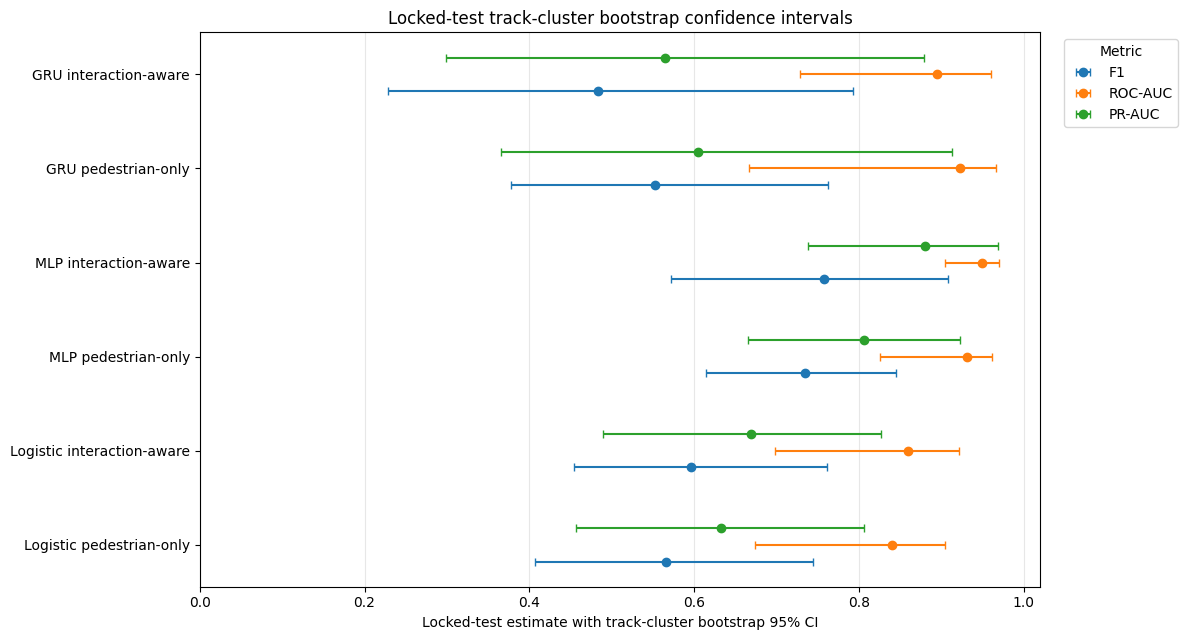

In [40]:
# Combined track-cluster bootstrap confidence-interval plot
# for the main locked-test metrics

# This plot uses the track-cluster bootstrap table produced in the previous cell.

def pick_cluster_bootstrap_table(name_candidates):
    """
    Pick the first available dataframe that matches the expected
    track-cluster bootstrap CI output.

    The table must contain 'estimate' and 'n_clusters'. This prevents the
    notebook from accidentally using an older row-level bootstrap table.
    """
    for name in name_candidates:
        if name not in globals():
            continue

        candidate = globals()[name]

        if not isinstance(candidate, pd.DataFrame):
            continue

        required_cols = {
            "model",
            "metric",
            "estimate",
            "ci_lower",
            "ci_upper",
            "n_clusters",
        }

        if required_cols.issubset(candidate.columns):
            return candidate.copy(), name

    raise NameError(
        "No valid track-cluster bootstrap CI table was found. "
        "Run the track-cluster bootstrap uncertainty cell first. "
        "The expected table must contain: 'model', 'metric', 'estimate', "
        "'ci_lower', 'ci_upper', and 'n_clusters'."
    )


bootstrap_ci_df, bootstrap_ci_name = pick_cluster_bootstrap_table([
    "uncertainty_ci_df",
    "cluster_bootstrap_ci_df",
    "bootstrap_ci_df",
    "bootstrap_ci_results",
    "bootstrap_results_df",
    "ci_results_df",
    "ci_df",
])

print("Using track-cluster bootstrap CI table from:", bootstrap_ci_name)


# Plot settings
plot_metrics = [
    "f1",
    "roc_auc",
    "pr_auc",
]

model_order = [
    "logistic_pedestrian_only",
    "logistic_interaction_aware",
    "mlp_pedestrian_only",
    "mlp_interaction_aware",
    "gru_pedestrian_only",
    "gru_interaction_aware",
]

pretty_model_names = {
    "logistic_pedestrian_only": "Logistic pedestrian-only",
    "logistic_interaction_aware": "Logistic interaction-aware",
    "mlp_pedestrian_only": "MLP pedestrian-only",
    "mlp_interaction_aware": "MLP interaction-aware",
    "gru_pedestrian_only": "GRU pedestrian-only",
    "gru_interaction_aware": "GRU interaction-aware",
}

metric_labels = {
    "f1": "F1",
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
}

# Prepare plotting dataframe
plot_df = bootstrap_ci_df[
    bootstrap_ci_df["metric"].isin(plot_metrics)
    & bootstrap_ci_df["model"].isin(model_order)
].copy()

plot_df["model"] = pd.Categorical(
    plot_df["model"],
    categories=model_order,
    ordered=True,
)

plot_df = plot_df.sort_values(["model", "metric"]).copy()

# Use the locked-test estimate as the plotted point.
plot_df["err_left"] = plot_df["estimate"] - plot_df["ci_lower"]
plot_df["err_right"] = plot_df["ci_upper"] - plot_df["estimate"]

# Avoid tiny negative values caused by numerical rounding.
plot_df["err_left"] = plot_df["err_left"].clip(lower=0)
plot_df["err_right"] = plot_df["err_right"].clip(lower=0)

model_to_y = {
    model_name: i
    for i, model_name in enumerate(model_order)
}

base_y = np.arange(len(model_order))

# Small vertical offsets so the three metrics do not overlap for each model.
offsets = np.linspace(-0.18, 0.18, len(plot_metrics))


# Plot
plt.figure(figsize=(12, 6.5))

for i, metric in enumerate(plot_metrics):
    metric_df = plot_df[plot_df["metric"] == metric].copy()

    if metric_df.empty:
        print(f"Skipping metric '{metric}' because it is not present in the CI table.")
        continue

    metric_df["y_pos"] = metric_df["model"].map(model_to_y).astype(float) + offsets[i]

    metric_df = metric_df.dropna(
        subset=[
            "estimate",
            "ci_lower",
            "ci_upper",
            "err_left",
            "err_right",
            "y_pos",
        ]
    )

    if metric_df.empty:
        continue

    plt.errorbar(
        metric_df["estimate"],
        metric_df["y_pos"],
        xerr=[
            metric_df["err_left"],
            metric_df["err_right"],
        ],
        fmt="o",
        capsize=3,
        label=metric_labels[metric],
    )

plt.yticks(
    base_y,
    [pretty_model_names[m] for m in model_order],
)

plt.xlabel("Locked-test estimate with track-cluster bootstrap 95% CI")
plt.title("Locked-test track-cluster bootstrap confidence intervals")
plt.xlim(0, 1.02)
plt.grid(axis="x", alpha=0.3)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [41]:
# Paired tabular-model comparison diagnostics

# Object recovery helpers
def pick_first_existing(name_candidates):
    """
    Return the first object found in globals() from a list of candidate names.
    """
    for name in name_candidates:
        if name in globals():
            return globals()[name], name

    raise NameError(f"None of these objects were found: {name_candidates}")


def get_existing_threshold(name_candidates):
    """
    Return the first threshold found in globals() from a list of candidate names.
    """
    for name in name_candidates:
        if name in globals():
            return float(globals()[name]), name

    return None, None

# Recover main tabular models
log_ped_model, log_ped_model_name = pick_first_existing([
    "int_ped_model",
    "pedestrian_only_logistic_model",
    "baseline_model",
    "logistic_pedestrian_only_model",
])

log_int_model, log_int_model_name = pick_first_existing([
    "int_model",
    "interaction_aware_logistic_model",
    "logistic_interaction_aware_model",
])

mlp_ped_model_for_test, mlp_ped_model_name = pick_first_existing([
    "mlp_ped_model",
    "mlp_base_model",
    "pedestrian_only_mlp_model",
    "best_mlp_base_model",
])

mlp_int_model_for_test, mlp_int_model_name = pick_first_existing([
    "mlp_int_model",
    "interaction_aware_mlp_model",
    "mlp_interaction_model",
    "best_mlp_int_model",
])


# Recover correct locked-test matrices and labels

# Important:
# The logistic and MLP branches may use differently named test matrices.
# Prefer the MLP-specific matrices for MLP predictions when available.
X_log_ped_test, X_log_ped_test_name = pick_first_existing([
    "X_intped_test",
    "X_log_ped_test",
    "X_test_base",
    "X_base_test",
])

X_log_int_test, X_log_int_test_name = pick_first_existing([
    "X_int_test",
    "X_log_int_test",
    "X_test_int",
    "X_interaction_test",
])

X_mlp_ped_test, X_mlp_ped_test_name = pick_first_existing([
    "X_mlp_test_base",
    "X_mlp_ped_test",
    "X_intped_test",
    "X_test_base",
    "X_base_test",
])

X_mlp_int_test, X_mlp_int_test_name = pick_first_existing([
    "X_mlp_test_int",
    "X_mlp_int_test",
    "X_int_test",
    "X_test_int",
    "X_interaction_test",
])

y_log_test, y_log_test_name = pick_first_existing([
    "y_int_test",
    "y_log_test",
    "y_test",
    "y_interaction_test",
])

y_mlp_test_for_check, y_mlp_test_name = pick_first_existing([
    "y_mlp_test",
    "y_int_test",
    "y_test",
    "y_interaction_test",
])

y_true = np.asarray(y_log_test).astype(int)
y_mlp_true = np.asarray(y_mlp_test_for_check).astype(int)

if len(y_true) != len(y_mlp_true):
    raise ValueError(
        "The logistic and MLP test-label arrays have different lengths. "
        "Pairwise comparisons require the same held-out rows."
    )

if not np.array_equal(y_true, y_mlp_true):
    raise ValueError(
        "The logistic and MLP test-label arrays are not identical. "
        "Pairwise comparisons require the same held-out rows in the same order."
    )


# Recover locked decision thresholds
log_thr_ped, log_thr_ped_name = pick_first_existing([
    "thr_int_ped_recall",
    "thr_base",
    "logistic_thr_base",
    "log_thr_ped",
])

log_thr_int, log_thr_int_name = pick_first_existing([
    "thr_int_recall",
    "thr_int",
    "logistic_thr_int",
    "log_thr_int",
])

mlp_thr_ped, mlp_thr_ped_name = get_existing_threshold([
    "mlp_best_ped_thr",
    "mlp_thr_base",
    "thr_mlp_base",
    "best_mlp_thr_base",
    "mlp_ped_threshold",
])

mlp_thr_int, mlp_thr_int_name = get_existing_threshold([
    "mlp_best_int_thr",
    "mlp_thr_int",
    "thr_mlp_int",
    "best_mlp_int_thr",
    "mlp_int_threshold",
])


# Recompute MLP thresholds from validation data if needed
if mlp_thr_ped is None or mlp_thr_int is None:
    print("Standalone MLP threshold variables were not found.")
    print("Recomputing MLP thresholds from validation data...")

    X_mlp_ped_val, X_mlp_ped_val_name = pick_first_existing([
        "X_mlp_val_base",
        "X_mlp_ped_val",
        "X_intped_val",
        "X_val_base",
        "X_base_val",
    ])

    X_mlp_int_val, X_mlp_int_val_name = pick_first_existing([
        "X_mlp_val_int",
        "X_mlp_int_val",
        "X_int_val",
        "X_val_int",
        "X_interaction_val",
    ])

    y_mlp_val, y_mlp_val_name = pick_first_existing([
        "y_mlp_val",
        "y_int_val",
        "y_val",
        "y_interaction_val",
    ])

    target_recall_local, target_recall_name = get_existing_threshold([
        "target_recall",
    ])

    if target_recall_local is None:
        target_recall_local = 0.85
        target_recall_name = "default_0.85"

    mlp_ped_sweep = threshold_sweep(
        mlp_ped_model_for_test,
        X_mlp_ped_val,
        y_mlp_val,
        beta=2.0,
    )

    mlp_int_sweep = threshold_sweep(
        mlp_int_model_for_test,
        X_mlp_int_val,
        y_mlp_val,
        beta=2.0,
    )

    mlp_ped_row = choose_threshold_with_min_recall(
        mlp_ped_sweep,
        min_recall=target_recall_local,
    )

    mlp_int_row = choose_threshold_with_min_recall(
        mlp_int_sweep,
        min_recall=target_recall_local,
    )

    mlp_thr_ped = float(mlp_ped_row["threshold"])
    mlp_thr_int = float(mlp_int_row["threshold"])

    mlp_thr_ped_name = f"recomputed_from_validation_using_{target_recall_name}"
    mlp_thr_int_name = f"recomputed_from_validation_using_{target_recall_name}"


# Recover track IDs for cluster-aware paired bootstrap
if "tabular_test_cluster_ids" in globals():
    tabular_cluster_ids = np.asarray(tabular_test_cluster_ids)
    tabular_cluster_ids_name = "tabular_test_cluster_ids"
elif "int_test" in globals() and isinstance(int_test, pd.DataFrame) and "ID" in int_test.columns:
    tabular_cluster_ids = int_test["ID"].to_numpy()
    tabular_cluster_ids_name = "int_test['ID']"
else:
    raise NameError(
        "Could not recover tabular test cluster IDs. Expected either "
        "'tabular_test_cluster_ids' or a dataframe 'int_test' with an 'ID' column."
    )

if len(tabular_cluster_ids) != len(y_true):
    raise ValueError(
        "tabular_cluster_ids and y_true are not aligned. "
        f"Got lengths: cluster_ids={len(tabular_cluster_ids)}, y_true={len(y_true)}."
    )

# Print recovered objects for auditability
print("Recovered objects:")
print("  logistic pedestrian-only model:", log_ped_model_name)
print("  logistic interaction-aware model:", log_int_model_name)
print("  MLP pedestrian-only model:", mlp_ped_model_name)
print("  MLP interaction-aware model:", mlp_int_model_name)

print("  logistic pedestrian-only test matrix:", X_log_ped_test_name)
print("  logistic interaction-aware test matrix:", X_log_int_test_name)
print("  MLP pedestrian-only test matrix:", X_mlp_ped_test_name)
print("  MLP interaction-aware test matrix:", X_mlp_int_test_name)

print("  logistic test labels:", y_log_test_name)
print("  MLP test labels:", y_mlp_test_name)
print("  cluster IDs:", tabular_cluster_ids_name)

print("  logistic thresholds:", log_thr_ped_name, "/", log_thr_int_name)
print("  MLP thresholds:", mlp_thr_ped_name, "/", mlp_thr_int_name)
print("  MLP threshold values:", mlp_thr_ped, "/", mlp_thr_int)


# Compute locked probabilities and thresholded predictions
tabular_probabilities = {
    "logistic_pedestrian_only": log_ped_model.predict_proba(X_log_ped_test)[:, 1],
    "logistic_interaction_aware": log_int_model.predict_proba(X_log_int_test)[:, 1],
    "mlp_pedestrian_only": mlp_ped_model_for_test.predict_proba(X_mlp_ped_test)[:, 1],
    "mlp_interaction_aware": mlp_int_model_for_test.predict_proba(X_mlp_int_test)[:, 1],
}

tabular_thresholds = {
    "logistic_pedestrian_only": float(log_thr_ped),
    "logistic_interaction_aware": float(log_thr_int),
    "mlp_pedestrian_only": float(mlp_thr_ped),
    "mlp_interaction_aware": float(mlp_thr_int),
}

tabular_predictions = {
    model_name: (prob >= tabular_thresholds[model_name]).astype(int)
    for model_name, prob in tabular_probabilities.items()
}

for model_name, pred in tabular_predictions.items():
    if len(pred) != len(y_true):
        raise ValueError(
            f"Predictions for {model_name} are not aligned with y_true. "
            f"Got len(pred)={len(pred)}, len(y_true)={len(y_true)}."
        )

# Exact McNemar row-level diagnostic
def exact_mcnemar_row_diagnostic(y_true, pred_a, pred_b):
    """
    Exact McNemar diagnostic for two paired thresholded prediction vectors.

    The p-value is based on discordant row-level cases:
      - a_only_correct: model A correct and model B wrong
      - b_only_correct: model B correct and model A wrong

    Because rows are clustered within pedestrian trajectories, this is treated
    as a row-level diagnostic rather than a fully independent significance test.
    """
    y_true = np.asarray(y_true).astype(int)
    pred_a = np.asarray(pred_a).astype(int)
    pred_b = np.asarray(pred_b).astype(int)

    a_correct = pred_a == y_true
    b_correct = pred_b == y_true

    a_only_correct = int(np.sum(a_correct & ~b_correct))
    b_only_correct = int(np.sum(b_correct & ~a_correct))

    n_discordant = a_only_correct + b_only_correct

    if n_discordant == 0:
        p_value = 1.0
    else:
        p_value = binomtest(
            min(a_only_correct, b_only_correct),
            n=n_discordant,
            p=0.5,
            alternative="two-sided",
        ).pvalue

    if a_only_correct > b_only_correct:
        direction = "model_a_more_often_correct"
    elif b_only_correct > a_only_correct:
        direction = "model_b_more_often_correct"
    else:
        direction = "tie_on_discordant_rows"

    return {
        "a_only_correct": a_only_correct,
        "b_only_correct": b_only_correct,
        "n_discordant": int(n_discordant),
        "raw_p_value": float(p_value),
        "row_level_direction": direction,
    }


pairs = list(combinations(tabular_predictions.keys(), 2))

mcnemar_rows = []

for model_a, model_b in pairs:
    result = exact_mcnemar_row_diagnostic(
        y_true=y_true,
        pred_a=tabular_predictions[model_a],
        pred_b=tabular_predictions[model_b],
    )

    mcnemar_rows.append({
        "model_a": model_a,
        "model_b": model_b,
        **result,
        "n_rows": int(len(y_true)),
        "n_clusters": int(len(np.unique(tabular_cluster_ids))),
        "interpretation_scope": "paired row-level diagnostic",
    })

mcnemar_tabular_df = pd.DataFrame(mcnemar_rows)

reject, p_holm, _, _ = multipletests(
    mcnemar_tabular_df["raw_p_value"].values,
    alpha=0.05,
    method="holm",
)

mcnemar_tabular_df["holm_corrected_p_value"] = p_holm
mcnemar_tabular_df["significant_after_holm"] = reject

mcnemar_tabular_df = mcnemar_tabular_df.sort_values(
    ["holm_corrected_p_value", "raw_p_value"]
).reset_index(drop=True)

print("Exact McNemar row-level diagnostics for valid tabular-model comparisons:")
display(mcnemar_tabular_df)

# Track-cluster paired metric differences
def metric_from_prob_and_threshold(y_true, y_prob, threshold, metric_name):
    """
    Compute one of the main thesis metrics from labels, probabilities,
    and a fixed threshold.

    F1 uses the locked threshold.
    ROC-AUC and PR-AUC use predicted probabilities directly.
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob, dtype=float)

    if metric_name == "f1":
        y_pred = (y_prob >= threshold).astype(int)
        return f1_score(y_true, y_pred, zero_division=0)

    elif metric_name == "roc_auc":
        if len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, y_prob)

    elif metric_name == "pr_auc":
        if len(np.unique(y_true)) < 2:
            return np.nan
        return average_precision_score(y_true, y_prob)

    else:
        raise ValueError(
            f"Unknown metric: {metric_name}. "
            "Supported metrics are: 'f1', 'roc_auc', and 'pr_auc'."
        )


def cluster_bootstrap_paired_metric_difference(
    y_true,
    prob_a,
    prob_b,
    threshold_a,
    threshold_b,
    cluster_ids,
    metric_name,
    n_boot=1000,
    alpha=0.05,
    random_state=42,
):
    """
    Track-cluster bootstrap for paired metric differences.

    Difference is defined as:

        metric(model_b) - metric(model_a)

    A positive value therefore means that model_b performs better on that metric.
    """
    rng_local = np.random.default_rng(random_state)

    y_true = np.asarray(y_true).astype(int)
    prob_a = np.asarray(prob_a, dtype=float)
    prob_b = np.asarray(prob_b, dtype=float)
    cluster_ids = np.asarray(cluster_ids)

    if not (len(y_true) == len(prob_a) == len(prob_b) == len(cluster_ids)):
        raise ValueError(
            "y_true, prob_a, prob_b, and cluster_ids must have the same length."
        )

    observed_a = metric_from_prob_and_threshold(
        y_true=y_true,
        y_prob=prob_a,
        threshold=threshold_a,
        metric_name=metric_name,
    )

    observed_b = metric_from_prob_and_threshold(
        y_true=y_true,
        y_prob=prob_b,
        threshold=threshold_b,
        metric_name=metric_name,
    )

    observed_diff = observed_b - observed_a

    unique_clusters = np.unique(cluster_ids)

    cluster_to_idx = {
        cluster: np.where(cluster_ids == cluster)[0]
        for cluster in unique_clusters
    }

    diffs = []

    for _ in range(n_boot):
        sampled_clusters = rng_local.choice(
            unique_clusters,
            size=len(unique_clusters),
            replace=True,
        )

        sampled_idx = np.concatenate([
            cluster_to_idx[cluster]
            for cluster in sampled_clusters
        ])

        metric_a = metric_from_prob_and_threshold(
            y_true=y_true[sampled_idx],
            y_prob=prob_a[sampled_idx],
            threshold=threshold_a,
            metric_name=metric_name,
        )

        metric_b = metric_from_prob_and_threshold(
            y_true=y_true[sampled_idx],
            y_prob=prob_b[sampled_idx],
            threshold=threshold_b,
            metric_name=metric_name,
        )

        if not (np.isnan(metric_a) or np.isnan(metric_b)):
            diffs.append(metric_b - metric_a)

    diffs = np.asarray(diffs, dtype=float)

    if len(diffs) == 0:
        ci_lower = np.nan
        ci_upper = np.nan
        boot_mean_diff = np.nan
        p_two_sided = np.nan
    else:
        ci_lower = float(np.quantile(diffs, alpha / 2))
        ci_upper = float(np.quantile(diffs, 1 - alpha / 2))
        boot_mean_diff = float(diffs.mean())

        # Bootstrap sign-based two-sided p-value approximation.
        # This is descriptive, not a formal replacement for a full clustered
        # paired modelling framework.
        prop_le_zero = np.mean(diffs <= 0)
        prop_ge_zero = np.mean(diffs >= 0)
        p_two_sided = float(2 * min(prop_le_zero, prop_ge_zero))
        p_two_sided = min(p_two_sided, 1.0)

    return {
        "metric": metric_name,
        "model_a_estimate": float(observed_a),
        "model_b_estimate": float(observed_b),
        "observed_difference_b_minus_a": float(observed_diff),
        "boot_mean_difference": boot_mean_diff,
        "ci_lower": ci_lower,
        "ci_upper": ci_upper,
        "bootstrap_sign_p_approx": p_two_sided,
        "n_boot_used": int(len(diffs)),
        "n_clusters": int(len(unique_clusters)),
        "n_rows": int(len(y_true)),
    }


paired_diff_metrics = [
    "f1",
    "roc_auc",
    "pr_auc",
]

paired_diff_rows = []

for model_a, model_b in pairs:
    for metric_name in paired_diff_metrics:
        row = cluster_bootstrap_paired_metric_difference(
            y_true=y_true,
            prob_a=tabular_probabilities[model_a],
            prob_b=tabular_probabilities[model_b],
            threshold_a=tabular_thresholds[model_a],
            threshold_b=tabular_thresholds[model_b],
            cluster_ids=tabular_cluster_ids,
            metric_name=metric_name,
            n_boot=1000,
            alpha=0.05,
            random_state=RANDOM_STATE,
        )

        row["model_a"] = model_a
        row["model_b"] = model_b
        paired_diff_rows.append(row)

paired_cluster_bootstrap_tabular_df = pd.DataFrame(paired_diff_rows)[
    [
        "model_a",
        "model_b",
        "metric",
        "model_a_estimate",
        "model_b_estimate",
        "observed_difference_b_minus_a",
        "boot_mean_difference",
        "ci_lower",
        "ci_upper",
        "bootstrap_sign_p_approx",
        "n_boot_used",
        "n_clusters",
        "n_rows",
    ]
]

paired_cluster_bootstrap_tabular_df = paired_cluster_bootstrap_tabular_df.sort_values(
    ["model_a", "model_b", "metric"]
).reset_index(drop=True)

print("Track-cluster paired bootstrap differences for valid tabular-model comparisons:")
print("Difference is defined as model_b minus model_a.")
print("Metrics included: F1, ROC-AUC, and PR-AUC.")
display(paired_cluster_bootstrap_tabular_df)

Recovered objects:
  logistic pedestrian-only model: int_ped_model
  logistic interaction-aware model: int_model
  MLP pedestrian-only model: mlp_ped_model
  MLP interaction-aware model: mlp_int_model
  logistic pedestrian-only test matrix: X_intped_test
  logistic interaction-aware test matrix: X_int_test
  MLP pedestrian-only test matrix: X_mlp_test_base
  MLP interaction-aware test matrix: X_mlp_test_int
  logistic test labels: y_int_test
  MLP test labels: y_mlp_test
  cluster IDs: tabular_test_cluster_ids
  logistic thresholds: thr_int_ped_recall / thr_int_recall
  MLP thresholds: mlp_best_ped_thr / mlp_best_int_thr
  MLP threshold values: 0.36000000000000004 / 0.32000000000000006
Exact McNemar row-level diagnostics for valid tabular-model comparisons:


,model_a,model_b,a_only_correct,b_only_correct,n_discordant,raw_p_value,row_level_direction,n_rows,n_clusters,interpretation_scope,holm_corrected_p_value,significant_after_holm
0,logistic_pedestrian_only,mlp_interaction_aware,25,137,162,6.592736e-20,model_b_more_often_correct,716,65,paired row-level diagnostic,3.955641e-19,True
1,logistic_pedestrian_only,mlp_pedestrian_only,25,126,151,2.039779e-17,model_b_more_often_correct,716,65,paired row-level diagnostic,1.019890e-16,True
2,logistic_interaction_aware,mlp_interaction_aware,32,138,170,6.898772e-17,model_b_more_often_correct,716,65,paired row-level diagnostic,2.759509e-16,True
3,logistic_interaction_aware,mlp_pedestrian_only,32,127,159,1.350878e-14,model_b_more_often_correct,716,65,paired row-level diagnostic,4.052633e-14,True
4,mlp_pedestrian_only,mlp_interaction_aware,32,43,75,2.480457e-01,model_b_more_often_correct,716,65,paired row-level diagnostic,4.960915e-01,False
5,logistic_pedestrian_only,logistic_interaction_aware,43,49,92,6.024123e-01,model_b_more_often_correct,716,65,paired row-level diagnostic,6.024123e-01,False


Track-cluster paired bootstrap differences for valid tabular-model comparisons:
Difference is defined as model_b minus model_a.
Metrics included: F1, ROC-AUC, and PR-AUC.


,model_a,model_b,metric,model_a_estimate,model_b_estimate,observed_difference_b_minus_a,boot_mean_difference,ci_lower,ci_upper,bootstrap_sign_p_approx,n_boot_used,n_clusters,n_rows
0,logistic_interaction_aware,mlp_interaction_aware,f1,0.596273,0.757493,0.161220,0.156894,0.087592,0.246679,0.000,1000,65,716
1,logistic_interaction_aware,mlp_interaction_aware,pr_auc,0.668481,0.880693,0.212212,0.203577,0.101140,0.319512,0.000,1000,65,716
2,logistic_interaction_aware,mlp_interaction_aware,roc_auc,0.859745,0.949205,0.089460,0.110016,0.032889,0.226764,0.000,1000,65,716
3,logistic_interaction_aware,mlp_pedestrian_only,f1,0.596273,0.734043,0.137769,0.127325,0.046390,0.195462,0.002,1000,65,716
4,logistic_interaction_aware,mlp_pedestrian_only,pr_auc,0.668481,0.805570,0.137090,0.131827,0.021891,0.258295,0.014,1000,65,716
5,logistic_interaction_aware,mlp_pedestrian_only,roc_auc,0.859745,0.931459,0.071714,0.080942,0.026529,0.164644,0.004,1000,65,716
6,logistic_pedestrian_only,logistic_interaction_aware,f1,0.565875,0.596273,0.030399,0.030779,-0.003219,0.068005,0.070,1000,65,716
7,logistic_pedestrian_only,logistic_interaction_aware,pr_auc,0.632017,0.668481,0.036464,0.032282,-0.006276,0.068597,0.098,1000,65,716
8,logistic_pedestrian_only,logistic_interaction_aware,roc_auc,0.839763,0.859745,0.019982,0.020900,-0.004508,0.048935,0.136,1000,65,716
9,logistic_pedestrian_only,mlp_interaction_aware,f1,0.565875,0.757493,0.191618,0.187673,0.123943,0.274514,0.000,1000,65,716


### Interpreting the uncertainty checks

The confidence intervals show how stable the held-out metric estimates are under resampling, while the McNemar tests answer a narrower question: whether two **thresholded** models differ meaningfully in their error patterns on the **same** test examples.

In the current outputs, the clearest paired difference is between the **pedestrian-only logistic model** and the **pedestrian-only MLP**, where the McNemar result is strongly significant. This supports the broader result that the MLP is not only better in point estimates, but also meaningfully different in its final classification behaviour on the same held-out rows.

By contrast, the within-family comparisons are more cautious. The **logistic pedestrian-only vs interaction-aware**, **MLP pedestrian-only vs interaction-aware**, and **GRU pedestrian-only vs interaction-aware** comparisons do not show strong McNemar evidence of different thresholded error patterns. So although some of these pairs differ in point estimates, the paired test does not support a strong claim that one consistently changes the final decisions in a decisive way on the same examples.

Taken together, these checks strengthen the main model-family conclusion more than the within-family interaction comparison. The uncertainty section therefore supports the claim that the **MLP is meaningfully stronger than the logistic baseline**, while the evidence for smaller within-family differences should be interpreted more cautiously.

## End-of-pipeline findings summary

The pipeline supports seven main conclusions.

1. **Short-horizon corridor-entry prediction is feasible.**  
   The trajectory data support a supervised short-horizon prediction task in which pre-crossing pedestrian states are labelled according to future entry into an operational **crossing corridor**.

2. **A 3-second horizon is the main executed reporting setting.**  
   The pipeline treats **3 seconds** as the main executed horizon because it offers a strong compromise between behavioural immediacy, dataset size, and stable positive support. At the same time, **2 seconds** and **5 seconds** remain visible through explicit sensitivity comparison.

3. **Pedestrian-state features carry a large share of the predictive signal.**  
   Distance to the corridor, current speed, recent heading, and recent motion summaries already form a strong and interpretable pedestrian-only baseline.

4. **Interaction effects are real but not uniform.**  
   At the main **3-second** horizon, simple proximity alone is not the strongest interaction story. The staged ablation shows that richer interaction structure can be more competitive than a single nearest-vehicle distance cue.

5. **The interaction-aware MLP is the strongest main-horizon result.**  
   Among the compared model families at the main **3-second** horizon, the strongest overall result comes from the **interaction-aware MLP**. This suggests that non-linearity and richer interaction-aware tabular representation add more value in the present setup than the linear logistic baseline or the retained GRU sequence model. However, as the McNemar analysis in Phase 2J shows, the MLP-versus-logistic advantage is statistically confirmed, while the within-family pedestrian-only versus interaction-aware MLP difference is not.

6. **The GRU is the retained sequence-model comparison, but it does not outperform the MLP.**  
   The pipeline keeps a single **GRU** branch as the sequence-model comparison. This keeps the sequence analysis compact while still testing whether direct temporal modelling adds value, but under the current setup the GRU does not surpass the strongest MLP result.

7. **Horizon choice materially affects the conclusions.**  
   The horizon-sensitivity section shows that changing the future horizon changes the class balance, the learnability of the task, and the apparent usefulness of interaction features. This is one of the main methodological findings of this implementation.
